In [1]:
# ...existing code...
import joblib
from pathlib import Path
import subprocess, sys

try:
    ROOT = Path(subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip())
except Exception:
    ROOT = Path.cwd().resolve().parent  # experiments/ -> repo root

# Make repo packages (e.g., `pipeline`) importable for unpickling
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# (optional) pre-import the class’ module used in the pickle
# from pipeline.algo1 import Algo1Outputs

artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
outs = joblib.load(artifact)
print("Loaded:", artifact)
# ...existing code...

Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl


In [14]:
import torch
from neural_sde.constraints import compute_factor_polytope_vertices, assemble_Wb_for_shrinkage, build_factor_path, calc_diffusion_scaling
from neural_sde.nets import NeuralSDEWithShrink                       # [neural_sde/nets.py](neural_sde/nets.py)
from neural_sde.loss import likelihood_training, build_xi_training_data                        # [neural_sde/loss.py](neural_sde/loss.py)
import numpy as np

torch.manual_seed(80085) 

poly = compute_factor_polytope_vertices(
    outs,
    xi_builder=None,      # or None if Xi_*_train are on outs
    k_box=6.0,
    verbose=False,
    return_mappings=True,
)

# 2) Assemble (W,b) for shrinkage and row-normalise
W, b = assemble_Wb_for_shrinkage(poly, include_box=True)

# 3) Build factor path X and its single-step differences dX (align shapes)
X  = build_factor_path(outs, xi_builder=None)          # shape (T, p)
dX = np.diff(X, axis=0)                                      # shape (T-1, p)
X  = X[:-1]                                                  # align to dX

# 4) Choose shrinkage hyperparams (tune these)
# --- Calibrate dist_multiplier to hit epsilon/proj_scale = 0.95
frac_critical_threshold = 0.9
critical_value = 0.95
proj_scale = 0.9

# distances to halfspaces (W rows must be unit-norm already)
dist_X = np.abs(W @ X.T - b[:, None])               # (n_faces, T)
per_face_max = np.max(dist_X, axis=1)               # (n_faces,)
critical_threshold = frac_critical_threshold * np.min(per_face_max)
dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / critical_threshold

# 5) Compute adaptive diffusion shrinkage terms for train
Omegas, det_Omega, proj_dX = calc_diffusion_scaling(
    W=W, b=b, X=X, dX=dX,
    dist_multiplier=dist_multiplier,
    proj_scale=proj_scale
)


# Compute adaptive diffusion shrinkage terms for test
_, X_te, _ = build_xi_training_data(outs)  # or your builder returning test too
dX_te = np.diff(X_te, axis=0); X_te = X_te[:-1]
Omegas_te, det_Omega_te, proj_dX_te = calc_diffusion_scaling(
    W=W, b=b, X=X_te, dX=dX_te,
    dist_multiplier=dist_multiplier,
    proj_scale=proj_scale
)




100%|██████████| 338/338 [00:00<00:00, 25259.69it/s]


Epoch 1/1000  Train NLL: 4.0620e+01  Test NLL: 4.1759e+01
Epoch 2/1000  Train NLL: 3.3417e+01  Test NLL: 3.4363e+01
Epoch 3/1000  Train NLL: 2.6953e+01  Test NLL: 2.7734e+01
Epoch 4/1000  Train NLL: 2.1146e+01  Test NLL: 2.1780e+01
Epoch 5/1000  Train NLL: 1.5987e+01  Test NLL: 1.6495e+01
Epoch 6/1000  Train NLL: 1.1410e+01  Test NLL: 1.1815e+01
Epoch 7/1000  Train NLL: 7.3860e+00  Test NLL: 7.7067e+00
Epoch 8/1000  Train NLL: 3.9148e+00  Test NLL: 4.1594e+00
Epoch 9/1000  Train NLL: 9.5816e-01  Test NLL: 1.1343e+00


Epoch 10/1000  Train NLL: -1.5139e+00  Test NLL: -1.3994e+00
Epoch 11/1000  Train NLL: -3.5176e+00  Test NLL: -3.4591e+00
Epoch 12/1000  Train NLL: -5.0679e+00  Test NLL: -5.0636e+00
Epoch 13/1000  Train NLL: -6.1676e+00  Test NLL: -6.2091e+00
Epoch 14/1000  Train NLL: -6.8381e+00  Test NLL: -6.9188e+00
Epoch 15/1000  Train NLL: -7.0991e+00  Test NLL: -7.2250e+00
Epoch 16/1000  Train NLL: -7.1696e+00  Test NLL: -7.3282e+00
Epoch 17/1000  Train NLL: -7.3207e+00  Test NLL: -7.4857e+00
Epoch 18/1000  Train NLL: -7.5091e+00  Test NLL: -7.6483e+00
Epoch 19/1000  Train NLL: -7.6625e+00  Test NLL: -7.7739e+00
Epoch 20/1000  Train NLL: -7.8092e+00  Test NLL: -7.9207e+00
Epoch 21/1000  Train NLL: -7.9666e+00  Test NLL: -8.0853e+00
Epoch 22/1000  Train NLL: -8.1156e+00  Test NLL: -8.2400e+00
Epoch 23/1000  Train NLL: -8.2716e+00  Test NLL: -8.3928e+00
Epoch 24/1000  Train NLL: -8.4193e+00  Test NLL: -8.5342e+00
Epoch 25/1000  Train NLL: -8.5637e+00  Test NLL: -8.6737e+00
Epoch 26/1000  Train NLL

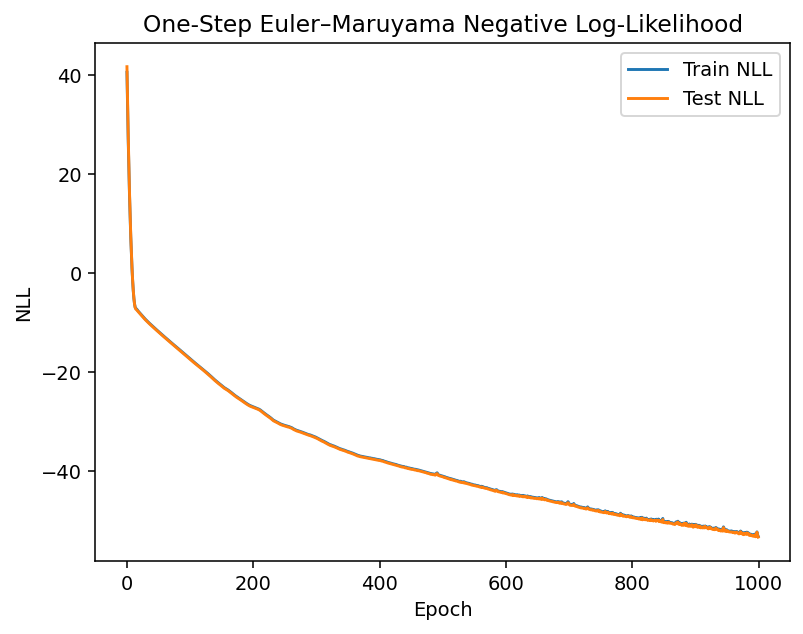

In [103]:
torch.manual_seed(80085) 

train_losses, test_losses, model, X_train = likelihood_training(
    outs,
    Omega_tr=Omegas,
    det_Omega_tr = det_Omega,
    proj_dX_tr=proj_dX,
    Omega_te = Omegas_te,
    det_Omega_te = det_Omega_te,
    proj_dX_te = proj_dX_te,
    n_epochs=1000,
    batch_size=256,
    lr=5e-5,
    data='xi',
    zero_drift=False,
    model = None
)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_losses, label="Train NLL")
plt.plot(test_losses, label="Test NLL")
plt.title("One-Step Euler–Maruyama Negative Log-Likelihood")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

In [ ]:
# Python
tr = set(outs.C_train.index.values)
te = set(outs.C_test.index.values)
print("overlap:", len(tr & te))

overlap: 1


In [110]:
import numpy as np
from scipy import stats

def ensure_vector(x, name):
    x = np.asarray(x)
    if x.dtype == object:
        # catch Ellipsis/None/str sneaking in
        flat = x.ravel().tolist()
        bad = [type(v).__name__ for v in flat if not isinstance(v, (int, float, np.number))]
        raise TypeError(f"{name} contains non-numeric values: {set(bad)}. "
                        f"Replace placeholders '...' with real numbers.")
    x = np.asarray(x, dtype=float).ravel()
    if not np.all(np.isfinite(x)):
        raise ValueError(f"{name} has non-finite values (NaN/Inf).")
    return x

# ---- supply REAL data below ----
# ...existing code...
from neural_sde.loss import build_xi_training_data

X_tr, X_te, _ = build_xi_training_data(outs)  # (T_tr,p), (T_te,p)
j = 0  # pick a factor index
dx_train = np.diff(X_tr[:, j])
dx_test  = np.diff(X_te[:, j])
# ...existing code...

ks_stat, ks_p = stats.ks_2samp(dx_train, dx_test, alternative='two-sided', method='auto')
bf_stat, bf_p = stats.levene(dx_train, dx_test, center='median')

print(f"KS(train vs test): stat={ks_stat:.3f}, p={ks_p:.3g}")
print(f"Brown–Forsythe (var): stat={bf_stat:.3f}, p={bf_p:.3g}")
print(f"Std devs: train={dx_train.std(ddof=1):.4g}, test={dx_test.std(ddof=1):.4g}")



KS(train vs test): stat=0.041, p=0.763
Brown–Forsythe (var): stat=2.594, p=0.107
Std devs: train=0.02631, test=0.02403


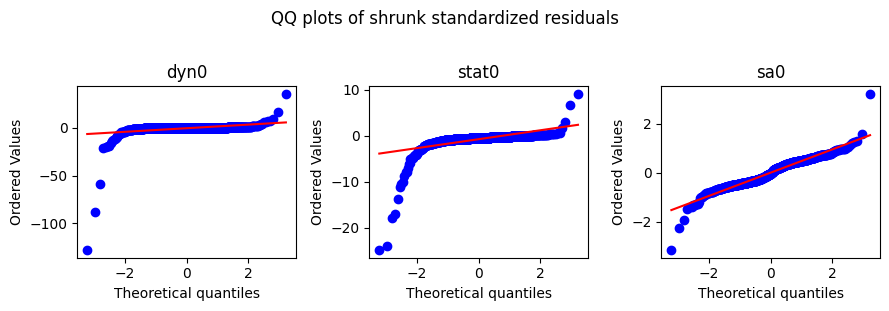

In [16]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats
from neural_sde.loss import build_xi_training_data 
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

@torch.no_grad()
def qq_plots_shrunk(model, outs, X_train_np, Omegas_np, names=None):
    device = next(model.parameters()).device

    # time steps
    tt = pd.to_datetime(outs.C_train.index.values)
    sec_per_year = 1
    dt = (tt[1:] - tt[:-1]).to_numpy(dtype='timedelta64[s]').astype(np.float64) / sec_per_year
    L = min(len(dt), X_train_np.shape[0]-1, Omegas_np.shape[0])

    # tensors
    Y0 = torch.from_numpy(X_train_np[:L]).float().to(device)
    Y1 = torch.from_numpy(X_train_np[1:L+1]).float().to(device)
    dt_t = torch.from_numpy(dt[:L].copy()).float().to(device).unsqueeze(1).clamp_min(1e-12)
   
    # Omega = torch.from_numpy(Omegas_np[:L]).float().to(device) 
    p = Y0.shape[1]
    Omega = torch.from_numpy(Omegas_np[:L]).float().to(device).view(L, p, p)  # (L,p,p)      
    
    Omega_T = Omega.transpose(1,2)

    # drift & diffusion at Y0
    mu  = model.f(0.0, Y0)                                                  # (L,p)
    gout = model.g(0.0, Y0)                                                 # (L,p) or (L,p,p)

    p = Y0.shape[1]
    # Σ_t (choose the branch that matches your model.g)
    if gout.dim() == 2:  # diagonal diffusion
        Sigma = torch.diag_embed(gout.clamp_min(1e-9)**2)                   # (L,p,p)
    else:                # full Cholesky L (lower-triangular)
        Lchol = gout
        Sigma = Lchol @ Lchol.transpose(1,2)

    # effective covariance:  Σ̃ = Ω Σ Ωᵀ
    Sigma_tilde = Omega @ Sigma @ Omega_T

    # projected increment/drift:  Ω^{-T} dX , Ω^{-T} μ
    dX = (Y1 - Y0)                                                           # (L,p)
    proj_dX = torch.linalg.solve(Omega_T, dX)                                # (L,p)
    proj_mu = torch.linalg.solve(Omega_T, mu)                                # (L,p)

    # standardized residuals:  z = L̃^{-1} (proj_dX - proj_mu*dt) / sqrt(dt)
    # where L̃ is Cholesky of Σ̃ (lower-triangular)
    Ltilde = torch.linalg.cholesky(Sigma_tilde + 1e-12*torch.eye(p, device=device))  # (L,p,p)
    numer = (proj_dX - proj_mu * dt_t) / torch.sqrt(dt_t)                    # (L,p)
    z = torch.linalg.solve_triangular(Ltilde, numer.unsqueeze(-1), upper=False).squeeze(-1)  # (L,p)

    z_np = z.cpu().numpy()

    # QQ plots
    d = z_np.shape[1]
    cols = 3
    rows = int(np.ceil(d/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*3.0))
    axes = np.array(axes).ravel()

    for j in range(d):
        stats.probplot(z_np[:, j], dist="norm", plot=axes[j])
        axes[j].set_title(names[j] if names else f"factor {j+1}")

    for k in range(d, len(axes)):
        axes[k].axis("off")

    fig.suptitle("QQ plots of shrunk standardized residuals", y=1.02)
    plt.tight_layout()
    plt.show()

# --- call it ---
X_train, _, names = build_xi_training_data(outs)  # if you need names
qq_plots_shrunk(model, outs, X_train, Omegas, names)



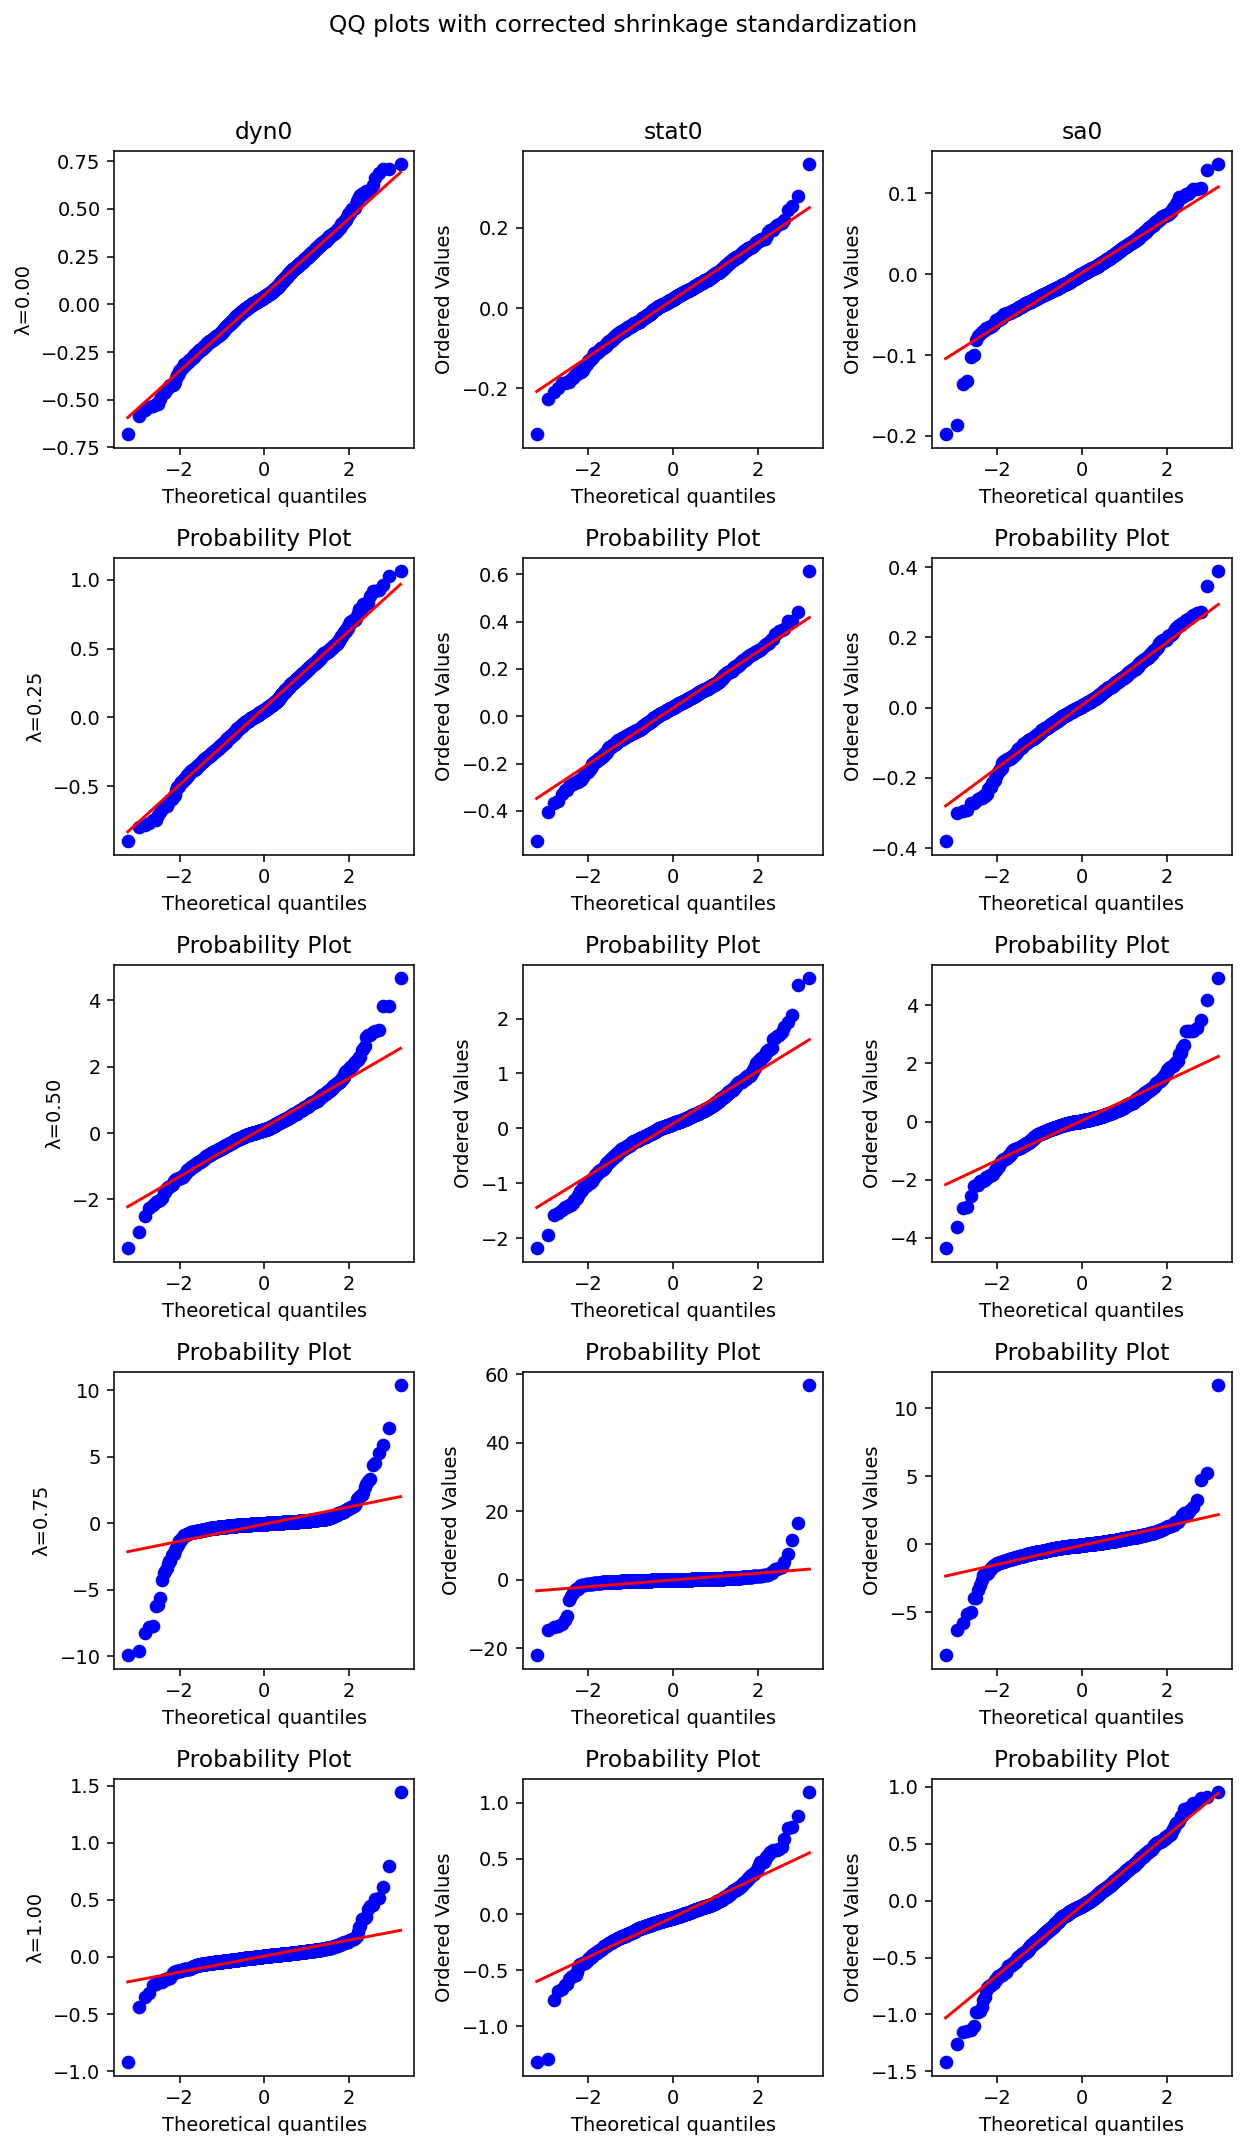

In [111]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy import stats

@torch.no_grad()
def qq_plots_scaled_correct(model, outs, X_train_np, Omegas_np, names=None,
                            lambdas=(0.0, 0.25, 0.5, 0.75, 1.0)):
    """
    QQ plots of standardized residuals under scaled shrinkage.
    
    Corrects the whitening: after projecting with Ω^{-T}, whiten using Σ 
    from the diffusion net g(x), not ΩΣΩᵀ.
    """
    device = next(model.parameters()).device

    # --- time grid ---
    tt = pd.to_datetime(outs.C_train.index.values)
    sec_per_year = 1
    dt = (tt[1:] - tt[:-1]).to_numpy(dtype='timedelta64[s]').astype(np.float64) / sec_per_year
    L = min(len(dt), X_train_np.shape[0]-1, Omegas_np.shape[0])

    # --- tensors ---
    Y0 = torch.from_numpy(X_train_np[:L]).float().to(device)
    Y1 = torch.from_numpy(X_train_np[1:L+1]).float().to(device)
    dt_t = torch.from_numpy(dt[:L].copy()).float().to(device).unsqueeze(1).clamp_min(1e-12)

    p = Y0.shape[1]
    Omegas = torch.from_numpy(Omegas_np[:L]).float().to(device).view(L, p, p)

    # --- model outputs ---
    mu   = model.f(0.0, Y0)          # (L,p)
    gout = model.g(0.0, Y0)          # (L,p) for diagonal, (L,p,p) for full

    dX = Y1 - Y0

    # --- plot grid ---
    fig, axes = plt.subplots(len(lambdas), p, figsize=(p*3, len(lambdas)*3))
    axes = np.atleast_2d(axes)

    for i, lam in enumerate(lambdas):
        # Scale shrinkage Ω
        I = torch.eye(p, device=device).unsqueeze(0).expand_as(Omegas)
        Omega_scaled = (1-lam)*I + lam*Omegas
        Omega_T = Omega_scaled.transpose(1,2)

        # Project increments/drift
        proj_dX = torch.linalg.solve(Omega_T, dX)       # (L,p)
        proj_mu = torch.linalg.solve(Omega_T, mu)       # (L,p)

        # Standardize using Σ from g
        if gout.dim() == 2:  # diagonal diffusion
            z = (proj_dX - proj_mu*dt_t) / (gout.clamp_min(1e-9) * torch.sqrt(dt_t))
        else:                # full diffusion (Cholesky case)
            Sigma = gout @ gout.transpose(1,2)          # (L,p,p)
            Lchol = torch.linalg.cholesky(Sigma + 1e-12*torch.eye(p, device=device))
            numer = (proj_dX - proj_mu*dt_t) / torch.sqrt(dt_t)
            z = torch.cholesky_solve(numer.unsqueeze(-1), Lchol).squeeze(-1)

        z_np = z.cpu().numpy()

        # QQ plot per factor
        for j in range(p):
            stats.probplot(z_np[:, j], dist="norm", plot=axes[i,j])
            if i==0:
                axes[i,j].set_title(names[j] if names else f"f{j}")
            if j==0:
                axes[i,j].set_ylabel(f"λ={lam:.2f}")

    plt.suptitle("QQ plots with corrected shrinkage standardization", y=1.02)
    plt.tight_layout()
    plt.show()

# --- Example usage ---
# X_train, _, names = build_xi_training_data(outs)
# qq_plots_scaled_correct(model, outs, X_train, Omegas, names)

X_train, _, names = build_xi_training_data(outs)
qq_plots_scaled_correct(model, outs, X_train, Omegas, names)


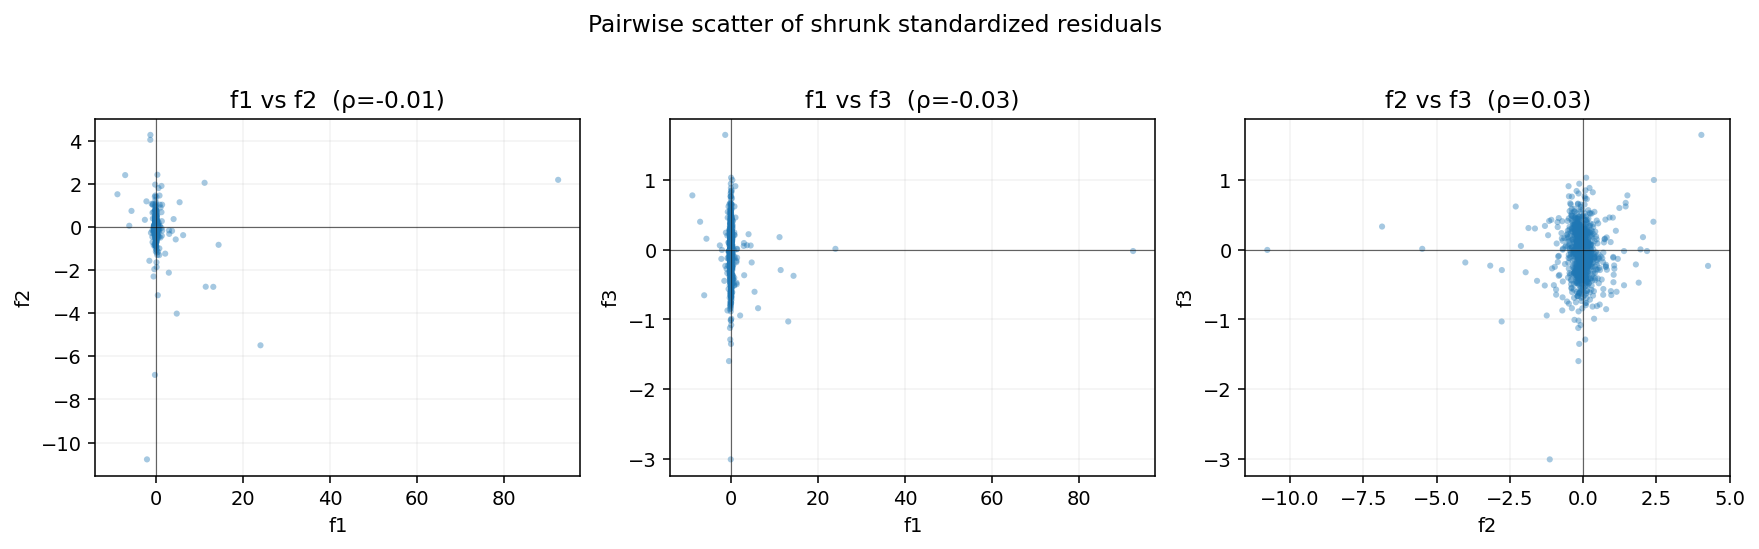

In [112]:
import numpy as np
import pandas as pd
import torch

@torch.no_grad()
def compute_shrunk_residuals(model, outs, X_train_np, Omegas_np):
    """
    Returns z: (T-1, p) shrunk standardized residuals, and names (if available).

    z_t = L̃_t^{-1}[(Ω_t^{-T}(X_{t+1}-X_t) - Ω_t^{-T}μ_t Δt) / sqrt(Δt)], 
    with Σ̃_t = Ω_t Σ_t Ω_t^T and L̃_t = chol(Σ̃_t).
    """
    device = next(model.parameters()).device
    tt = pd.to_datetime(outs.C_train.index.values)
    sec_per_year = 1

    # safe timedelta to float conversion
    dt = np.array([(tt[i+1] - tt[i]).total_seconds() for i in range(len(tt)-1)], dtype=np.float64) / sec_per_year

    Tm1 = min(len(dt), X_train_np.shape[0]-1, Omegas_np.shape[0])
    Y0 = torch.from_numpy(X_train_np[:Tm1]).float().to(device)         # (L,p)
    Y1 = torch.from_numpy(X_train_np[1:Tm1+1]).float().to(device)      # (L,p)
    dt_t = torch.from_numpy(dt[:Tm1].copy()).float().to(device).unsqueeze(1).clamp_min(1e-12)

    p = Y0.shape[1]
    # Ω: make sure it's (L,p,p)
    Omega = torch.from_numpy(Omegas_np[:Tm1]).float().to(device)
    if Omega.dim() == 2 and Omega.shape[1] == p*p:
        Omega = Omega.view(Tm1, p, p)
    assert Omega.shape == (Tm1, p, p)
    Omega_T = Omega.transpose(1, 2)

    # drift, diffusion
    mu  = model.f(0.0, Y0)                           # (L,p)
    gout = model.g(0.0, Y0)                          # (L,p) diag or (L,p,p) chol

    if gout.dim() == 2:                              # diagonal diffusion
        Sigma = torch.diag_embed(gout.clamp_min(1e-9)**2)    # (L,p,p)
    else:                                            # full Cholesky
        Lchol = gout
        Sigma = Lchol @ Lchol.transpose(1, 2)

    # Σ̃ = Ω Σ Ωᵀ
    Sigma_tilde = Omega @ Sigma @ Omega_T

    # projected increments & drift: Ω^{-T}(dX) and Ω^{-T}μ
    dX = Y1 - Y0                                     # (L,p)
    proj_dX = torch.linalg.solve(Omega_T, dX)        # (L,p)
    proj_mu = torch.linalg.solve(Omega_T, mu)        # (L,p)

    # whiten with Cholesky of Σ̃
    I = torch.eye(p, device=device).unsqueeze(0).expand(Tm1, -1, -1)
    Ltilde = torch.linalg.cholesky(Sigma_tilde + 1e-12*I)      # (L,p,p)

    numer = (proj_dX - proj_mu * dt_t) / torch.sqrt(dt_t)      # (L,p)
    z = torch.linalg.solve_triangular(Ltilde, numer.unsqueeze(-1), upper=False).squeeze(-1)

    names = getattr(outs, "Xi_names", None) if hasattr(outs, "Xi_names") else None
    return z.cpu().numpy(), names

import matplotlib.pyplot as plt
from itertools import combinations
import math

def pairwise_scatter_shrunk(z_np, names=None, max_cols=3, s=10, alpha=0.4):
    """
    z_np: (T-1, p) shrunk standardized residuals from compute_shrunk_residuals(...)
    """
    R = np.asarray(z_np, float)
    d = R.shape[1]
    labels = names if (isinstance(names, (list, tuple)) and len(names)==d) else [f"f{j+1}" for j in range(d)]

    pairs = list(combinations(range(d), 2))
    cols = min(max_cols, len(pairs)) or 1
    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.2, rows*3.8), squeeze=False)

    for ax, (i, j) in zip(axes.ravel(), pairs):
        x, y = R[:, i], R[:, j]
        # guard for NaNs/Infs
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() == 0:
            ax.set_visible(False); continue
        rho = np.corrcoef(x[m], y[m])[0, 1]
        ax.scatter(x[m], y[m], s=s, alpha=alpha, edgecolors="none")
        ax.axhline(0, color="k", lw=0.6, alpha=0.6)
        ax.axvline(0, color="k", lw=0.6, alpha=0.6)
        ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])
        ax.set_title(f"{labels[i]} vs {labels[j]}  (ρ={rho:.2f})")
        ax.grid(alpha=0.15)

    # hide any unused axes
    for k in range(len(pairs), rows*cols):
        fig.delaxes(axes.ravel()[k])

    fig.suptitle("Pairwise scatter of shrunk standardized residuals", y=1.02)
    plt.tight_layout()
    plt.show()



# If you already have X_train and Omegas (flattened or square), do:
z_shrunk, names = compute_shrunk_residuals(model, outs, X_train, Omegas)
pairwise_scatter_shrunk(z_shrunk, names)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

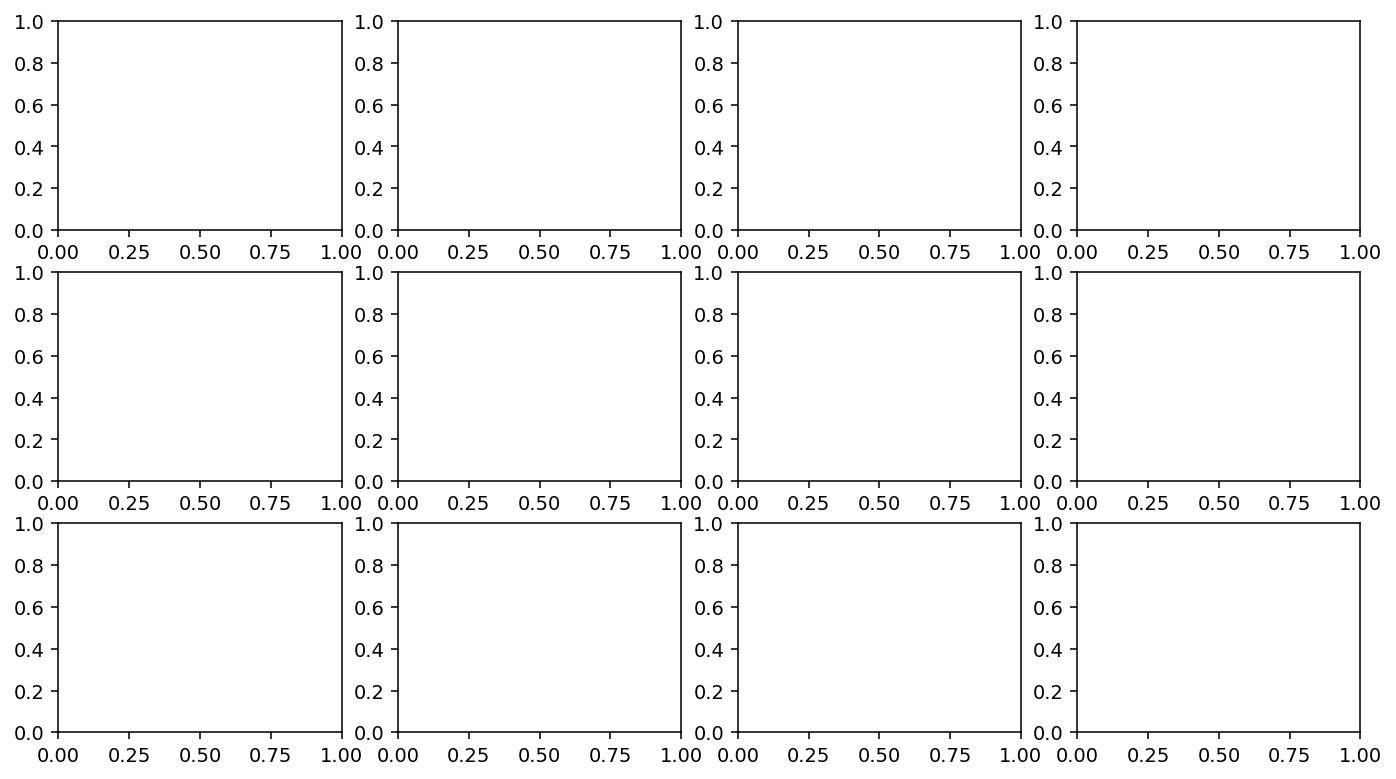

In [113]:
# Requires:
# - outs from decoding (Algo1Outputs, e.g. from decoding_aggre.ipynb)
# - model from neural_sde training (e.g. likelihood_training)
# Optional:
# - mu, sd returned by likelihood_training if standardisation was used

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from neural_sde.loss import build_xi_training_data  # -> [`neural_sde.loss.build_xi_training_data`](neural_sde/loss.py)

device = next(model.parameters()).device

# 1) Factor dimension and helper to split [dyn|stat|sa] blocks (order matches build_xi_training_data)
k_dyn  = outs.G_dyn.shape[0] if getattr(outs, "G_dyn", None) is not None and outs.G_dyn.size else 0
k_stat = outs.G_stat.shape[0] if getattr(outs, "G_stat", None) is not None and outs.G_stat.size else 0
k_sa   = outs.G_sa.shape[0]   if getattr(outs, "G_sa",   None) is not None and outs.G_sa.size   else 0
p = k_dyn + k_stat + k_sa
N = outs.G0.shape[0]  # number of nodes

def split_blocks(x):
    """x: (..., p) -> (xd, xs, xa)"""
    i = 0
    xd = x[..., i:i+k_dyn];  i += k_dyn
    xs = x[..., i:i+k_stat]; i += k_stat
    xa = x[..., i:i+k_sa] if k_sa>0 else x[..., :0]
    return xd, xs, xa

# 2) Build train factors (for x0) and dt (years)
X_tr, _, names = build_xi_training_data(outs)
x0_raw = X_tr[-1].astype(np.float64)  # last observed state as start

sec_per_year = 1
tt_tr = pd.to_datetime(outs.C_train.index.values)
dt_tr = np.asarray((tt_tr[1:] - tt_tr[:-1]).total_seconds(), dtype=np.float64) / sec_per_year
dt = float(np.median(dt_tr)) if len(dt_tr) else (1.0/365/24/60)  # ~1 minute fallback

# 3) Prepare standardisation if available (depends on your likelihood_training return)
def to_model_space(x):
    if 'mu' in globals() and 'sd' in globals() and (mu is not None) and (sd is not None):
        mu_np = mu.detach().cpu().numpy() if torch.is_tensor(mu) else np.asarray(mu)
        sd_np = sd.detach().cpu().numpy() if torch.is_tensor(sd) else np.asarray(sd)
        return (x - mu_np.ravel()) / (sd_np.ravel() + 1e-9)
    return x

def from_model_space(x):
    if 'mu' in globals() and 'sd' in globals() and (mu is not None) and (sd is not None):
        mu_np = mu.detach().cpu().numpy() if torch.is_tensor(mu) else np.asarray(mu)
        sd_np = sd.detach().cpu().numpy() if torch.is_tensor(sd) else np.asarray(sd)
        return x * sd_np.ravel() + mu_np.ravel()
    return x

# 4) Euler–Maruyama simulation for factors under [`neural_sde.nets.NeuralSDE`](neural_sde/nets.py)
@torch.no_grad()
def simulate_factors(model, x0_raw, n_steps=60, n_paths=256, dt_years=dt, clamp_sig=1e-9):
    x0 = to_model_space(x0_raw.astype(np.float64))
    x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).float().to(device)  # (B, p)
    out = [x.clone()]
    DT = torch.tensor(dt_years, dtype=torch.float32, device=device).view(1,1)
    for _ in range(n_steps):
        mu  = model.f(0.0, x)
        sig = model.g(0.0, x).clamp_min(clamp_sig)        # diagonal diffusion per-dim
        eps = torch.randn_like(x)
        x   = x + mu*DT + sig*torch.sqrt(DT)*eps
        out.append(x.clone())
    X_std = torch.stack(out, dim=1)  # (B, T+1, p)
    X_raw = from_model_space(X_std.cpu().numpy())
    return X_raw  # numpy (n_paths, n_steps+1, p)

# 5) Map factors -> normalized option prices at each lattice node
#    C = G0 + Xi_dyn·G_dyn + Xi_stat·G_stat + Xi_sa·G_sa  (see [`factors.decode.reconstruct_prices`](factors/decode.py))
def factors_to_prices(X):
    """
    X: (B, T+1, p) in raw Xi space
    Returns: C: (B, T+1, N) normalized prices per node
    """
    B, T1, _ = X.shape
    C = np.empty((B, T1, N), dtype=np.float64)
    G0 = outs.G0.astype(np.float64)
    Gd = outs.G_dyn.astype(np.float64) if k_dyn>0 else np.zeros((0, N))
    Gs = outs.G_stat.astype(np.float64) if k_stat>0 else np.zeros((0, N))
    Ga = outs.G_sa.astype(np.float64)   if k_sa>0   else np.zeros((0, N))
    for t in range(T1):
        xt = X[:, t, :]                    # (B, p)
        xd, xs, xa = split_blocks(xt)      # (B,k_*)
        C[:, t, :] = (G0[None, :]
                      + (xd @ Gd) if k_dyn>0 else 0.0
                      + (xs @ Gs) if k_stat>0 else 0.0
                      + (xa @ Ga) if k_sa>0   else 0.0)
    # Optional no‑arb clipping to [max(1-exp(m),0), 1]
    m = outs.nodes_sub[:, 1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)
    C = np.clip(C, lb[None, None, :], 1.0)
    return C

# 6) Run simulation and get price distribution at horizon
n_paths = 256
n_steps = 60   # horizon steps (~60 minutes if dt is 1 minute)
X_sim = simulate_factors(model, x0_raw, n_steps=n_steps, n_paths=n_paths, dt_years=dt)
C_sim = factors_to_prices(X_sim)   # (B, T+1, N)

# Choose horizon snapshot (final time)
C_T = C_sim[:, -1, :]              # (B, N)

from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

def tidy_x_axis(ax, data):
    # turn off offset/scientific notation
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.get_xaxis().get_offset_text().set_visible(False)
    # choose a readable fixed-decimal formatter based on range
    rng = float(np.ptp(data))
    if rng < 0.02:
        fmt = FormatStrFormatter('%.4f')
    elif rng < 0.2:
        fmt = FormatStrFormatter('%.3f')
    else:
        fmt = FormatStrFormatter('%.2f')
    ax.xaxis.set_major_formatter(fmt)

# 7) Visualise: histograms for first 12 nodes and a violin summary
n_show = min(12, C_T.shape[1])
fig, axes = plt.subplots(int(np.ceil(n_show/4)), 4, figsize=(12, 2.2*np.ceil(n_show/4)), squeeze=False)
axes = axes.ravel()
for j in range(n_show):
    ax = axes[j]
    ax.hist(C_T[:, j], bins=40, alpha=0.8, color="#3a78b4")
    τ, m = outs.nodes_sub[j, 0], outs.nodes_sub[j, 1]
    tidy_x_axis(ax, C_T[:, j])
    ax.set_title(f"node {j}\nτ={τ:.2f}, m={m:.2f}", fontsize=9)
    ax.grid(alpha=0.2)
for k in range(n_show, len(axes)):
    fig.delaxes(axes[k])
fig.suptitle("Simulated normalized call price distributions at horizon", y=0.98)
plt.tight_layout(); plt.show()

# Violin summary: also remove offset on y (prices)
plt.figure(figsize=(10,3))
q_lo, q_md, q_hi = np.quantile(C_T, [0.1, 0.5, 0.9], axis=0)
plt.fill_between(np.arange(N), q_lo, q_hi, color="#c7dcef", alpha=0.9, label="10–90%")
plt.plot(q_md, color="#2c5d8a", lw=1.5, label="median")
ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.get_yaxis().get_offset_text().set_visible(False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.title("Across-node distribution summary (horizon)"); plt.xlabel("node index"); plt.ylabel("C/F")
plt.legend(); plt.tight_layout(); plt.show()


             portfolio  alpha  VaR  CVaR  mean_PnL  std_PnL  notional_abs_sum
0         Long ATM ~1d   0.95  NaN   NaN       NaN      NaN               1.0
1  Short OTM +0.10 ~1d   0.95  NaN   NaN       NaN      NaN               1.0
2   1x2x1 Call Fly ~1d   0.95  NaN   NaN       NaN      NaN               4.0
3         Long ATM ~1d   0.99  NaN   NaN       NaN      NaN               1.0
4  Short OTM +0.10 ~1d   0.99  NaN   NaN       NaN      NaN               1.0
5   1x2x1 Call Fly ~1d   0.99  NaN   NaN       NaN      NaN               4.0


/var/folders/7p/px6mp0t52794gwq4s0r9jst0ytvmtk/T/ipykernel_1049/74003580.py:22: RuntimeWarning: Mean of empty slice.
  cvar  = -dV[dV <= qtile].mean()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7096: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7097: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

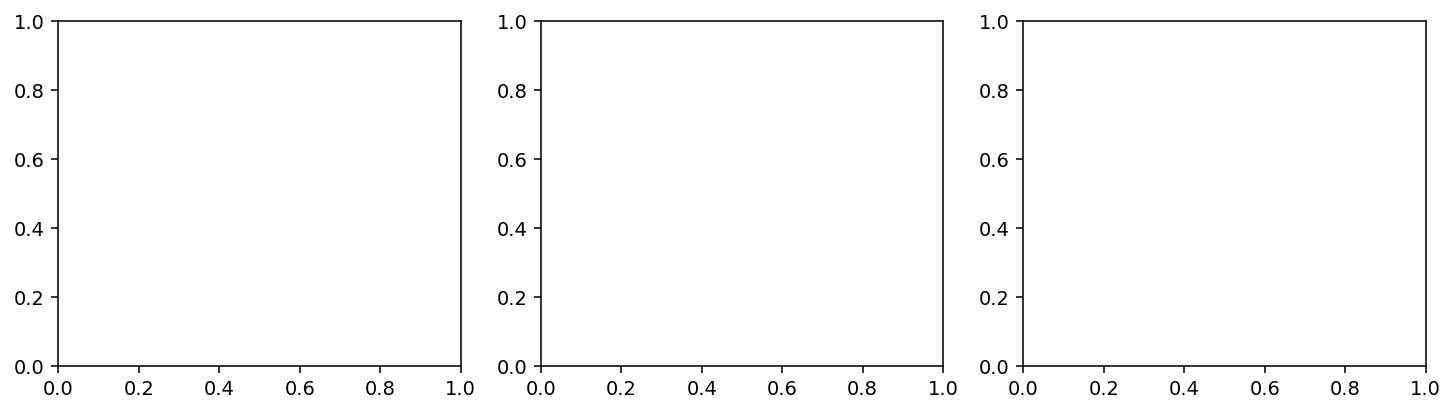

In [109]:
def portfolio_var_from_C(C_sim, q, F0=1.0, multipliers=None, alpha=0.99):
    """
    C_sim: (B, T+1, N) normalized prices C/F
    q:     (N,) portfolio holdings per node
    F0:    scalar forward at t0 to convert to dollars (use 1.0 to stay normalized)
    multipliers: (N,) contract multipliers (default 1.0)
    """
    C_sim = np.asarray(C_sim)
    q = np.asarray(q).reshape(-1)
    B, T1, N = C_sim.shape
    assert q.shape[0] == N, "q must match number of nodes"

    w = np.ones(N) if multipliers is None else np.asarray(multipliers).reshape(-1)
    notional = q * F0 * w  # (N,)

    V0 = C_sim[:, 0, :] @ notional      # (B,)
    VT = C_sim[:, -1, :] @ notional     # (B,)
    dV = VT - V0                        # (B,)

    qtile = np.quantile(dV, 1 - alpha)
    var   = -qtile
    cvar  = -dV[dV <= qtile].mean()
    return var, cvar, dV


# ------------------------------------------------------------
# Helpers: map specs -> q vectors
# ------------------------------------------------------------
def nearest_node_index(tau, m, nodes):
    """
    nodes: array of shape (N,2) with columns [tau, m]
    returns index j of the nearest node by Euclidean distance in (tau, m).
    """
    diffs = nodes - np.array([tau, m])[None, :]
    j = np.argmin(np.sum(diffs*diffs, axis=1))
    return int(j)

def make_q_from_spec(spec, nodes):
    """
    Build q vector (N,) from a portfolio spec.
    spec can be:
      - dict {int_node_index: qty, ...}
      - list of (tau, m, qty) tuples (mapped to nearest node)
    """
    N = nodes.shape[0]
    q = np.zeros(N, dtype=float)
    if isinstance(spec, dict):
        for j, qty in spec.items():
            q[int(j)] += float(qty)
        return q

    # assume iterable of (tau, m, qty)
    for tau, m, qty in spec:
        j = nearest_node_index(float(tau), float(m), nodes)
        q[j] += float(qty)
    return q

# ------------------------------------------------------------
# Bulk evaluation
# ------------------------------------------------------------
def evaluate_var_for_portfolios(C_sim, portfolios, nodes, F0=1.0, multipliers=None, alphas=(0.99,)):
    """
    portfolios: dict name -> spec (dict of {node_index: qty} OR list of (tau, m, qty))
    returns: (summary_df, details) where:
      - summary_df: tidy table with VaR/CVaR per portfolio & alpha
      - details: dict name -> dict { 'q': q, 'PnL': dV }
    """
    results = []
    details = {}
    for name, spec in portfolios.items():
        q = make_q_from_spec(spec, nodes)
        # compute once, then grab for all alphas
        _, _, dV = portfolio_var_from_C(C_sim, q, F0=F0, multipliers=multipliers, alpha=alphas[0])
        details[name] = {'q': q, 'PnL': dV}

        for a in alphas:
            var_a, cvar_a, _ = portfolio_var_from_C(C_sim, q, F0=F0, multipliers=multipliers, alpha=a)
            results.append({
                'portfolio': name,
                'alpha': a,
                'VaR': var_a,
                'CVaR': cvar_a,
                'mean_PnL': float(np.mean(dV)),
                'std_PnL': float(np.std(dV, ddof=1)),
                'notional_abs_sum': float(np.sum(np.abs(q)))  # in normalized units unless F0/multipliers used
            })

    summary = pd.DataFrame(results).sort_values(['alpha','VaR'], ascending=[True, False]).reset_index(drop=True)
    return summary, details

# ------------------------------------------------------------
# Example portfolio set
# nodes_2d should be your (tau, m) for each lattice node.
# Prefer outs.nodes_sub if present, else outs.nodes.
# ------------------------------------------------------------
nodes_2d = getattr(outs, 'nodes_sub', getattr(outs, 'nodes_sub'))
assert nodes_2d.shape[1] == 2, "nodes must have shape (N,2) with [tau, m]"

# Build a few example portfolios (edit to your needs):
tau_near_1d = 1.0/365.0
tau_near_3d = 3.0/365.0
m_atm       = 0.0
m_otm_up    = +0.10
m_otm_dn    = -0.10

portfolios = {
    # 1) Long single near-ATM call (by (tau,m))
    "Long ATM ~1d": [
        (tau_near_1d, m_atm, +1.0)
    ],

    # 2) Short OTM ~1d
    "Short OTM +0.10 ~1d": [
        (tau_near_1d, m_otm_up, -1.0)
    ],

    # 3) Call butterfly around ATM at ~1d: +1 at m=-0.10, -2 at m=0, +1 at m=+0.10
    "1x2x1 Call Fly ~1d": [
        (tau_near_1d, m_otm_dn, +1.0),
        (tau_near_1d, m_atm,    -2.0),
        (tau_near_1d, m_otm_up, +1.0)
    ],
}


# ------------------------------------------------------------
# Run VaR evaluation
# ------------------------------------------------------------
# Choose your conversion to dollars if you want absolute VaR:
# - F0: current forward/spot at t0 (e.g., BTCUSD price)
# - multipliers: contract sizes per node (vector length N) if needed
F0 = 1.0
multipliers = None
alphas = (0.95, 0.99)

summary_df, details = evaluate_var_for_portfolios(
    C_sim=C_sim,
    portfolios=portfolios,
    nodes=nodes_2d,
    F0=F0,
    multipliers=multipliers,
    alphas=alphas
)

print(summary_df)

# ------------------------------------------------------------
# (Optional) quick P&L histogram per portfolio
# ------------------------------------------------------------
import matplotlib.pyplot as plt
cols = len(portfolios)
fig, axes = plt.subplots(1, cols, figsize=(4.2*cols, 3.2), squeeze=False)
for ax, (name, info) in zip(axes.ravel(), details.items()):
    dV = info['PnL']
    ax.hist(dV, bins=40, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("PnL")
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


In [37]:
import numpy as np
import pandas as pd

# --- 0) Inputs you already have ---------------------------------------------
# outs: Algo1 outputs (has C_train, C_test, nodes_sub, G0,G_dyn,G_stat,G_sa, etc.)
# model: trained neural SDE (already used above)
# factors_to_prices(X): provided earlier, maps factors -> normalized C/F (shape (B,T,N))
# evaluate_var_for_portfolios(...): provided earlier
# portfolios: dict -> specs (as in your earlier example)
# C_sim: your neural-SDE simulated normalized prices (B, T+1, N)

# --- 1) Build historical factor time series Xi and 1-step shocks dXi --------
# We want joint shocks in *factor space* so revaluation is cheap & consistent.
from neural_sde.loss import build_xi_training_data  # already imported earlier

# Xi_train: (T_tr, p), Xi_test: (T_te, p) in the *raw* Xi space used by factors_to_prices
Xi_train, Xi_test, _ = build_xi_training_data(outs)

# Choose a "today" anchor state x0_raw. For apples-to-apples with your MC,
# use the same x0 you used for simulation. E.g., most recent observed test state:
x0_raw = Xi_test[-1].astype(np.float64) if Xi_test.shape[0] else Xi_train[-1].astype(np.float64)

# Historical 1-step shocks from a window (use test if you want recent only; else train)
Xi_hist = np.vstack([Xi_train, Xi_test])  # choose your windowing if needed
dXi = Xi_hist[1:] - Xi_hist[:-1]          # shape (M, p) joint shocks

# Optionally drop giant gaps/outliers or missing periods here.

# --- 2) Build one-step HS scenarios in factor space -------------------------
# Each scenario b: x_b = x0 + dXi[b]
X_HS = x0_raw[None, :] + dXi              # (M, p)

# Map to normalized prices at t0 and t1 under each scenario (like a 1-step horizon)
# We'll create a (B, T+1, p) so factors_to_prices can be reused: T=1
B = X_HS.shape[0]
X_seq = np.stack([np.tile(x0_raw, (B,1)), X_HS], axis=1)  # (B, 2, p)
C_sim_HS = factors_to_prices(X_seq)                       # (B, 2, N) normalized C/F

# --- 3) Weighted HS (optional) ----------------------------------------------
def geometric_weights(n, lam=0.98):
    # most recent return gets the largest weight
    # weight_t ∝ λ^{n-1-t}, t=0 oldest ... n-1 newest; normalize to sum 1
    exps = lam ** np.arange(n)[::-1]
    w = (1-lam) * exps / (1 - lam**n)
    return w

# Example: WHS weights for the last B scenarios
whs_weights = geometric_weights(B, lam=0.98)

# --- 4) VaR/CVaR from HS in forward units or dollars ------------------------
# Reuse your portfolio VaR evaluator; for *forward-unit* VaR keep F0=1.0.
alphas = (0.95, 0.99)

summary_HS, details_HS = evaluate_var_for_portfolios(
    C_sim=C_sim_HS,            # (B, 2, N)
    portfolios=portfolios,
    nodes=getattr(outs, 'nodes_sub', outs.nodes_sub),
    F0=1.0,                    # keep in normalized units unless you also pass a forward path
    multipliers=None,
    alphas=alphas
)

# Weighted HS (same scenarios, but weighted quantiles & ETL)
def weighted_var_cvar_from_C(C_sim, q, weights, alpha=0.99, F0=1.0, multipliers=None):
    # 1-step PnL in normalized units with weights
    C_sim = np.asarray(C_sim)           # (B, 2, N)
    q = np.asarray(q).reshape(-1)
    w = np.ones(C_sim.shape[-1]) if multipliers is None else np.asarray(multipliers)
    notional = q * w                    # (N,)

    V = (C_sim @ notional)              # (B, 2)
    dV = (V[:, 1] - V[:, 0]) * F0       # (B,)
    # sort by PnL, accumulate weights
    idx = np.argsort(dV)
    dV_s = dV[idx]
    w_s  = np.asarray(weights)[idx]
    w_cum = np.cumsum(w_s)
    # VaR: smallest x with cum prob >= 1-alpha
    cutoff = 1.0 - alpha
    j = np.searchsorted(w_cum, cutoff, side='left')
    var = -dV_s[min(j, len(dV_s)-1)]
    # CVaR: weighted average below VaR threshold
    mask = w_cum <= cutoff
    w_tail = w_s[mask]
    dV_tail = dV_s[mask]
    cvar = -(w_tail @ dV_tail) / max(w_tail.sum(), 1e-12)
    return var, cvar

# Build a tidy WHS table
rows = []
for name, spec in portfolios.items():
    q = make_q_from_spec(spec, getattr(outs, 'nodes_sub', outs.nodes_sub))
    for a in alphas:
        v, cv = weighted_var_cvar_from_C(C_sim_HS, q, whs_weights, alpha=a, F0=1.0)
        rows.append({'portfolio': name, 'alpha': a, 'VaR_WHS': v, 'CVaR_WHS': cv})
summary_WHS = pd.DataFrame(rows).sort_values(['alpha','VaR_WHS'], ascending=[True, False])

# --- 5) Compare against your neural-SDE Monte-Carlo --------------------------
# You already have C_sim from your SDE (Bmc, T+1, N). We’ll compute the same summary for MC.
summary_MC, details_MC = evaluate_var_for_portfolios(
    C_sim=C_sim,
    portfolios=portfolios,
    nodes=getattr(outs, 'nodes_sub', outs.nodes_sub),
    F0=1.0,
    multipliers=None,
    alphas=alphas
)

# Merge tables for side-by-side (forward-unit VaR)
cmp = (summary_MC.rename(columns={'VaR':'VaR_MC','CVaR':'CVaR_MC'})
                   .merge(summary_HS.rename(columns={'VaR':'VaR_HS','CVaR':'CVaR_HS'}),
                          on=['portfolio','alpha'], how='inner')
                   .merge(summary_WHS, on=['portfolio','alpha'], how='left'))

print(cmp[['portfolio','alpha','VaR_MC','CVaR_MC','VaR_HS','CVaR_HS','VaR_WHS','CVaR_WHS']].to_string(index=False))

          portfolio  alpha   VaR_MC  CVaR_MC   VaR_HS  CVaR_HS  VaR_WHS  CVaR_WHS
 1x2x1 Call Fly ~1d   0.95 0.000014 0.000017 0.002181 0.002905 0.001896  0.003309
       Long ATM ~1d   0.95 0.000001 0.000002 0.000240 0.000316 0.000177  0.000265
Short OTM +0.10 ~1d   0.95 0.000001 0.000001 0.000162 0.000215 0.000140  0.000245
 1x2x1 Call Fly ~1d   0.99 0.000018 0.000020 0.003350 0.003849 0.003688  0.004051
       Long ATM ~1d   0.99 0.000002 0.000003 0.000380 0.000433 0.000347  0.000421
Short OTM +0.10 ~1d   0.99 0.000001 0.000001 0.000248 0.000285 0.000273  0.000300


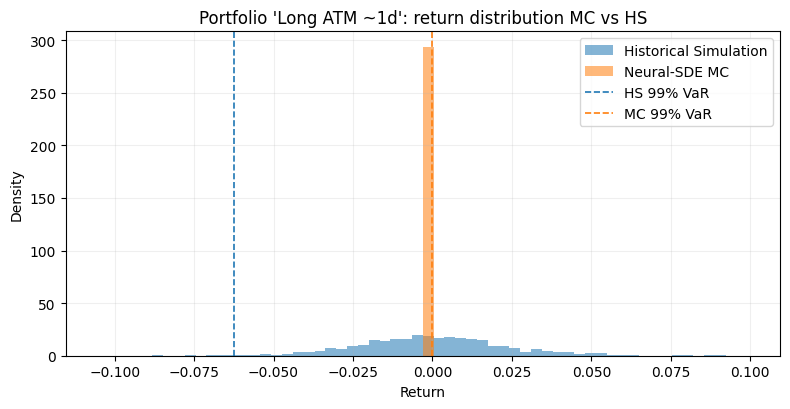

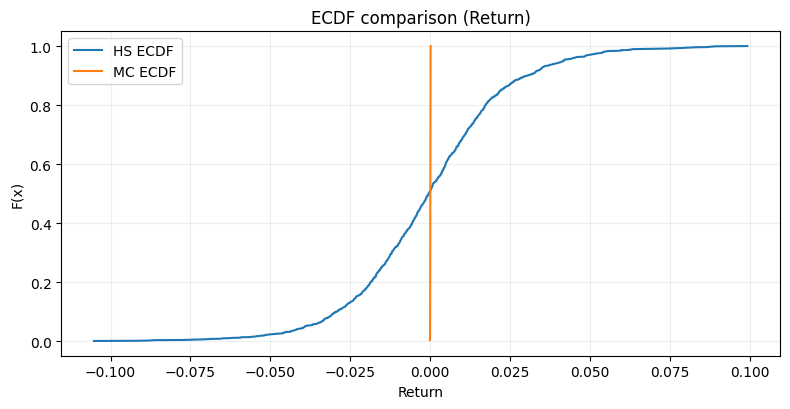

In [74]:
import numpy as np
import matplotlib.pyplot as plt


def factors_to_prices(X):
    B,T1,_ = X.shape
    G0 = outs.G0.astype(np.float64)
    Gd = outs.G_dyn.astype(np.float64) if k_dyn>0 else np.zeros((0, N))
    Gs = outs.G_stat.astype(np.float64) if k_stat>0 else np.zeros((0, N))
    Ga = outs.G_sa.astype(np.float64)   if k_sa>0   else np.zeros((0, N))
    C = np.empty((B,T1,N), np.float64)
    for t in range(T1):
        xd,xs,xa = split_blocks(X[:,t,:])
        term = np.broadcast_to(G0, (B,N)).copy()
        if k_dyn:  term += xd @ Gd
        if k_stat: term += xs @ Gs
        if k_sa:   term += xa @ Ga
        C[:,t,:] = term
    # optional display clip
    m = outs.nodes_sub[:,1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)
    return np.clip(C, lb[None,None,:], 1.0)

# ------------------------------------------------------------------
# Helpers: portfolio PnL & "return" (scaled PnL) from normalized C/F
# ------------------------------------------------------------------
def portfolio_pnl_from_c(C_sim, q, F_path=None, multipliers=None):
    """
    C_sim: (B, T+1, N) normalized prices C/F
    q:     (N,) portfolio holdings
    F_path: None, scalar, (T+1,), or (B, T+1) forward(s) to convert to $.
    multipliers: (N,) contract multipliers
    Returns: dV (B,) P&L over horizon
    """
    C_sim = np.asarray(C_sim)
    B, T1, N = C_sim.shape
    q = np.asarray(q).reshape(-1)
    assert q.shape[0] == N

    w = np.ones(N) if multipliers is None else np.asarray(multipliers).reshape(-1)
    notional = q * w                                   # (N,)

    V = C_sim @ notional                               # (B, T+1) in forward units
    if F_path is None:
        F_path = 1.0
    V = V * F_path                                     # broadcast scalar or array
    return V[:, -1] - V[:, 0]                          # (B,)

def portfolio_return_from_c(C_sim, q, F_path=None, multipliers=None, denom="V0_abs"):
    """
    denom:
      - "V0":     divide by initial portfolio value (can be 0!)
      - "V0_abs": divide by |initial value| (safer)
      - "notional_abs": divide by sum(|q * multipliers|) * F0 (scale-only)
    """
    C_sim = np.asarray(C_sim)
    B, T1, N = C_sim.shape
    q = np.asarray(q).reshape(-1)

    w = np.ones(N) if multipliers is None else np.asarray(multipliers).reshape(-1)
    notional = q * w  # (N,)

    V = C_sim @ notional
    if F_path is None:
        F_path = 1.0
    V = V * F_path                # (B, T+1)

    V0 = V[:, 0]
    dV = V[:, -1] - V[:, 0]

    if denom == "V0":
        den = V0
    elif denom == "notional_abs":
        # If F_path is scalar, use its value at t0; else take mean(F0) as scale
        if np.ndim(F_path) == 0:
            F0 = float(F_path)
        else:
            F0 = float(np.mean(F_path[:, 0]) if F_path.ndim == 2 else F_path[0])
        den = np.sum(np.abs(notional)) * max(F0, 1e-12)
    else:  # "V0_abs"
        den = np.abs(V0)
    den = np.where(np.abs(den) < 1e-12, 1.0, den)  # avoid blow-ups
    return dV / den

# ------------------------------------------------------------------
# Build distributions (MC & HS), then overlay
# ------------------------------------------------------------------
def overlay_returns_histograms(C_sim_MC, C_sim_HS, q, *,
                               F_path_MC=None, F_path_HS=None, multipliers=None,
                               use="return", denom="V0_abs",
                               bins=60, xlim=None, title="Portfolio return distribution: MC vs HS"):
    """
    use: "pnl" or "return"
    denom: passed to portfolio_return_from_c (only used if use=='return')
    """
    if use == "pnl":
        x_MC = portfolio_pnl_from_c(C_sim_MC, q, F_path=F_path_MC, multipliers=multipliers)
        x_HS = portfolio_pnl_from_c(C_sim_HS, q, F_path=F_path_HS, multipliers=multipliers)
        xlab = "P&L"
    else:
        x_MC = portfolio_return_from_c(C_sim_MC, q, F_path=F_path_MC, multipliers=multipliers, denom=denom)
        x_HS = portfolio_return_from_c(C_sim_HS, q, F_path=F_path_HS, multipliers=multipliers, denom=denom)
        xlab = "Return"

    # Common bins for fair visual comparison
    lo = np.min([np.min(x_MC), np.min(x_HS)])
    hi = np.max([np.max(x_MC), np.max(x_HS)])
    edges = np.linspace(lo, hi, bins+1)

    plt.figure(figsize=(8,4.2))
    plt.hist(x_HS, bins=edges, density=True, alpha=0.55, label="Historical Simulation", linewidth=0.5)
    plt.hist(x_MC, bins=edges, density=True, alpha=0.55, label="Neural-SDE MC", linewidth=0.5)
    plt.axvline(np.quantile(x_HS, 0.01), color="C0", linestyle="--", linewidth=1.2, label="HS 99% VaR")
    plt.axvline(np.quantile(x_MC, 0.01), color="C1", linestyle="--", linewidth=1.2, label="MC 99% VaR")
    plt.title(title)
    plt.xlabel(xlab); plt.ylabel("Density"); 
    if xlim is not None: plt.xlim(xlim)
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

    # Optional: ECDF overlay (tail comparison)
    def ecdf(x):
        xs = np.sort(x); ys = np.arange(1, len(x)+1)/len(x); return xs, ys
    xs_HS, F_HS = ecdf(x_HS); xs_MC, F_MC = ecdf(x_MC)
    plt.figure(figsize=(8,4.2))
    plt.plot(xs_HS, F_HS, label="HS ECDF")
    plt.plot(xs_MC, F_MC, label="MC ECDF")
    plt.title(f"ECDF comparison ({xlab})")
    plt.xlabel(xlab); plt.ylabel("F(x)")
    if xlim is not None: plt.xlim(xlim)
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
# Assume you already have:
#   C_sim      : (Bmc, T+1, N) from neural-SDE (MC) over the same horizon as HS (T should be 1 for like-for-like)
#   C_sim_HS   : (Bhs, 2,   N) one-step HS scenarios (built earlier)
#   portfolios : dict name -> spec (as before)
#   nodes_2d   : (N,2) lattice nodes (tau, m)

# Choose one portfolio to overlay (or loop over all)
name = next(iter(portfolios))
q_vec = make_q_from_spec(portfolios[name], nodes_2d)

# If you want forward-unit comparison, keep F_path_* = None (i.e., 1.0)
overlay_returns_histograms(C_sim_MC=C_sim,
                           C_sim_HS=C_sim_HS,
                           q=q_vec,
                           F_path_MC=None, F_path_HS=None,           # or pass a scalar/array for $ VaR
                           multipliers=None,
                           use="return", denom="V0_abs",
                           bins=60,
                           title=f"Portfolio '{name}': return distribution MC vs HS")

In [72]:
last(iter(portfolios))

NameError: name 'last' is not defined

In [53]:
import numpy as np, torch, pandas as pd


@torch.no_grad()
def check_mu_sigma_scales(model, X_seq_raw, dt_years, to_model, *, clamp_sig=1e-9, k=2000):
    """
    X_seq_raw: (T,p) factor series in RAW Xi space (train+test concatenated is fine)
    dt_years : scalar dt used in training/MC (same units!)
    """
    T, p = X_seq_raw.shape
    idx = np.linspace(0, T-2, num=min(k, T-1), dtype=int)
    x = torch.from_numpy(to_model(X_seq_raw[idx])).float().to(next(model.parameters()).device)
    mu  = model.f(0.0, x).cpu().numpy()                         # (k,p)
    sig = model.g(0.0, x).clamp_min(clamp_sig).cpu().numpy()    # (k,p)

    # step scales
    step_drift = np.linalg.norm(mu*dt_years, axis=1)
    step_diff  = np.linalg.norm(sig*np.sqrt(dt_years), axis=1)

    out = {
        "mu_norm_median": float(np.median(np.linalg.norm(mu, axis=1))),
        "sig_norm_median": float(np.median(np.linalg.norm(sig, axis=1))),
        "drift_step_median": float(np.median(step_drift)),
        "diff_step_median": float(np.median(step_diff)),
        "pct_sig_below_1e-6": float(np.mean(sig < 1e-6))*100.0,
        "pct_sig_equal_clamp": float(np.mean(sig <= clamp_sig))*100.0,
    }
    return out, mu, sig

# Example usage
# Build Xi series (raw space)
from neural_sde.loss import build_xi_training_data
Xi_tr, Xi_te, _ = build_xi_training_data(outs)
Xi_all = np.vstack([Xi_tr, Xi_te])

# USE THE SAME to_model_space AS IN YOUR SIM
def to_model_space(x):  # replace with your actual scaler mapping
    if 'mu' in globals() and 'sd' in globals() and mu is not None and sd is not None:
        mu_np = np.asarray(mu).ravel(); sd_np = np.asarray(sd).ravel()
        return (x - mu_np) / (sd_np + 1e-9)
    return x

dt_years = 60 # <- the same scalar you used in MC
scales, mu_samp, sig_samp = check_mu_sigma_scales(model, Xi_all, dt_years, to_model_space)
print(scales)

# Empirical factor shocks (raw space)
dXi_emp = Xi_all[1:] - Xi_all[:-1]                       # (T-1,p)

# Model-implied one-step shocks from the same states (no shrink/BC)
@torch.no_grad()
def simulate_one_step_increments(model, X_raw, dt_years, to_model, *, clamp_sig=1e-9):
    x = torch.from_numpy(to_model(X_raw)).float().to(next(model.parameters()).device)
    mu  = model.f(0.0, x)
    sig = model.g(0.0, x).clamp_min(clamp_sig)
    eps = torch.randn_like(mu)
    dX  = (mu*dt_years + sig*np.sqrt(dt_years)*eps).cpu().numpy()
    return dX

# Use the same time stamps as dXi_emp
X0_raw = Xi_all[:-1]
dXi_sim = simulate_one_step_increments(model, X0_raw, dt_years, to_model_space)

# Compare per-dimension variance ratios and correlations
var_emp = np.var(dXi_emp, axis=0, ddof=1)
var_sim = np.var(dXi_sim, axis=0, ddof=1)
ratio   = np.divide(var_sim, var_emp, out=np.full_like(var_emp, np.nan), where=var_emp>0)

print("median var_sim/var_emp:", np.nanmedian(ratio))
print("5%-95% var ratio:", np.nanpercentile(ratio[~np.isnan(ratio)], [5,95]))
print("mean |corr_emp,sim|:", np.mean([np.corrcoef(dXi_emp[:,j], dXi_sim[:,j])[0,1] for j in range(dXi_emp.shape[1])]))

# Prepare a single state x0 near your VaR start date
x0_raw = Xi_te[-1] if len(Xi_te) else Xi_tr[-1]

# A) RAW (no BC, no shrink)
dX_raw = simulate_one_step_increments(model, x0_raw[None,:], dt_years, to_model_space, clamp_sig=1e-9)
print("||dX_raw|| median over 1k eps:", np.median([np.linalg.norm(
    simulate_one_step_increments(model, x0_raw[None,:], dt_years, to_model_space)[0]
) for _ in range(1000)]))

# B) With your BC only
# plug x0_raw into your BC function once, compute corrected mu, then simulate with that μ and unshrunk σ
# (if this collapses variability, BC is producing gigantic corrective drift stepping you to a flat zone)

# C) With shrink only
# compute your εσ -> s multipliers; report min/max/median(s) and recompute one-step variance

# Round-trip check: raw -> model -> raw
def from_model_space(x):
    if 'mu' in globals() and 'sd' in globals() and mu is not None and sd is not None:
        mu_np = np.asarray(mu).ravel(); sd_np = np.asarray(sd).ravel()
        return x*sd_np + mu_np
    return x

rtest = Xi_all[:100]
rt = from_model_space(to_model_space(rtest))
print("round-trip max abs err:", float(np.max(np.abs(rt - rtest))))

# perturb x0 by tiny Gaussian and watch price std at ATM node
eps = np.random.normal(size=(4096, x0_raw.size)) * 1e-4
X_tiny = np.stack([x0_raw[None,:].repeat(4096,0), x0_raw[None,:].repeat(4096,0)+eps], axis=1)
C_tiny = factors_to_prices(X_tiny)      # (4096,2,N)
atm_idx = make_q_from_spec([(1.0/365, 0.0, 1.0)], outs.nodes_sub).argmax()
print("price std at ATM for 1e-4 factor nudge:", float(np.std(C_tiny[:,1,atm_idx]-C_tiny[:,0,atm_idx])))

from numpy import dot
C0 = factors_to_prices(np.stack([x0_raw, x0_raw])[None,...])[:,0,:].squeeze()
# print("V0 Long ATM ~1d:", float(dot(q_long_atm, C0)))
print("Std P&L RAW:", float(np.std(dV_raw, ddof=1)))
print("Std RETURN RAW (V0_abs):", float(np.std(dV_raw/np.abs(dot(q_long_atm,C0)+1e-12), ddof=1)))



{'mu_norm_median': 0.00011142653238493949, 'sig_norm_median': 0.026183346286416054, 'drift_step_median': 0.006685591768473387, 'diff_step_median': 0.20281532910569994, 'pct_sig_below_1e-6': 0.0, 'pct_sig_equal_clamp': 0.0}
median var_sim/var_emp: 210.3382866982276
5%-95% var ratio: [  39.8187635  1100.33153714]
mean |corr_emp,sim|: 0.011808174971814458
||dX_raw|| median over 1k eps: 0.17512044
round-trip max abs err: 0.0
price std at ATM for 1e-4 factor nudge: 1.845256759502433e-05


NameError: name 'dV_raw' is not defined

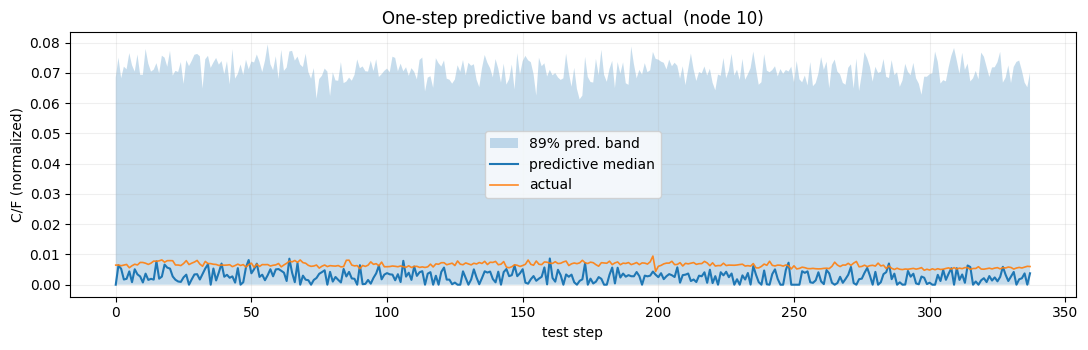

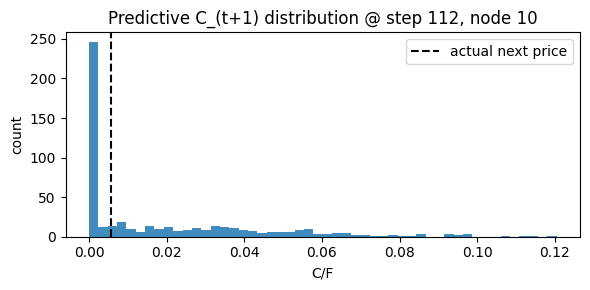

PIT mean (should be ~0.5 if calibrated): 0.5379934818786982


In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

device = next(model.parameters()).device

# ---------------------------
# 1) Factors & dt (TEST SET)
# ---------------------------
# Build test factors in the SAME order as training
_, X_te, names = build_xi_training_data(outs)  # shape (T_test, p)
X_te = X_te.astype(np.float64)
T_test, p = X_te.shape

# Test dt in years from test index
sec_per_year = 1
tt_te = pd.to_datetime(outs.C_test.index.values)
dt_te = np.asarray((tt_te[1:] - tt_te[:-1]).astype('timedelta64[s]'), dtype=np.int64) / sec_per_year
assert len(dt_te) == T_test 

# ---------------------------
# 2) Standardisation hooks
# ---------------------------
def to_model_space(x):
    # if 'mu' in globals() and 'sd' in globals() and (mu is not None) and (sd is not None):
    #     mu_np = mu.detach().cpu().numpy() if torch.is_tensor(mu) else np.asarray(mu)
    #     sd_np = sd.detach().cpu().numpy() if torch.is_tensor(sd) else np.asarray(sd)
    #     return (x - mu_np.ravel()) / (sd_np.ravel() + 1e-9)
    return x

def from_model_space(x):
    # if 'mu' in globals() and 'sd' in globals() and (mu is not None) and (sd is not None):
    #     mu_np = mu.detach().cpu().numpy() if torch.is_tensor(mu) else np.asarray(mu)
    #     sd_np = sd.detach().cpu().numpy() if torch.is_tensor(sd) else np.asarray(sd)
    #     return x * sd_np.ravel() + mu_np.ravel()
    return x

# ---------------------------
# 3) Factors → prices (batch)
# ---------------------------
k_dyn  = outs.G_dyn.shape[0] if getattr(outs, "G_dyn", None) is not None and outs.G_dyn.size else 0
k_stat = outs.G_stat.shape[0] if getattr(outs, "G_stat", None) is not None and outs.G_stat.size else 0
k_sa   = outs.G_sa.shape[0]   if getattr(outs, "G_sa",   None) is not None and outs.G_sa.size   else 0
N = outs.G0.shape[0]

G0 = outs.G0.astype(np.float64)
Gd = outs.G_dyn.astype(np.float64) if k_dyn  > 0 else np.zeros((0, N))
Gs = outs.G_stat.astype(np.float64) if k_stat > 0 else np.zeros((0, N))
Ga = outs.G_sa.astype(np.float64)   if k_sa   > 0 else np.zeros((0, N))

def split_blocks(x):
    i = 0
    xd = x[..., i:i+k_dyn];  i += k_dyn
    xs = x[..., i:i+k_stat]; i += k_stat
    xa = x[..., i:i+k_sa] if k_sa>0 else x[..., :0]
    return xd, xs, xa

def x_to_prices_batch(X_batch):
    """
    X_batch: (B, p) raw Xi → returns (B, N) normalized prices
    """
    xd, xs, xa = split_blocks(X_batch)
    term = np.broadcast_to(G0, (X_batch.shape[0], N)).copy()
    if k_dyn  > 0: term += xd @ Gd
    if k_stat > 0: term += xs @ Gs
    if k_sa   > 0: term += xa @ Ga
    # No-arb clipping
    m = outs.nodes_sub[:, 1].astype(np.float64) if hasattr(outs, 'nodes_sub') else outs.nodes[:,1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)
    return np.clip(term, lb[None, :], 1.0)

# ---------------------------
# 4) One-step predictive draw
# ---------------------------
@torch.no_grad()
def one_step_draw_C(model, x0_raw, dt_years, n_paths=512, clamp_sig=1e-9):
    """
    x0_raw: (p,) raw Xi at time t
    dt_years: scalar
    returns: C_{t+1} draws as (n_paths, N)
    """
    x0 = to_model_space(x0_raw.astype(np.float64))
    x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).float().to(device)  # (B, p)
    DT = torch.tensor(dt_years, dtype=torch.float32, device=device).view(1,1)

    mu  = model.f(0.0, x)
    sig = model.g(0.0, x).clamp_min(clamp_sig)   # diagonal diffusion per dim
    eps = torch.randn_like(x)
    x1  = x + mu*DT + sig*torch.sqrt(DT)*eps     # Euler one-step

    X1_raw = from_model_space(x1.detach().cpu().numpy())
    C1     = x_to_prices_batch(X1_raw)           # (n_paths, N)
    return C1

# ---------------------------
# 5) Roll through test set:
#    node overlay and histogram
# ---------------------------
node_idx   = 10              # <- choose the lattice node to evaluate/plot
alpha_band = (0.05, 0.95)   # predictive band

C_actual = outs.C_test.values.astype(np.float64)  # (T_test, N) normalized
assert C_actual.shape[0] == T_test + 1

n_paths = 512
q_lo_series, q_md_series, q_hi_series = [], [], []
actual_series = []
time_index = tt_te[1:]  # we predict t+1

# collect also PIT values if you want calibration later
pit_vals = []

for t in range(T_test - 1):
    C1_draws = one_step_draw_C(model, X_te[t], dt_te[t], n_paths=n_paths)  # (B, N)
    # predictive stats for chosen node
    draws_node = C1_draws[:, node_idx]
    q_lo, q_md, q_hi = np.quantile(draws_node, [alpha_band[0], 0.5, alpha_band[1]])
    q_lo_series.append(q_lo); q_md_series.append(q_md); q_hi_series.append(q_hi)
    actual = C_actual[t+1, node_idx]
    actual_series.append(actual)
    # PIT
    pit_vals.append((draws_node <= actual).mean())

q_lo_series = np.array(q_lo_series)
q_md_series = np.array(q_md_series)
q_hi_series = np.array(q_hi_series)
actual_series = np.array(actual_series)
pit_vals = np.array(pit_vals)

# ---------------------------
# 6) Plot: predictive band vs actual
# ---------------------------
steps = np.arange(q_lo_series.size)             # align x with computed series
# optional: keep a matching time index if you want to label dates later
time_index_plot = tt_te[1:][:q_lo_series.size]  # from [`pipeline.Algo1Outputs.C_test`](pipeline/algo1.py)

plt.figure(figsize=(11,3.6))
plt.fill_between(steps, q_lo_series, q_hi_series, alpha=0.25,
                 label=f'{int(100*(alpha_band[1]-alpha_band[0]))}% pred. band')
plt.plot(steps, q_md_series, lw=1.5, label='predictive median')
plt.plot(steps, actual_series, lw=1.2, label='actual', alpha=0.9)
plt.title(f"One-step predictive band vs actual  (node {node_idx})")
plt.xlabel("test step"); plt.ylabel("C/F (normalized)")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

# ---------------------------
# 7) One example step histogram with actual overlay
# ---------------------------
t_example = steps.size // 3                     # pick a valid step
C1_draws = one_step_draw_C(model, X_te[t_example], dt_te[t_example], n_paths=n_paths)
draws_node = C1_draws[:, node_idx]
plt.figure(figsize=(6,3))
plt.hist(draws_node, bins=50, alpha=0.85)
plt.axvline(C_actual[t_example+1, node_idx], color='k', ls='--', lw=1.5, label='actual next price')
plt.title(f"Predictive C_(t+1) distribution @ step {t_example}, node {node_idx}")
plt.xlabel("C/F"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

# (Optional) PIT quick check
print("PIT mean (should be ~0.5 if calibrated):", pit_vals.mean())


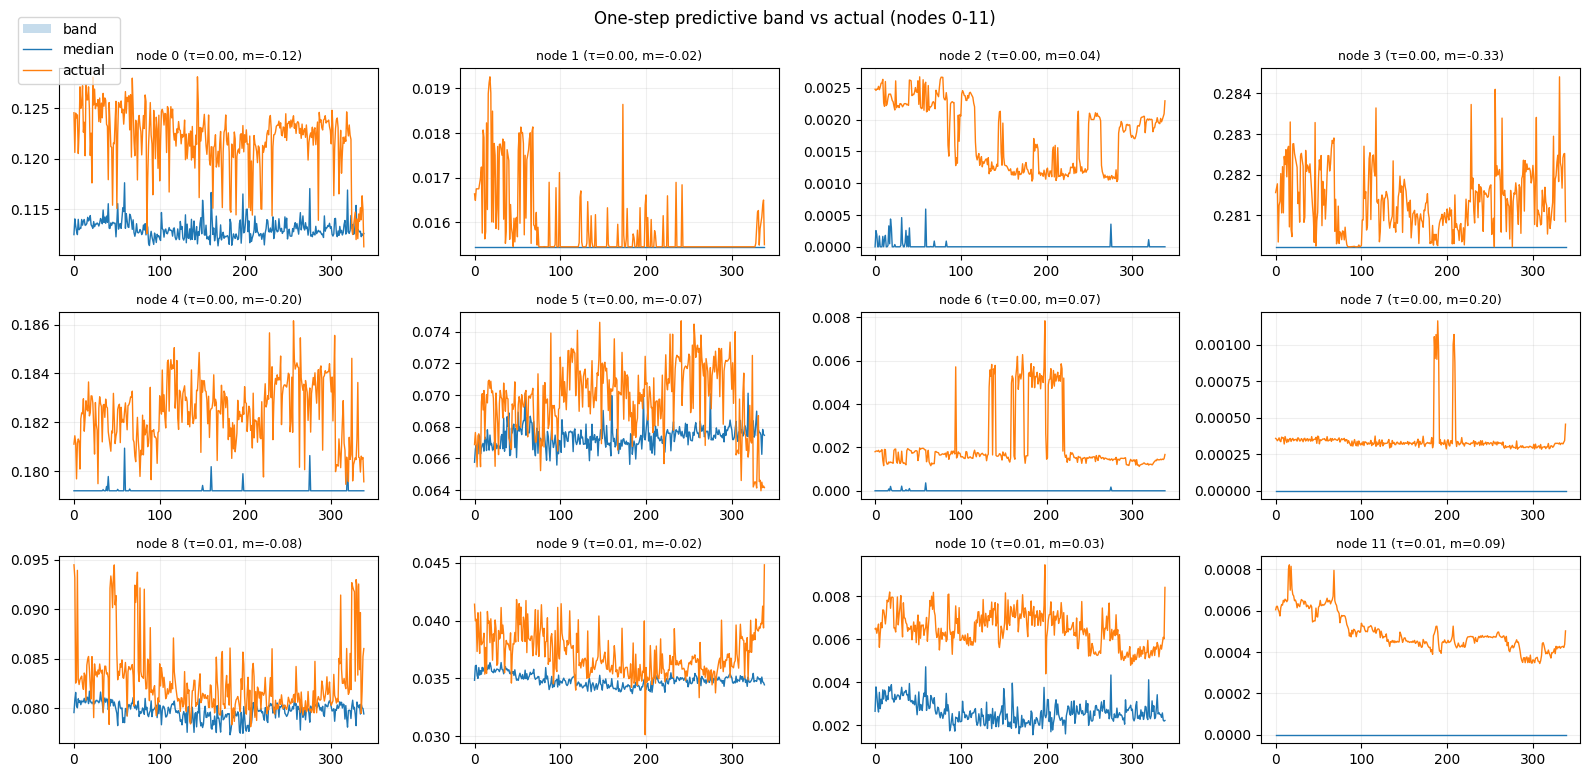

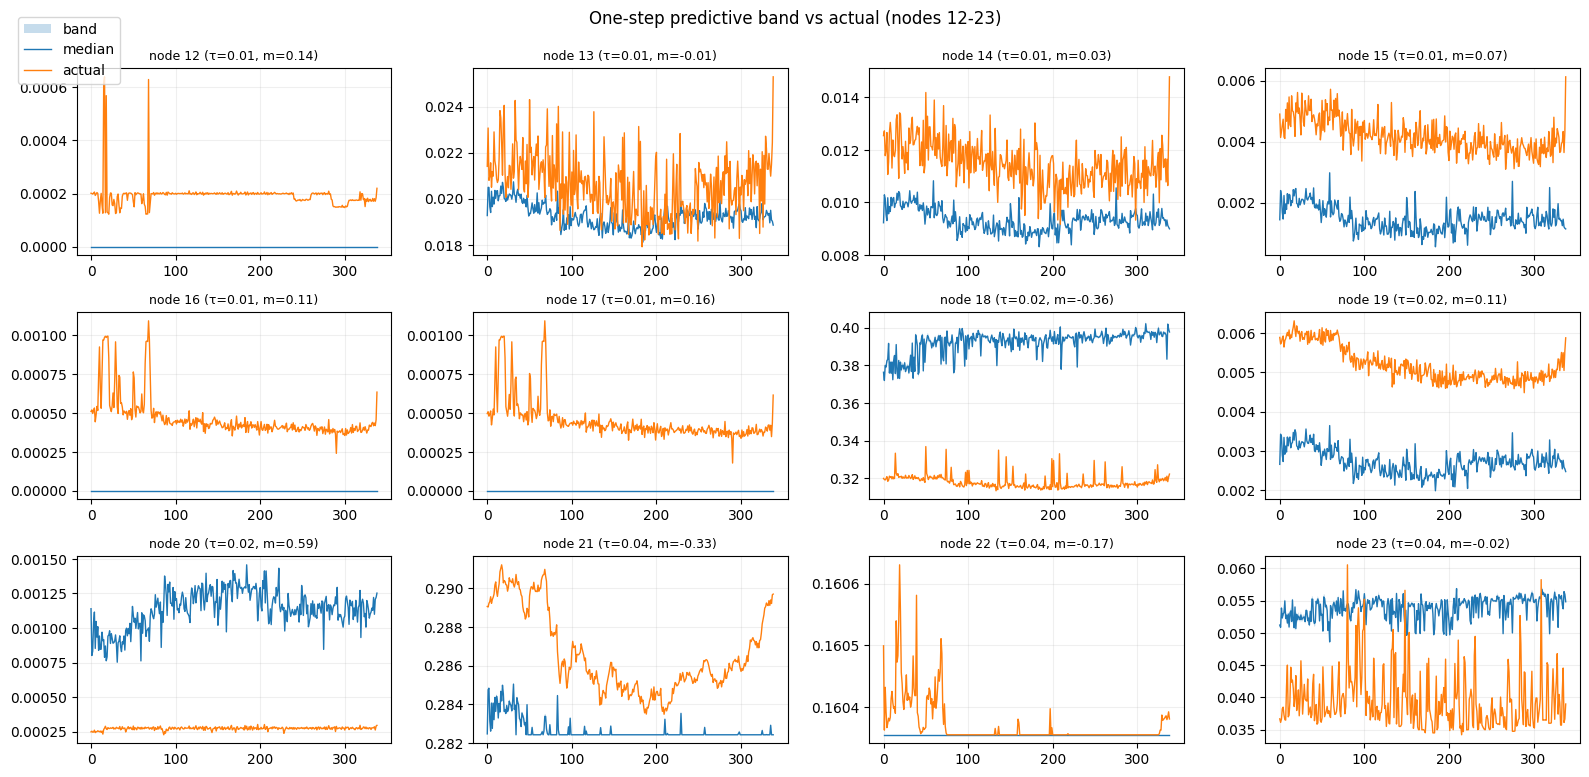

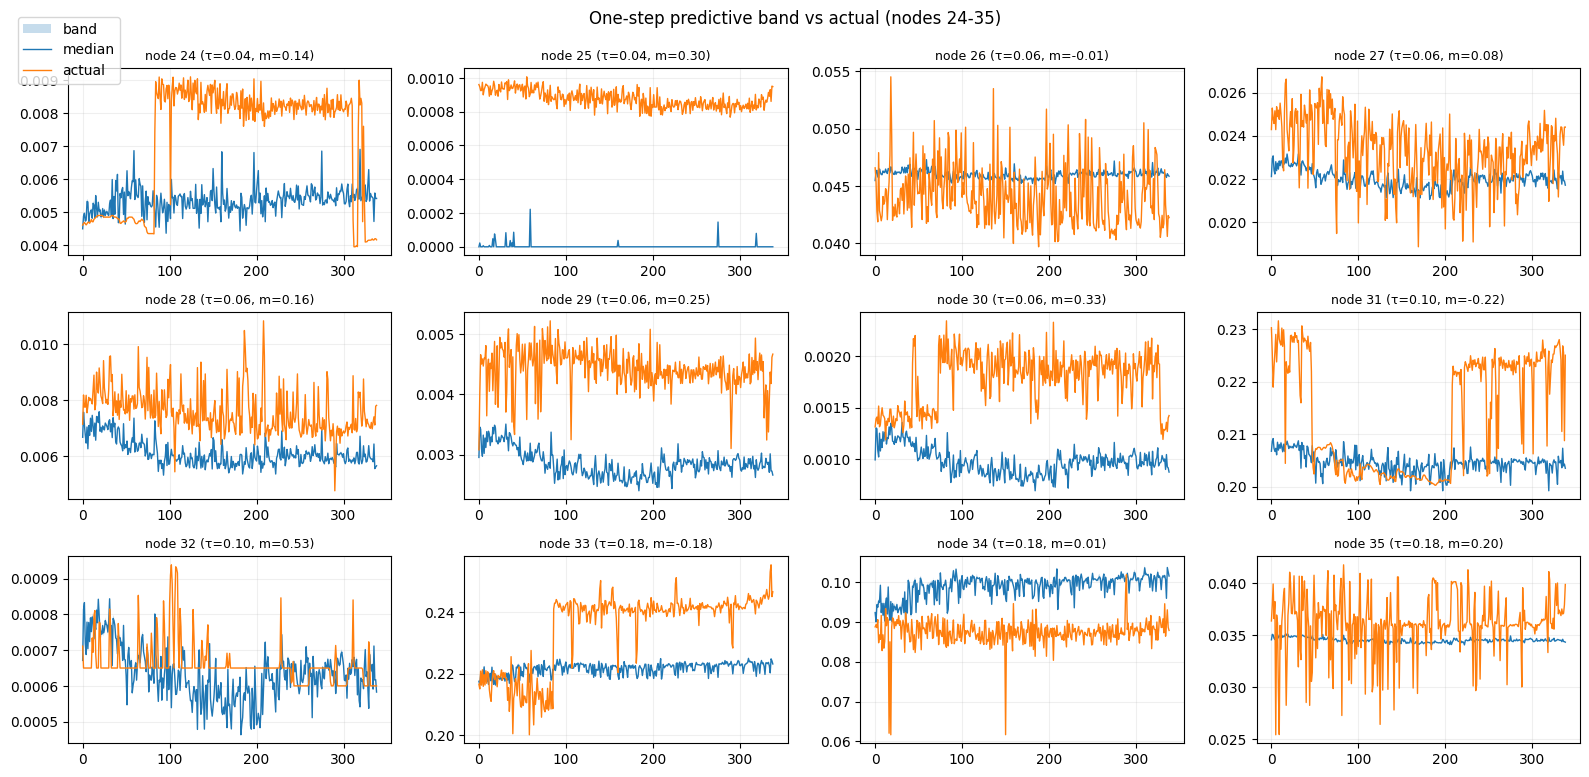

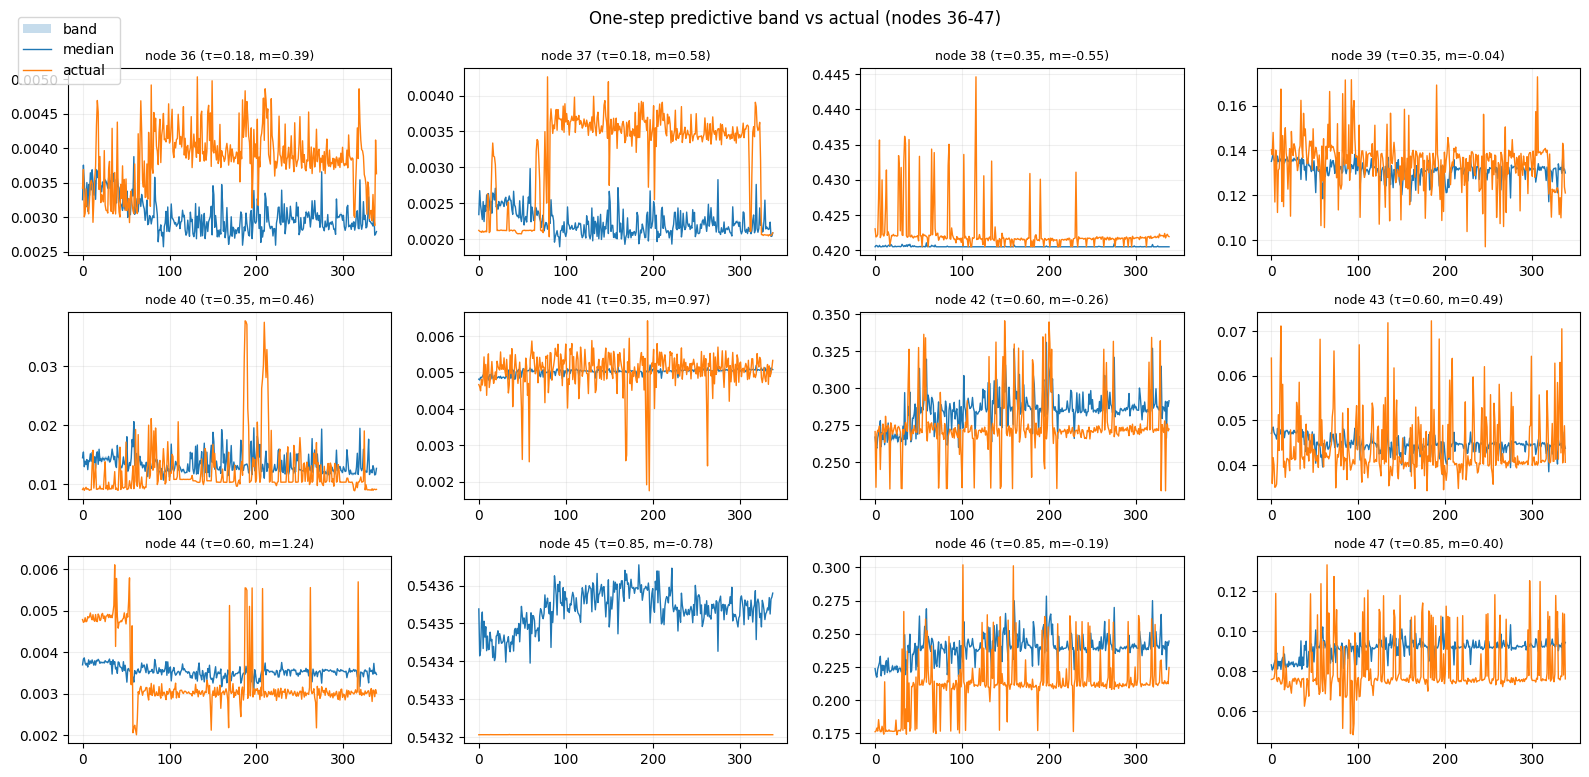

Mean coverage across nodes: 0.00497787610619469
Mean PIT mean across nodes: 0.7037884047366644


In [10]:
# ---------- align once ----------
sec_per_year = 1  
C_test = outs.C_test.values.astype(np.float64)           # (T_c, N)
idx_c  = pd.to_datetime(outs.C_test.index.values)
dt_years = np.asarray((idx_c[1:] - idx_c[:-1]).astype('timedelta64[s]'),
                      dtype=np.int64) / sec_per_year     # (T_c-1,)

_, X_te, _ = build_xi_training_data(outs)                # (T_x, p)
X_te = X_te.astype(np.float64)

steps = min(len(dt_years), X_te.shape[0], C_test.shape[0]-1)
N = outs.G0.shape[0]

# ---------- compute bands for ALL nodes ----------
def one_step_bands_all_nodes(model, X_te, dt_years, C_next, n_paths=1024, band=(0.06,0.94)):
    T = min(len(dt_years), X_te.shape[0], C_next.shape[0])
    q_lo = np.empty((T, N)); q_md = np.empty((T, N)); q_hi = np.empty((T, N))
    pits = np.empty((T, N))
    for t in range(T):
        C1_draws = one_step_draw_C(model, X_te[t], dt_years[t], n_paths=n_paths)  # (B, N)
        qs = np.quantile(C1_draws, [band[0], 0.5, band[1]], axis=0)               # (3, N)
        q_lo[t], q_md[t], q_hi[t] = qs[0], qs[1], qs[2]
        pits[t] = (C1_draws <= C_next[t]).mean(axis=0)
    return q_lo, q_md, q_hi, pits

q_lo, q_md, q_hi, pits = one_step_bands_all_nodes(
    model,
    X_te[:steps],
    dt_years[:steps],
    C_test[1:steps+1],          # actual at t+1
    n_paths=1024,
    band=(0.4, 0.6)         # ~89% like your plot
)

# ---------- small-multiple plots over nodes ----------
nodes_2d = getattr(outs, 'nodes_sub', getattr(outs, 'nodes_sub'))  # (N,2) [tau, m]

def plot_bands_grid(q_lo, q_md, q_hi, actual, nodes_2d, cols=4, rows=3):
    T, N = q_lo.shape
    idx = np.arange(T)
    per_fig = cols*rows
    for start in range(0, N, per_fig):
        end = min(start+per_fig, N)
        m = end - start
        r = math.ceil(m/cols)
        fig, axes = plt.subplots(r, cols, figsize=(cols*4.0, r*2.6), squeeze=False)
        axes = axes.ravel()
        for k, j in enumerate(range(start, end)):
            ax = axes[k]
            ax.fill_between(idx, q_lo[:, j], q_hi[:, j], alpha=0.25, label='band' if k==0 else None)
            ax.plot(idx, q_md[:, j], lw=1.0, label='median' if k==0 else None)
            ax.plot(idx, actual[:, j], lw=1.0, label='actual' if k==0 else None)
            tau, moneyness = nodes_2d[j, 0], nodes_2d[j, 1]
            ax.set_title(f"node {j} (τ={tau:.2f}, m={moneyness:.2f})", fontsize=9)
            ax.grid(alpha=0.2)
        # remove empty axes
        for k in range(m, len(axes)):
            fig.delaxes(axes[k])
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.01, 0.99))
        fig.suptitle(f"One-step predictive band vs actual (nodes {start}-{end-1})", y=0.99)
        plt.tight_layout(); plt.show()
import math
plot_bands_grid(q_lo, q_md, q_hi, C_test[1:steps+1], nodes_2d, cols=4, rows=3)

# ---------- optional: per-node calibration summary ----------
coverage = ((C_test[1:steps+1] >= q_lo) & (C_test[1:steps+1] <= q_hi)).mean(axis=0)   # (N,)
pit_mean = pits.mean(axis=0)                                                          # (N,)
print("Mean coverage across nodes:", float(coverage.mean()))
print("Mean PIT mean across nodes:", float(pit_mean.mean()))

Computed one-step draws with shrink + drift BC.


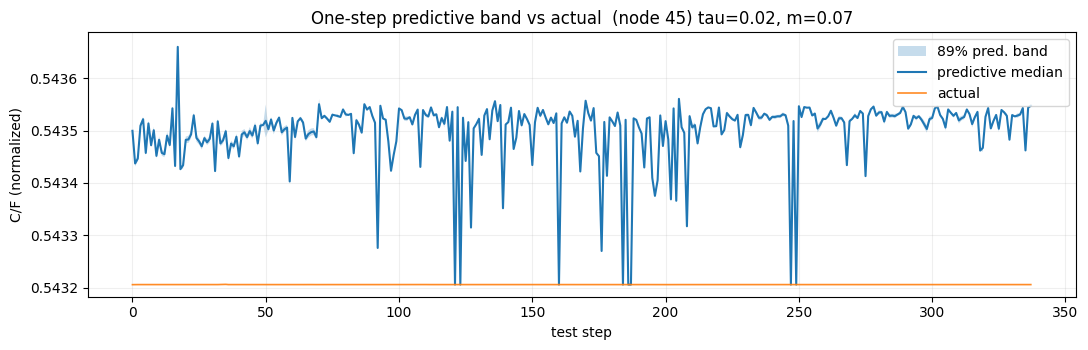

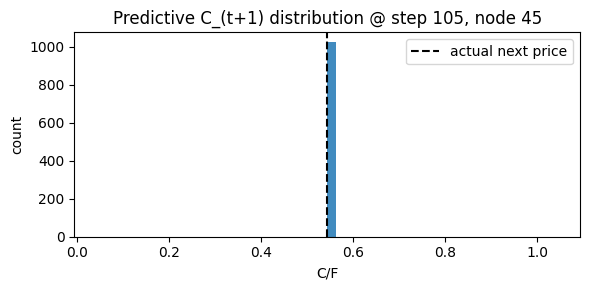

PIT mean (should be ~0.5 if calibrated): 0.005917159763313609


In [9]:
# ...existing code...
# One‑step predictive draws with shrink + drift correction (same geometry as training)

import numpy as np
import pandas as pd
import torch

from neural_sde.loss import build_xi_training_data                           # (X_train, X_test, names) -> [neural_sde/loss.py]
from neural_sde.constraints import (
    compute_factor_polytope_vertices, assemble_Wb_for_shrinkage,             # [neural_sde/constraints.py]
    calc_drift_correction, _apply_boundary_correction,                       # [neural_sde/constraints.py]
    shrink_matrix_and_diag, shrink_diag_covmatch                             # [neural_sde/constraints.py]
)

device = next(model.parameters()).device
torch_dtype = torch.float32

# ---------- 1) Test factors and dt (years) ----------
_, X_te, names = build_xi_training_data(outs)              # (T_test, p)
X_te = X_te.astype(np.float64)
T_test, p = X_te.shape

sec_per_year = 1
tt_te = pd.to_datetime(outs.C_test.index.values)
dt_te = ((tt_te[1:] - tt_te[:-1]).total_seconds() / sec_per_year).astype(np.float64)
assert len(dt_te) == T_test

# ---------- 2) Polytope faces for shrink and drift correction ----------
poly = compute_factor_polytope_vertices(outs, xi_builder=None, verbose=False, return_mappings=True)
H_np, h_np = poly["H"], poly["h"]                          # for diffusion shrink
W_np, b_np = assemble_Wb_for_shrinkage(poly, include_box=True)  # row‑normalized for drift BC

# ---------- 3) Precompute drift-correction geometry on the test path ----------
rho_star = 1e-5
epsmu_star = 10.0
tol_face = 1e-6
X_interior, corr_dirs_flat, epsmu = calc_drift_correction(W_np, b_np, X_te, rho_star=rho_star, epsmu_star=epsmu_star, tol_face=tol_face)
m_faces = W_np.shape[0]
if corr_dirs_flat.ndim == 2 and corr_dirs_flat.shape[1] == m_faces * p:
    corr_dirs = corr_dirs_flat.reshape(len(X_te), m_faces, p)
else:
    corr_dirs = corr_dirs_flat

# to torch
H_t = torch.from_numpy(H_np).to(device=device, dtype=torch_dtype)
h_t = torch.from_numpy(h_np).to(device=device, dtype=torch_dtype)
corr_dirs_t = torch.from_numpy(corr_dirs).to(device=device, dtype=torch_dtype)   # (T,K,p)
epsmu_t     = torch.from_numpy(epsmu).to(device=device, dtype=torch_dtype)       # (T,K)

# ---------- 4) Factors → prices (batch) ----------
k_dyn  = outs.G_dyn.shape[0] if getattr(outs, "G_dyn", None) is not None and outs.G_dyn.size else 0
k_stat = outs.G_stat.shape[0] if getattr(outs, "G_stat", None) is not None and outs.G_stat.size else 0
k_sa   = outs.G_sa.shape[0]   if getattr(outs, "G_sa",   None) is not None and outs.G_sa.size   else 0
N = outs.G0.shape[0]
G0 = outs.G0.astype(np.float64)
Gd = outs.G_dyn.astype(np.float64) if k_dyn  > 0 else np.zeros((0, N))
Gs = outs.G_stat.astype(np.float64) if k_stat > 0 else np.zeros((0, N))
Ga = outs.G_sa.astype(np.float64)   if k_sa   > 0 else np.zeros((0, N))

def _split_blocks(x):
    i = 0
    xd = x[..., i:i+k_dyn];  i += k_dyn
    xs = x[..., i:i+k_stat]; i += k_stat
    xa = x[..., i:i+k_sa] if k_sa>0 else x[..., :0]
    return xd, xs, xa

def x_to_prices_batch(X_batch: np.ndarray) -> np.ndarray:
    xd, xs, xa = _split_blocks(X_batch)
    term = np.broadcast_to(G0, (X_batch.shape[0], N)).copy()
    if k_dyn  > 0: term += xd @ Gd
    if k_stat > 0: term += xs @ Gs
    if k_sa   > 0: term += xa @ Ga
    m = outs.nodes_sub[:, 1].astype(np.float64) if hasattr(outs, "nodes_sub") else outs.nodes[:, 1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)
    return np.clip(term, lb[None, :], 1.0)

# ---------- 5) Optional standardisation hooks (no-op unless you fill mu/sd) ----------
def to_model_space(x: np.ndarray) -> np.ndarray:
    return x
def from_model_space(x: np.ndarray) -> np.ndarray:
    return x

# ---------- 6) One-step draw with shrink + drift BC ----------
@torch.no_grad()
def one_step_draw_C(model, x0_raw: np.ndarray, dt_years: float, *,
                    n_paths: int = 512,
                    clamp_sig: float = 1e-9,
                    t_idx_global: int | None = None,
                    apply_shrink: bool = True,
                    apply_drift_correction: bool = True) -> np.ndarray:
    x0 = to_model_space(x0_raw.astype(np.float64))
    x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).to(device=device, dtype=torch_dtype)  # (B,p)
    DT = torch.tensor(dt_years, dtype=torch_dtype, device=device).view(1, 1)

    # base drift/diffusion
    mu  = model.f(0.0, x)
    sig = model.g(0.0, x).clamp_min(clamp_sig)

    # diffusion shrink (same geometry as training loss)
    if apply_shrink:
        # Get full shrink matrix P (B,p,p), not just the diagonal
        P_mat = shrink_matrix_and_diag(x, H_t, h_t, mode="matrix")   # (B,p,p)
        s_mult = shrink_diag_covmatch(P_mat, sig)                    # (B,p)
        sig = s_mult * sig

    # drift boundary correction (same ingredients used in training loss)
    if apply_drift_correction and (t_idx_global is not None):
        t_idx = torch.full((x.size(0),), int(t_idx_global), dtype=torch.long, device=device)
        mu = _apply_boundary_correction(
            mu, t_idx,
            corr_dirs=corr_dirs_t, epsmu=epsmu_t,
            bc_lambda=1.0, bc_eps_floor=1e-8, bc_cap=None, bc_epsmu_cutoff=None, device=device
        )

    # Euler one‑step
    eps = torch.randn_like(x)
    x1  = x + mu*DT + sig*torch.sqrt(DT)*eps

    X1_raw = from_model_space(x1.detach().cpu().numpy())
    return x_to_prices_batch(X1_raw)                                        # (n_paths, N)

# ---------- 7) Roll over test set and compute per‑node bands ----------
node_idx   = 45
alpha_band = (0.05, 0.95)     # e.g., 60% band

n_paths = 1024
q_lo_series, q_md_series, q_hi_series = [], [], []
actual_series = []
pit_vals = []

C_actual = outs.C_test.values.astype(np.float64)        # (T_test+1, N)
assert C_actual.shape[0] == T_test + 1

for t in range(T_test - 1):
    C1_draws = one_step_draw_C(
        model, X_te[t], dt_te[t],
        n_paths=n_paths,
        t_idx_global=t,                          # enables drift correction
        apply_shrink=True ,
        apply_drift_correction=True
    )
    draws_node = C1_draws[:, node_idx]
    q_lo, q_md, q_hi = np.quantile(draws_node, [alpha_band[0], 0.5, alpha_band[1]])
    q_lo_series.append(q_lo); q_md_series.append(q_md); q_hi_series.append(q_hi)
    actual_series.append(C_actual[t+1, node_idx])
    pit_vals.append((draws_node <= C_actual[t+1, node_idx]).mean())

q_lo_series = np.asarray(q_lo_series)
q_md_series = np.asarray(q_md_series)
q_hi_series = np.asarray(q_hi_series)
actual_series = np.asarray(actual_series)
pit_vals = np.asarray(pit_vals)

print("Computed one-step draws with shrink + drift BC.")

steps = np.arange(q_lo_series.size)             # align x with computed series
# optional: keep a matching time index if you want to label dates later
time_index_plot = tt_te[1:][:q_lo_series.size]  # from [`pipeline.Algo1Outputs.C_test`](pipeline/algo1.py)

plt.figure(figsize=(11,3.6))
plt.fill_between(steps, q_lo_series, q_hi_series, alpha=0.25,
                 label=f'{int(100*(alpha_band[1]-alpha_band[0]))}% pred. band')
plt.plot(steps, q_md_series, lw=1.5, label='predictive median')
plt.plot(steps, actual_series, lw=1.2, label='actual', alpha=0.9)
plt.title(f"One-step predictive band vs actual  (node {node_idx}) tau=0.02, m=0.07")
plt.xlabel("test step"); plt.ylabel("C/F (normalized)")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

# ---------------------------
# 7) One example step histogram with actual overlay
# ---------------------------
t_example = 105                    # pick a valid step
C1_draws = one_step_draw_C(model, X_te[t_example], dt_te[t_example], n_paths=n_paths)
draws_node = C1_draws[:, node_idx]
plt.figure(figsize=(6,3))
plt.hist(draws_node, bins=50, alpha=0.85)
plt.axvline(C_actual[t_example+1, node_idx], color='k', ls='--', lw=1.5, label='actual next price')
plt.title(f"Predictive C_(t+1) distribution @ step {t_example}, node {node_idx}")
plt.xlabel("C/F"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

# (Optional) PIT quick check
print("PIT mean (should be ~0.5 if calibrated):", pit_vals.mean())

In [62]:
import numpy as np
import pandas as pd

# --- 0) Inputs you already have ---------------------------------------------
# outs: Algo1 outputs (has C_train, C_test, nodes_sub, G0,G_dyn,G_stat,G_sa, etc.)
# model: trained neural SDE (already used above)
# factors_to_prices(X): provided earlier, maps factors -> normalized C/F (shape (B,T,N))
# evaluate_var_for_portfolios(...): provided earlier
# portfolios: dict -> specs (as in your earlier example)
# C_sim: your neural-SDE simulated normalized prices (B, T+1, N)

# --- 1) Build historical factor time series Xi and 1-step shocks dXi --------
# We want joint shocks in *factor space* so revaluation is cheap & consistent.
from neural_sde.loss import build_xi_training_data  # already imported earlier

# Xi_train: (T_tr, p), Xi_test: (T_te, p) in the *raw* Xi space used by factors_to_prices
Xi_train, Xi_test, _ = build_xi_training_data(outs)

# Choose a "today" anchor state x0_raw. For apples-to-apples with your MC,
# use the same x0 you used for simulation. E.g., most recent observed test state:
x0_raw = Xi_test[-1].astype(np.float64) if Xi_test.shape[0] else Xi_train[-1].astype(np.float64)

# Historical 1-step shocks from a window (use test if you want recent only; else train)
Xi_hist = np.vstack([Xi_train, Xi_test])  # choose your windowing if needed
dXi = Xi_hist[1:] - Xi_hist[:-1]          # shape (M, p) joint shocks

# Optionally drop giant gaps/outliers or missing periods here.

# --- 2) Build one-step HS scenarios in factor space -------------------------
# Each scenario b: x_b = x0 + dXi[b]
X_HS = x0_raw[None, :] + dXi              # (M, p)

# Map to normalized prices at t0 and t1 under each scenario (like a 1-step horizon)
# We'll create a (B, T+1, p) so factors_to_prices can be reused: T=1
B = X_HS.shape[0]
X_seq = np.stack([np.tile(x0_raw, (B,1)), X_HS], axis=1)  # (B, 2, p)
C_sim_HS = factors_to_prices(X_seq)                       # (B, 2, N) normalized C/F

# --- 3) Weighted HS (optional) ----------------------------------------------
def geometric_weights(n, lam=0.98):
    # most recent return gets the largest weight
    # weight_t ∝ λ^{n-1-t}, t=0 oldest ... n-1 newest; normalize to sum 1
    exps = lam ** np.arange(n)[::-1]
    w = (1-lam) * exps / (1 - lam**n)
    return w

# Example: WHS weights for the last B scenarios
whs_weights = geometric_weights(B, lam=0.98)

# --- 4) VaR/CVaR from HS in forward units or dollars ------------------------
# Reuse your portfolio VaR evaluator; for *forward-unit* VaR keep F0=1.0.
alphas = (0.95, 0.99)

summary_HS, details_HS = evaluate_var_for_portfolios(
    C_sim=C_sim_HS,            # (B, 2, N)
    portfolios=portfolios,
    nodes=getattr(outs, 'nodes_sub', outs.nodes_sub),
    F0=1.0,                    # keep in normalized units unless you also pass a forward path
    multipliers=None,
    alphas=alphas
)

# Weighted HS (same scenarios, but weighted quantiles & ETL)
def weighted_var_cvar_from_C(C_sim, q, weights, alpha=0.99, F0=1.0, multipliers=None):
    # 1-step PnL in normalized units with weights
    C_sim = np.asarray(C_sim)           # (B, 2, N)
    q = np.asarray(q).reshape(-1)
    w = np.ones(C_sim.shape[-1]) if multipliers is None else np.asarray(multipliers)
    notional = q * w                    # (N,)

    V = (C_sim @ notional)              # (B, 2)
    dV = (V[:, 1] - V[:, 0]) * F0       # (B,)
    # sort by PnL, accumulate weights
    idx = np.argsort(dV)
    dV_s = dV[idx]
    w_s  = np.asarray(weights)[idx]
    w_cum = np.cumsum(w_s)
    # VaR: smallest x with cum prob >= 1-alpha
    cutoff = 1.0 - alpha
    j = np.searchsorted(w_cum, cutoff, side='left')
    var = -dV_s[min(j, len(dV_s)-1)]
    # CVaR: weighted average below VaR threshold
    mask = w_cum <= cutoff
    w_tail = w_s[mask]
    dV_tail = dV_s[mask]
    cvar = -(w_tail @ dV_tail) / max(w_tail.sum(), 1e-12)
    return var, cvar

# Build a tidy WHS table
rows = []
for name, spec in portfolios.items():
    q = make_q_from_spec(spec, getattr(outs, 'nodes_sub', outs.nodes_sub))
    for a in alphas:
        v, cv = weighted_var_cvar_from_C(C_sim_HS, q, whs_weights, alpha=a, F0=1.0)
        rows.append({'portfolio': name, 'alpha': a, 'VaR_WHS': v, 'CVaR_WHS': cv})
summary_WHS = pd.DataFrame(rows).sort_values(['alpha','VaR_WHS'], ascending=[True, False])

# --- 5) Compare against your neural-SDE Monte-Carlo --------------------------
# You already have C_sim from your SDE (Bmc, T+1, N). We’ll compute the same summary for MC.
summary_MC, details_MC = evaluate_var_for_portfolios(
    C_sim=C_sim,
    portfolios=portfolios,
    nodes=getattr(outs, 'nodes_sub', outs.nodes_sub),
    F0=1.0,
    multipliers=None,
    alphas=alphas
)

# Merge tables for side-by-side (forward-unit VaR)
cmp = (summary_MC.rename(columns={'VaR':'VaR_MC','CVaR':'CVaR_MC'})
                   .merge(summary_HS.rename(columns={'VaR':'VaR_HS','CVaR':'CVaR_HS'}),
                          on=['portfolio','alpha'], how='inner')
                   .merge(summary_WHS, on=['portfolio','alpha'], how='left'))

print(cmp[['portfolio','alpha','VaR_MC','CVaR_MC','VaR_HS','CVaR_HS','VaR_WHS','CVaR_WHS']].to_string(index=False))

          portfolio  alpha   VaR_MC  CVaR_MC   VaR_HS  CVaR_HS  VaR_WHS  CVaR_WHS
 1x2x1 Call Fly ~1d   0.95 0.000014 0.000017 0.002632 0.003480 0.002084  0.003602
       Long ATM ~1d   0.95 0.000001 0.000002 0.000840 0.001138 0.000690  0.000858
Short OTM +0.10 ~1d   0.95 0.000001 0.000001 0.000644 0.000880 0.000550  0.000665
 1x2x1 Call Fly ~1d   0.99 0.000019 0.000022 0.004034 0.004638 0.003991  0.004190
       Long ATM ~1d   0.99 0.000002 0.000002 0.001340 0.001648 0.000989  0.001227
Short OTM +0.10 ~1d   0.99 0.000001 0.000002 0.000993 0.001265 0.000661  0.000788


Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl


100%|██████████| 338/338 [00:00<00:00, 33881.62it/s]

Epoch 1/600  Train NLL: -7.4444e+00  Test NLL: -7.5297e+00
Epoch 2/600  Train NLL: -7.5201e+00  Test NLL: -7.6055e+00


Epoch 3/600  Train NLL: -7.5959e+00  Test NLL: -7.6814e+00
Epoch 4/600  Train NLL: -7.6719e+00  Test NLL: -7.7573e+00
Epoch 5/600  Train NLL: -7.7480e+00  Test NLL: -7.8334e+00
Epoch 6/600  Train NLL: -7.8242e+00  Test NLL: -7.9097e+00
Epoch 7/600  Train NLL: -7.9006e+00  Test NLL: -7.9861e+00
Epoch 8/600  Train NLL: -7.9772e+00  Test NLL: -8.0627e+00
Epoch 9/600  Train NLL: -8.0538e+00  Test NLL: -8.1394e+00
Epoch 10/600  Train NLL: -8.1307e+00  Test NLL: -8.2163e+00
Epoch 11/600  Train NLL: -8.2077e+00  Test NLL: -8.2933e+00
Epoch 12/600  Train NLL: -8.2848e+00  Test NLL: -8.3704e+00
Epoch 13/600  Train NLL: -8.3621e+00  Test NLL: -8.4478e+00
Epoch 14/600  Train NLL: -8.4396e+00  Test NLL: -8.5253e+00
Epoch 15/600  Train NLL: -8.5173e+00  Test NLL: -8.6030e+00
Epoch 16/600  Train NLL: -8.5951e+00  Test NLL: -8.6809e+00
Epoch 17/600  Train NLL: -8.6731e+00  Test NLL: -8.7589e+00
Epoch 18/600  Train NLL: -8.7512e+00  Test NLL: -8.8371e+00
Epoch 19/600  Train NLL: -8.8295e+00  Test NLL:

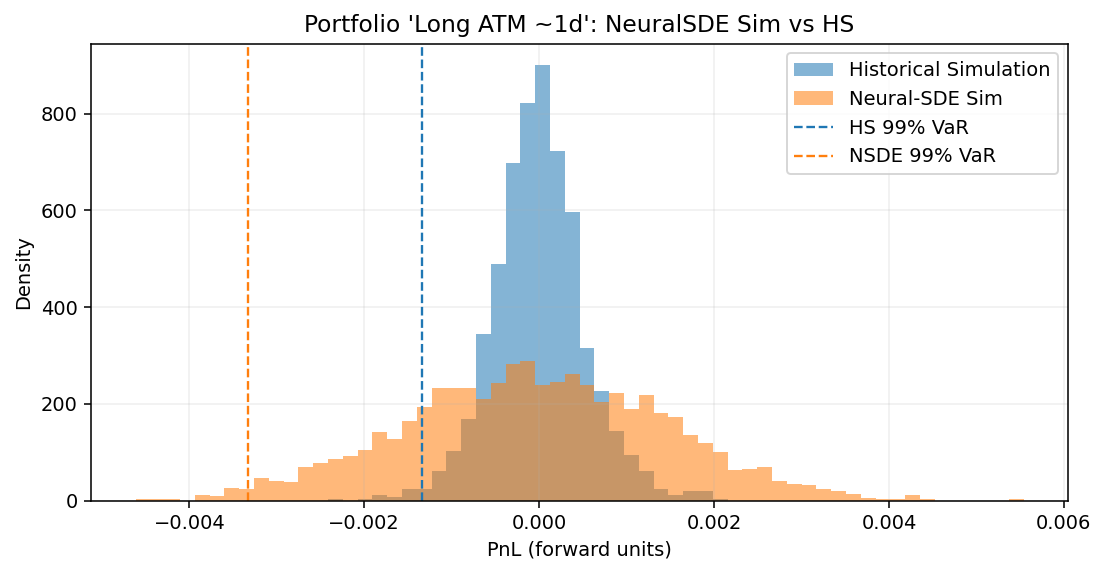

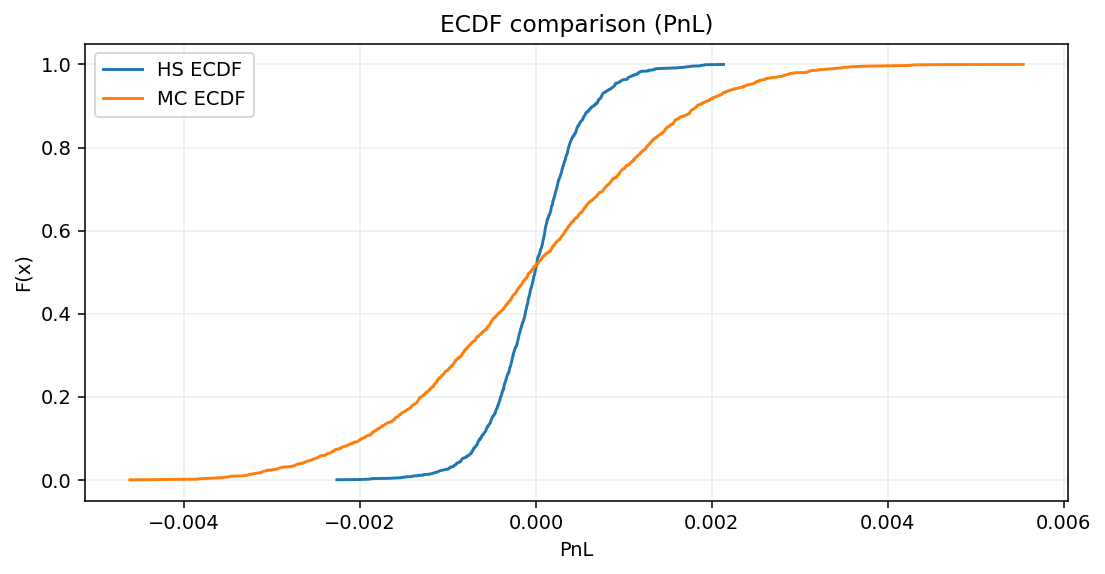

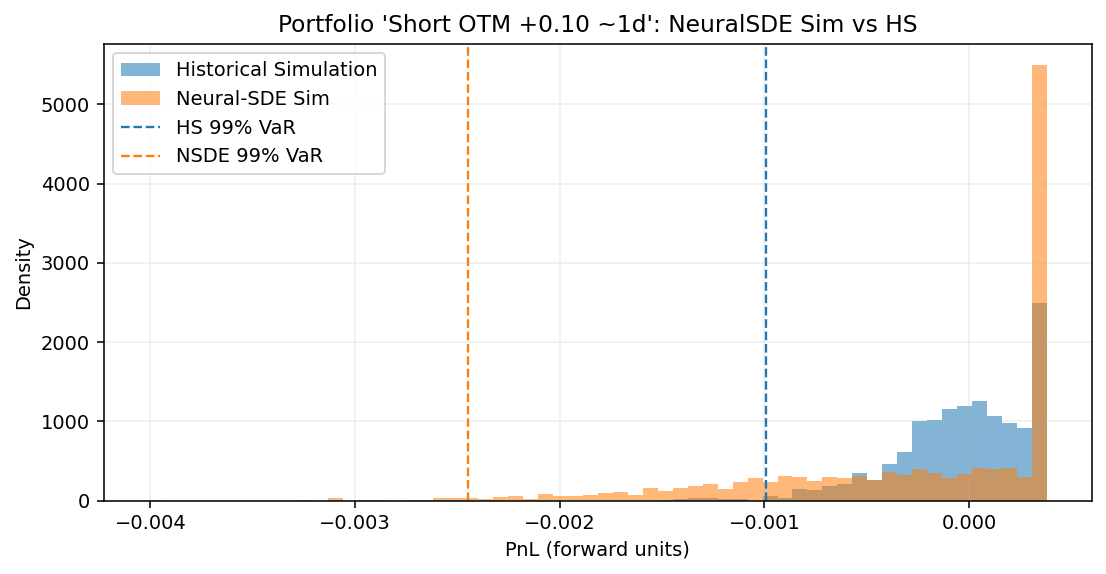

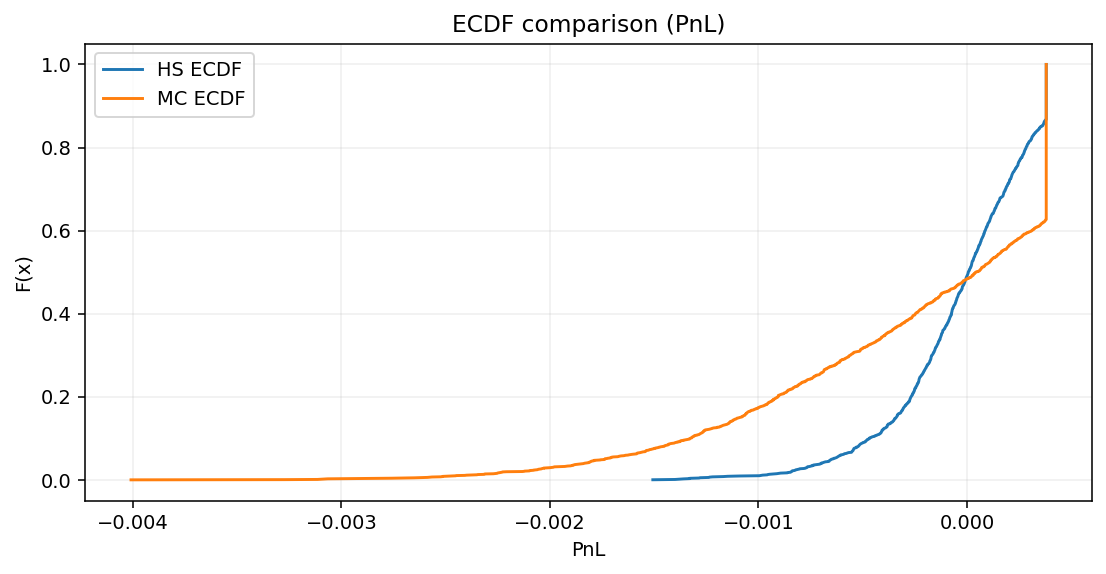

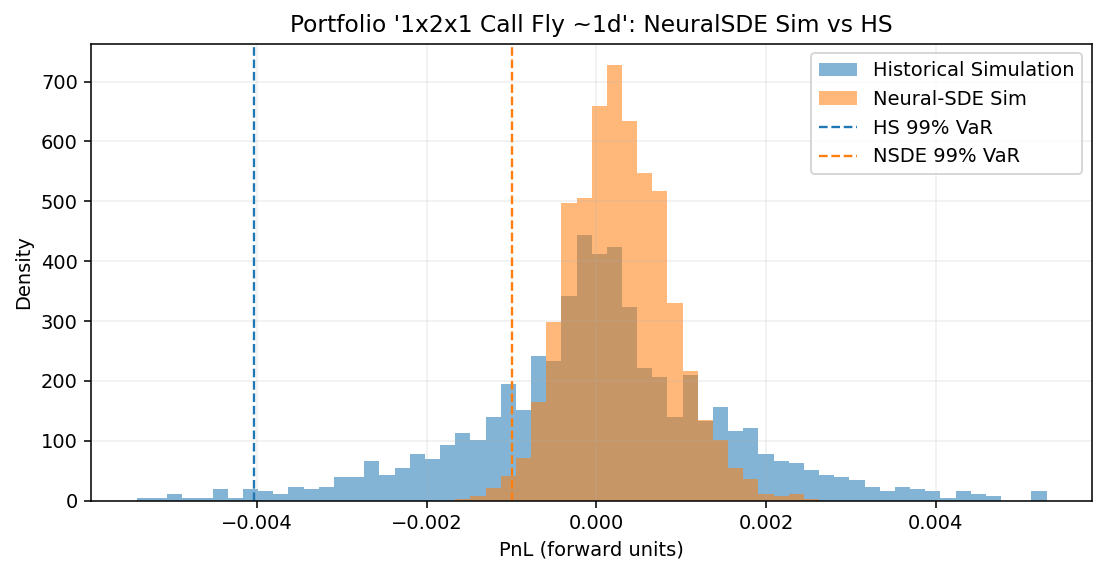

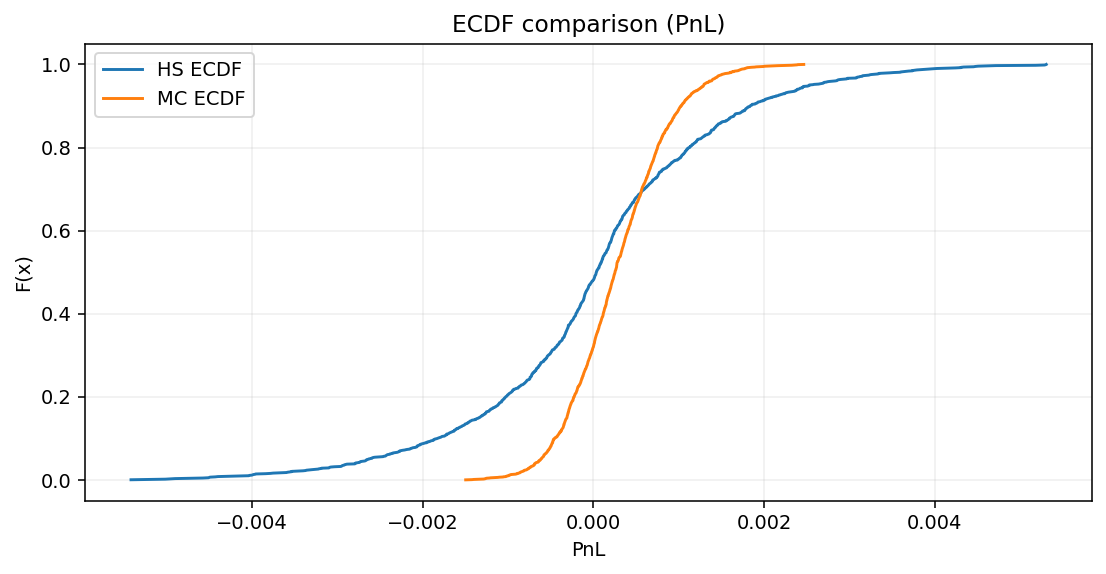

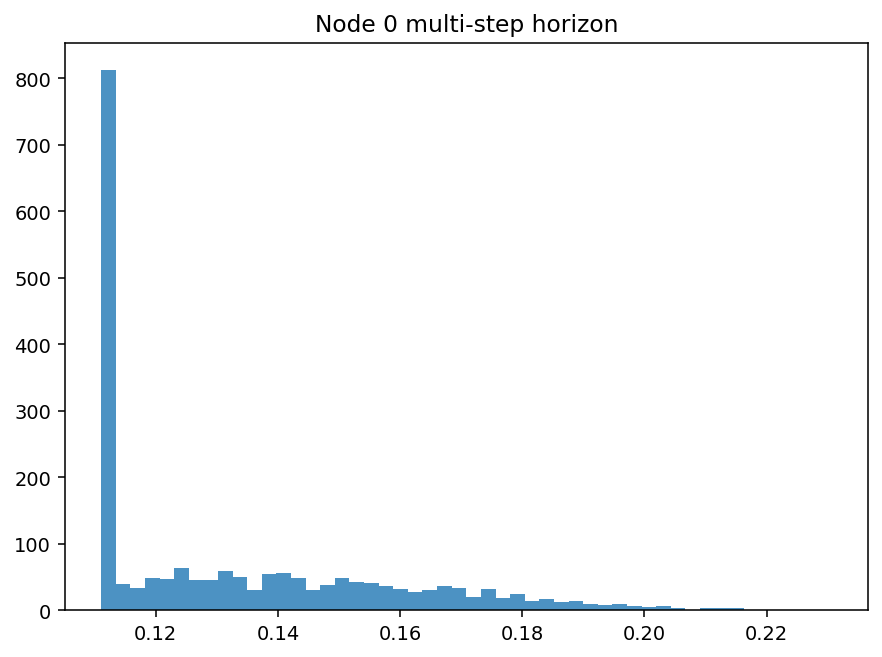

Done.


In [119]:
# End-to-end MC vs HS simulation using the trained Neural-SDE and the decoded lattice/factors.

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt

# --- repo imports (ensure repo root on sys.path) ---
try:
    ROOT = Path(
        __import__("subprocess").check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
    )
except Exception:
    ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from neural_sde.loss import (
    likelihood_training,                      # -> [neural_sde/loss.py]
    build_xi_training_data                    # -> [neural_sde/loss.py]
)
from neural_sde.constraints import (
    compute_factor_polytope_vertices,
    assemble_Wb_for_shrinkage,
    build_factor_path,
    calc_diffusion_scaling,
    shrink_matrix_and_diag,
    shrink_diag_covmatch,
    normalise_dist_diffusion,          # <-- add
    normalise_dist_drift,              # <-- add
    calc_drift_correction, 
    _apply_boundary_correction            # <-- add
)
# Factors -> prices helpers exist in factors.decode but we reimplement here for clarity
# (same algebra as [`factors.decode.reconstruct_prices`](factors/decode.py))

plt.rcParams["figure.dpi"] = 140

# ----------------------------
# 0) Load decoding artifact
# ----------------------------
def load_outs(artifact: Path):
    outs = joblib.load(artifact)
    print("Loaded:", artifact)
    return outs

# ----------------------------
# 1) Shrink geometry + training
# ----------------------------
def train_neural_sde_with_shrink(outs, *, epochs=500, batch=256, lr=5e-5, zero_drift=False):
    # Polytope geometry
    poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)
    W, b = assemble_Wb_for_shrinkage(poly, include_box=True)

    # Factor path X and diffs dX (train)
    X  = build_factor_path(outs, xi_builder=None)      # (T, p)  order = dyn|stat|sa
    dX = np.diff(X, axis=0)
    X  = X[:-1]                                        # align to dX

    # Calibrate shrinkage intensity so that projection “epsilon/proj_scale” hits ~0.95
    frac_critical_threshold = 0.9
    critical_value = 0.95
    proj_scale = 0.9

    dist_X = np.abs(W @ X.T - b[:, None])              # (n_faces, T)
    per_face_max = np.max(dist_X, axis=1)              # (n_faces,)
    critical_threshold = frac_critical_threshold * np.min(per_face_max)
    dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / max(critical_threshold, 1e-12)

    Omegas, det_Omega, proj_dX = calc_diffusion_scaling(
        W=W, b=b, X=X, dX=dX, dist_multiplier=dist_multiplier, proj_scale=proj_scale
    )

    # Same for test to monitor generalization
    _, X_te, _ = build_xi_training_data(outs)
    dX_te = np.diff(X_te, axis=0); X_te = X_te[:-1]
    Omegas_te, det_Omega_te, proj_dX_te = calc_diffusion_scaling(
        W=W, b=b, X=X_te, dX=dX_te, dist_multiplier=dist_multiplier, proj_scale=proj_scale
    )

    # Train Neural-SDE one-step likelihood with supplied shrink stats
    train_losses, test_losses, model, X_train = likelihood_training(
        outs,
        Omega_tr=Omegas,           det_Omega_tr=det_Omega,   proj_dX_tr=proj_dX,
        Omega_te=Omegas_te,        det_Omega_te=det_Omega_te, proj_dX_te=proj_dX_te,
        n_epochs=epochs, batch_size=batch, lr=lr, data="xi", zero_drift=zero_drift, model=None
    )
    print("Training done. Final train/test NLL:", train_losses[-1], test_losses[-1])
    return model

# ----------------------------
# 2) Factors -> prices mapping
# ----------------------------
def split_blocks_factory(outs):
    k_dyn  = outs.G_dyn.shape[0] if getattr(outs, "G_dyn", None) is not None and outs.G_dyn.size else 0
    k_stat = outs.G_stat.shape[0] if getattr(outs, "G_stat", None) is not None and outs.G_stat.size else 0
    k_sa   = outs.G_sa.shape[0]   if getattr(outs, "G_sa",   None) is not None and outs.G_sa.size   else 0
    def split_blocks(x):
        i=0
        xd = x[..., i:i+k_dyn];  i += k_dyn
        xs = x[..., i:i+k_stat]; i += k_stat
        xa = x[..., i:i+k_sa] if k_sa>0 else x[..., :0]
        return xd, xs, xa
    return split_blocks, k_dyn, k_stat, k_sa

def factors_to_prices_factory(outs):
    split_blocks, k_dyn, k_stat, k_sa = split_blocks_factory(outs)
    N  = outs.G0.shape[0]
    G0 = outs.G0.astype(np.float64)
    Gd = outs.G_dyn.astype(np.float64) if k_dyn>0 else np.zeros((0, N))
    Gs = outs.G_stat.astype(np.float64) if k_stat>0 else np.zeros((0, N))
    Ga = outs.G_sa.astype(np.float64)   if k_sa>0   else np.zeros((0, N))
    m = outs.nodes_sub[:, 1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)  # lower no‑arb bound

    def factors_to_prices(X):
        B, T1, _ = X.shape
        C = np.empty((B, T1, N), dtype=np.float64)
        for t in range(T1):
            xd,xs,xa = split_blocks(X[:, t, :])
            term = np.broadcast_to(G0, (B, N)).copy()
            if k_dyn:  term += xd @ Gd
            if k_stat: term += xs @ Gs
            if k_sa:   term += xa @ Ga
            C[:, t, :] = term
        return np.clip(C, lb[None, None, :], 1.0)

    return factors_to_prices

# ----------------------------
# 3) One-step and multi-step MC
# ----------------------------
@torch.no_grad()
def simulate_factors_mc_shrunk(
    model, x0_raw, *,
    n_steps=1, n_paths=512, dt_seconds=60.0,
    W=None, b=None, X_interior=None,
    dist_multiplier=1.0, proj_scale=0.9,
    rho_star=1e-5, epsmu_star=10.0,
    s_floor=0.5, s_ceil=1.0, bc_cap=5.0,
    clamp_sig=1e-9,
    to_model=lambda x: x, from_model=lambda x: x
):
    """
    EM with diagonal diffusion as learned, but:
      - shrink diag σ by geometry-aware multipliers s in [s_floor, s_ceil]
      - correct drift with inward face-based BC (masked to inward faces)
    """
    assert W is not None and b is not None and X_interior is not None
    device = next(model.parameters()).device
    x0 = to_model(x0_raw.astype(np.float64))
    x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).float().to(device)
    DT  = torch.tensor(float(dt_seconds), dtype=torch.float32, device=device).view(1,1)
    sDT = torch.sqrt(DT)
    out = [x.clone()]

    p = x0_raw.shape[0]
    W_np, b_np, Xin_np = np.asarray(W), np.asarray(b), np.asarray(X_interior)

    for _ in range(n_steps):
        mu  = model.f(0.0, x)                         # (B,p)
        sig = model.g(0.0, x).clamp_min(clamp_sig)    # (B,p)
        mu_np  = mu.detach().cpu().numpy()
        sig_np = sig.detach().cpu().numpy()

        # step per path (kept simple/robust)
        x_np = from_model(x.detach().cpu().numpy())   # model -> raw Xi for geometry
        x_next = np.empty_like(x_np)

        for bidx in range(n_paths):
            x_cur = x_np[bidx]            # (p,)
            mu_t  = mu_np[bidx]           # (p,)
            sig_t = sig_np[bidx]          # (p,)

            # --- diffusion shrinkage (cov-match; pick p closest faces)
            rho = np.abs(W_np @ x_cur - b_np) / (np.linalg.norm(W_np, axis=1) + 1e-12)
            eps_sigma = normalise_dist_diffusion(rho, dist_multiplier, proj_scale)  # (m,)
            idx = np.argsort(eps_sigma)[:p]
            Wd = W_np[idx, :]
            eps_sel = np.maximum(eps_sigma[idx], 1e-6)

            # Q from QR of Wd.T (orthonormal cols)
            Q = np.linalg.qr(Wd.T)[0]                     # (p,p)
            P = Q @ np.diag(eps_sel) @ Q.T                # (p,p)

            s = shrink_diag_covmatch(
                    torch.from_numpy(P[None]).float(),
                    torch.from_numpy(sig_t[None]).float()
                ).squeeze(0).cpu().numpy()                # (p,)
            s = np.clip(s, s_floor, s_ceil)

            # --- drift correction (mask to inward faces; per-dim clip)
            eps_mu = normalise_dist_drift(rho, rho_star, epsmu_star)   # (m,)
            muW = W_np @ mu_t                                         # (m,)
            corr_dirs = (Xin_np - x_cur[None, :])                      # (m,p)
            denom = (corr_dirs * W_np).sum(axis=1)                     # (m,)

            need   = (-muW - eps_mu) > 0.0
            inward = denom > 1e-12
            mask   = need & inward

            delta_mu = np.zeros_like(mu_t)
            if np.any(mask):
                wts = (-muW[mask] - eps_mu[mask]) / denom[mask]
                delta_mu = (wts[:, None] * corr_dirs[mask]).sum(axis=0)
                delta_mu = np.clip(delta_mu, -bc_cap, bc_cap)

            mu_corr = mu_t + delta_mu

            # --- one EM step (in raw Xi), then return to model space for next net eval
            eps = np.random.normal(size=p)
            x1_raw = x_cur + mu_corr*float(dt_seconds) + (s*sig_t)*np.sqrt(float(dt_seconds))*eps
            x_next[bidx] = x1_raw

        # push x_next to model space and continue
        x = torch.from_numpy(to_model(x_next)).float().to(device)
        out.append(x.clone())

    X_mod = torch.stack(out, dim=1).cpu().numpy()           # (B, T+1, p) in model space
    X_raw = from_model(X_mod)                                # -> raw Xi
    return X_raw

# @torch.no_grad()
# def simulate_factors_mc_shrunk(
#     model, x0_raw, *,
#     n_steps=1, n_paths=512, dt_seconds=60.0,
#     H=None, h=None,                 # <-- pass H,h for shrink
#     corr_dirs=None, epsmu=None,     # <-- pass tensors from calc_drift_correction
#     t_idx_global=None,              # <-- index of x0 on the reference path
#     clamp_sig=1e-9,
#     to_model=lambda x: x, from_model=lambda x: x
# ):
#     assert H is not None and h is not None, "need (H,h) for shrink"
#     device = next(model.parameters()).device
#     torch_dtype = torch.float32

#     x0 = to_model(x0_raw.astype(np.float64))
#     x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).to(device=device, dtype=torch_dtype)
#     DT = torch.tensor(float(dt_seconds), dtype=torch_dtype, device=device).view(1, 1)
#     out = [x.clone()]

#     H_t = torch.from_numpy(np.asarray(H)).to(device=device, dtype=torch_dtype)
#     h_t = torch.from_numpy(np.asarray(h)).to(device=device, dtype=torch_dtype)

#     for _ in range(n_steps):
#         mu  = model.f(0.0, x)                          # (B,p)
#         sig = model.g(0.0, x).clamp_min(clamp_sig)     # (B,p)

#         # Drift boundary correction (same as training)
#         if (corr_dirs is not None) and (epsmu is not None) and (t_idx_global is not None):
#             t_idx = torch.full((x.size(0),), int(t_idx_global), dtype=torch.long, device=device)
#             mu = _apply_boundary_correction(
#                 mu, t_idx, corr_dirs=corr_dirs, epsmu=epsmu,
#                 bc_lambda=1.0, bc_eps_floor=1e-8, bc_cap=None, bc_epsmu_cutoff=None, device=device
#             )

#         # Diffusion shrinkage (same geometry as training)
#         P_mat = shrink_matrix_and_diag(x, H_t, h_t, mode="matrix")   # (B,p,p)
#         s     = shrink_diag_covmatch(P_mat, sig)                     # (B,p)
#         sig   = s * sig

#         eps = torch.randn_like(x)
#         x   = x + mu*DT + sig*torch.sqrt(DT)*eps
#         out.append(x.clone())

#     X_mod = torch.stack(out, dim=1).cpu().numpy()
#     return from_model(X_mod)  # raw Xi

# ----------------------------
# 4) Historical Simulation (HS) in factor space
# ----------------------------
def build_hs_from_factors(outs, x0_raw):
    Xi_tr, Xi_te, _ = build_xi_training_data(outs)
    Xi_hist = np.vstack([Xi_tr, Xi_te])
    dXi = Xi_hist[1:] - Xi_hist[:-1]              # (M, p)
    B = dXi.shape[0]
    X_seq = np.stack([np.tile(x0_raw, (B,1)), x0_raw[None,:] + dXi], axis=1)   # (B,2,p)
    return X_seq

# ----------------------------
# 5) Portfolio utils
# ----------------------------
def nearest_node_index(tau, m, nodes):
    diffs = nodes - np.array([tau, m])[None, :]
    return int(np.argmin(np.sum(diffs*diffs, axis=1)))

def make_q_from_spec(spec, nodes):
    N = nodes.shape[0]
    q = np.zeros(N, dtype=float)
    if isinstance(spec, dict):
        for j, qty in spec.items():
            q[int(j)] += float(qty)
        return q
    for tau, m, qty in spec:
        j = nearest_node_index(float(tau), float(m), nodes)
        q[j] += float(qty)
    return q

def portfolio_pnl_from_c(C_sim, q, F_path=None, multipliers=None):
    C_sim = np.asarray(C_sim); q = np.asarray(q).reshape(-1)
    B, T1, N = C_sim.shape
    w = np.ones(N) if multipliers is None else np.asarray(multipliers).reshape(-1)
    notional = q * w
    V = C_sim @ notional                        # (B, T+1) forward-units
    V = V * (1.0 if F_path is None else F_path)
    return V[:, -1] - V[:, 0]

def overlay_returns_histograms(C_sim_MC, C_sim_HS, q, title="Portfolio return distribution: MC vs HS"):
    x_MC = portfolio_pnl_from_c(C_sim_MC, q)
    x_HS = portfolio_pnl_from_c(C_sim_HS, q)
    x_MC = x_MC[np.isfinite(x_MC)]
    x_HS = x_HS[np.isfinite(x_HS)]
    lo = np.min([x_MC.min(), x_HS.min()]); hi = np.max([x_MC.max(), x_HS.max()])
    edges = np.linspace(lo, hi, 60+1)

    plt.figure(figsize=(8,4.2))
    plt.hist(x_HS, bins=edges, density=True, alpha=0.55, label="Historical Simulation")
    plt.hist(x_MC, bins=edges, density=True, alpha=0.55, label="Neural‑SDE Sim")
    plt.axvline(np.quantile(x_HS, 0.01), color="C0", ls="--", lw=1.2, label="HS 99% VaR")
    plt.axvline(np.quantile(x_MC, 0.01), color="C1", ls="--", lw=1.2, label="NSDE 99% VaR")
    plt.title(title); plt.xlabel("PnL (forward units)"); plt.ylabel("Density")
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

    # ECDF
    def ecdf(x): xs = np.sort(x); ys = np.arange(1,len(x)+1)/len(x); return xs, ys
    xs_HS,F_HS = ecdf(x_HS); xs_MC,F_MC = ecdf(x_MC)
    plt.figure(figsize=(8,4.2))
    plt.plot(xs_HS, F_HS, label="HS ECDF"); plt.plot(xs_MC, F_MC, label="MC ECDF")
    plt.title("ECDF comparison (PnL)"); plt.xlabel("PnL"); plt.ylabel("F(x)")
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

# ----------------------------
# 6) Main
# ----------------------------
def main():
    # 0) inputs
    artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
    outs = load_outs(artifact)

    # 1) train SDE (or replace with a previously trained model)
    model = train_neural_sde_with_shrink(outs, epochs=600, batch=256, lr=5e-5, zero_drift=True)
    device = next(model.parameters()).device
    print("Model device:", device)

    # 2) time step scaling: SECONDS (consistent with training and validation code)
    sec_per_year = 1
    tt_tr = pd.to_datetime(outs.C_train.index.values)
    dt_tr = dt_tr = (tt_tr[1:] - tt_tr[:-1]).to_numpy(dtype="timedelta64[s]").astype(np.float64) / sec_per_year
    dt_seconds = float(np.median(dt_tr)) if len(dt_tr) else 60.0
    print("Median dt (seconds):", dt_seconds)

    # 3) start state x0 (use last observed test state if available for apples-to-apples)
    Xi_tr, Xi_te, _ = build_xi_training_data(outs)
    x0_raw = (Xi_te[-1] if len(Xi_te) else Xi_tr[-1]).astype(np.float64)
    # 3a) polytope (W,b)
    poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)
    W, b = assemble_Wb_for_shrinkage(poly, include_box = True)
    H, h = poly['H'], poly['h']

    # 3b) Calibrate dist_multiplier (same scheme you used in training helper)
    X_all = build_factor_path(outs, xi_builder=None)        # (T, p)
    dist = np.abs(W @ X_all.T - b[:, None])                 # (m, T)
    per_face_max = np.max(dist, axis=1)
    frac_critical_threshold = 0.9
    critical_value = 0.95
    proj_scale = 0.9
    critical_threshold = frac_critical_threshold * float(np.min(per_face_max))
    dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / max(critical_threshold, 1e-12)

    # 3c) Precompute interior anchors for BC once (use test factors as reference)
    X_ref = np.vstack([Xi_tr, Xi_te]) if len(Xi_te) else Xi_tr
    X_interior, corr_dirs_flat, epsmu = calc_drift_correction(W, b, X_ref, rho_star=1e-5, epsmu_star=10.0, tol_face=1e-6)
    t_idx_global = X_ref.shape[0] - 1

    # 4) Monte‑Carlo: one-step to compare to HS
    X_mc = simulate_factors_mc_shrunk(
        model, x0_raw,
        n_steps=1, n_paths=2048, dt_seconds=dt_seconds,
        W=W, b=b, X_interior=X_interior,
        dist_multiplier=dist_multiplier, proj_scale=proj_scale,
        rho_star=1e-5, epsmu_star=10.0,
        s_floor=0.2, s_ceil=1.0, bc_cap=5.0,
        clamp_sig=1e-9,
        to_model=lambda x: x, from_model=lambda x: x
    )
#     X_mc = simulate_factors_mc_shrunk(
#     model, x0_raw,
#     n_steps=1, n_paths=2048, dt_seconds=dt_seconds,
#     H=H, h=h,
#     corr_dirs=torch.from_numpy(corr_dirs_flat.reshape(X_ref.shape[0], -1, x0_raw.size)).to(device=next(model.parameters()).device),
#     epsmu=torch.from_numpy(epsmu).to(device=next(model.parameters()).device),
#     t_idx_global=t_idx_global,
#     to_model=lambda x: x, from_model=lambda x: x
# )
    factors_to_prices = factors_to_prices_factory(outs)
    C_mc = factors_to_prices(X_mc)     # (B,2,N)
    # 5) Historical Simulation (same horizon, one step in factor space)
    X_hs = build_hs_from_factors(outs, x0_raw)          # (B, 2, p)
    C_hs = factors_to_prices(X_hs)                      # (B, 2, N)

    # 6) Quick diagnostics: per-node histogram finiteness
    C_T = C_mc[:, -1, :]
    if not np.isfinite(C_T).all():
        bad_nodes = np.where(~np.isfinite(C_T).all(axis=0))[0]
        bad_paths = np.where(~np.isfinite(C_T).all(axis=1))[0]
        print(f"[warn] MC produced non‑finite prices. bad_nodes={bad_nodes.tolist()}, bad_paths={bad_paths.size}")

    # 7) Example portfolio set
    nodes = getattr(outs, "nodes_sub", outs.nodes_sub)
    portfolios = {
        "Long ATM ~1d": [(1.0/365.0, 0.0, +1.0)],
        "Short OTM +0.10 ~1d": [(1.0/365.0, +0.10, -1.0)],
        "1x2x1 Call Fly ~1d": [(1.0/365.0, -0.10, +1.0), (1.0/365.0, 0.0, -2.0), (1.0/365.0, +0.10, +1.0)],
    }

    # 8) Plot MC vs HS distributions for each portfolio
    for name, spec in portfolios.items():
        q = make_q_from_spec(spec, nodes)
        overlay_returns_histograms(C_mc, C_hs, q, title=f"Portfolio '{name}': NeuralSDE Sim vs HS")

    # 9) Optionally, multi-step MC with same per-step dt (e.g., 60 steps ~ 60 minutes)
    do_multistep = True
    if do_multistep:
        X_mc60 = simulate_factors_mc(model, x0_raw, n_steps=60, n_paths=2048, dt_seconds=dt_seconds)
        C_mc60 = factors_to_prices(X_mc60)
        # sanity histogram at one node
        C_T60 = C_mc60[:, -1, :]
        j = 0
        vals = C_T60[:, j]
        vals = vals[np.isfinite(vals)]
        if vals.size:
            plt.figure(); plt.hist(vals, bins=50, alpha=0.8); plt.title(f"Node {j} multi‑step horizon"); plt.tight_layout(); plt.show()

    print("Done.")

if __name__ == "__main__":
    main()


In [2]:
# ...existing code...
# Calibrate k

# ...existing code...
import joblib
from pathlib import Path
import subprocess, sys


try:
    ROOT = Path(subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip())
except Exception:
    ROOT = Path.cwd().resolve().parent  # experiments/ -> repo root

# Make repo packages (e.g., `pipeline`) importable for unpickling
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# (optional) pre-import the class’ module used in the pickle
# from pipeline.algo1 import Algo1Outputs

artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
outs = joblib.load(artifact)
print("Loaded:", artifact)
import torch
from neural_sde.constraints import compute_factor_polytope_vertices, assemble_Wb_for_shrinkage, build_factor_path, calc_diffusion_scaling
from neural_sde.nets import NeuralSDEWithShrink                       # [neural_sde/nets.py](neural_sde/nets.py)
from neural_sde.loss import likelihood_training, build_xi_training_data                        # [neural_sde/loss.py](neural_sde/loss.py)
import numpy as np
poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)  # -> H,h
W, b = assemble_Wb_for_shrinkage(poly, include_box=True)
X_all = build_factor_path(outs, xi_builder=None)   # (T,p)
dist_X = np.abs(W @ X_all.T - b[:, None])          # (m,T) rows already unit-norm
per_face_max = np.max(dist_X, axis=1)
frac_critical_threshold = 0.9
critical_value = 0.95
proj_scale = 0.9
critical_threshold = frac_critical_threshold * float(np.min(per_face_max))
dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / max(critical_threshold, 1e-12)

# Train with endogenous Ω
from neural_sde.loss import likelihood_training_endogenous  # [neural_sde/loss.py](neural_sde/loss.py)
tr_losses, te_losses, model, X_train = likelihood_training_endogenous(
    outs, n_epochs=1000, batch_size=256, lr=5e-5, zero_drift=False, data="xi",
    dist_multiplier=dist_multiplier, proj_scale=proj_scale,
)



Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl
Epoch 1/1000  Train NLL: 1.6453e+02  Test NLL: 1.1410e+02
Epoch 2/1000  Train NLL: 1.3658e+02  Test NLL: 9.5453e+01
Epoch 3/1000  Train NLL: 1.1443e+02  Test NLL: 8.1789e+01
Epoch 4/1000  Train NLL: 9.5022e+01  Test NLL: 6.8892e+01
Epoch 5/1000  Train NLL: 7.6903e+01  Test NLL: 5.4599e+01
Epoch 6/1000  Train NLL: 6.0800e+01  Test NLL: 4.1435e+01
Epoch 7/1000  Train NLL: 4.6655e+01  Test NLL: 3.0761e+01
Epoch 8/1000  Train NLL: 3.3968e+01  Test NLL: 2.1906e+01
Epoch 9/1000  Train NLL: 2.2956e+01  Test NLL: 1.4226e+01
Epoch 10/1000  Train NLL: 1.3582e+01  Test NLL: 7.4094e+00
Epoch 11/1000  Train NLL: 5.7331e+00  Test NLL: 1.7659e+00
Epoch 12/1000  Train NLL: -6.4986e-01  Test NLL: -3.4237e+00
Epoch 13/1000  Train NLL: -5.6547e+00  Test NLL: -7.1372e+00
Epoch 14/1000  Train NLL: -9.3538e+00  Test NLL: -9.5916e+00
Epoch 15/1000  Train NLL: -1.1808e+01  Test NLL: -1.1747e+01
E

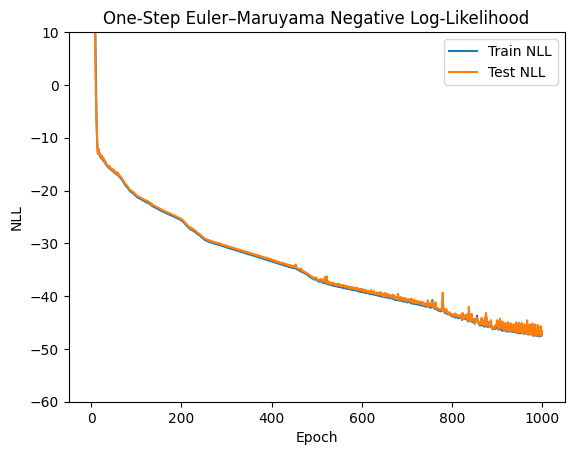

In [4]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(tr_losses, label="Train NLL")
plt.plot(te_losses, label="Test NLL")
plt.title("One-Step Euler–Maruyama Negative Log-Likelihood")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.ylim(top = 10)
plt.ylim(bottom = -60)
plt.show()

In [45]:
import numpy as np
import torch

from neural_sde.loss import build_xi_training_data, _build_omega_proj_from_state  # [`neural_sde.loss.build_xi_training_data`](neural_sde/loss.py)
from neural_sde.constraints import compute_factor_polytope_vertices               # [`neural_sde/constraints.compute_factor_polytope_vertices`](neural_sde/constraints.py)

def stack_G(out):
    """Return factor loadings stacked in the same order used for Xi training: dyn|stat|sa."""
    Gd = np.asarray(getattr(out, "G_dyn", np.zeros((0, out.C_train.shape[1]))), float)
    Gs = np.asarray(getattr(out, "G_stat", np.zeros((0, out.C_train.shape[1]))), float)
    Ga = np.asarray(getattr(out, "G_sa",   np.zeros((0, out.C_train.shape[1]))), float)
    G = np.vstack([Gd, Gs, Ga])
    names = build_xi_training_data(out)[2]  # dyn*, stat*, sa*
    return G, names

def portfolio_exposure(G, w_nodes):
    """s = ∑_i w_i G[:, i]  (factor exposure of the portfolio)."""
    return G @ np.asarray(w_nodes, float)

def hedge_exposures(G, hedge_col_idx):
    """B = [g_h1, g_h2, ...] with g_hj the factor exposure of hedge instrument j."""
    idx = np.asarray(hedge_col_idx, int)
    return G[:, idx]  # shape (p, k)

@torch.no_grad()
def instant_cov(model, out, use_test=False, use_endogenous_shrink=True,
                dist_multiplier=1.0, proj_scale=0.9, eps=1e-12):
    """
    Build instantaneous factor covariance sequence Σ_t:
      - base Σ_t from g(y_t): diag(σ)^2 if g is diagonal or L Lᵀ if g outputs a Cholesky
      - if use_endogenous_shrink: Σ̃_t = Ω_t Σ_t Ω_tᵀ using the same Ω as endogenous trainer.
    Returns Σ (T-1, p, p) aligned with Xi increments.
    """
    X_tr, X_te, _ = build_xi_training_data(out)
    X = X_te if use_test else X_tr
    # align to increments (T-1)
    Y0 = torch.from_numpy(X[:-1]).float()
    Y1 = torch.from_numpy(X[1:]).float()
    device = next(model.parameters()).device
    Y0 = Y0.to(device); Y1 = Y1.to(device)

    gout = model.g(0.0, Y0)             # (T-1,p) or (T-1,p,p)
    if gout.dim() == 2:
        Sigma = torch.diag_embed(gout.clamp_min(1e-9)**2)
    else:
        L = gout
        Sigma = L @ L.transpose(1, 2)

    if use_endogenous_shrink:
        poly = compute_factor_polytope_vertices(out, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)
        H = torch.from_numpy(poly["H"]).float().to(device)
        h = torch.from_numpy(poly["h"]).float().to(device)
        Omega, _, _ = _build_omega_proj_from_state(Y0, Y1, H, h,
                                                   dist_multiplier=dist_multiplier,
                                                   proj_scale=proj_scale)
        Sigma = Omega @ Sigma @ Omega.transpose(1, 2)

    return Sigma.cpu().numpy()

def minvar_units_static(G, w_nodes, hedge_cols, Sigma_seq):
    """
    Static MV units using Σ̄ = mean_t Σ_t.
    u* = (Bᵀ Σ̄ B)^{-1} Bᵀ Σ̄ s
    """
    s = portfolio_exposure(G, w_nodes)            # (p,)
    B = hedge_exposures(G, hedge_cols)            # (p,k)
    Sbar = Sigma_seq.mean(axis=0)                 # (p,p)
    M = B.T @ Sbar @ B
    rhs = B.T @ Sbar @ s
    return np.linalg.solve(M + 1e-12*np.eye(M.shape[0]), rhs)

def minvar_units_dynamic(G, w_nodes, hedge_cols, Sigma_seq):
    """
    Dynamic MV units per step t (same closed form, using Σ_t).
    Returns u_t of shape (T-1, k).
    """
    s = portfolio_exposure(G, w_nodes)            # (p,)
    B = hedge_exposures(G, hedge_cols)            # (p,k)
    Tm1 = Sigma_seq.shape[0]
    U = np.zeros((Tm1, B.shape[1]))
    I = np.eye(B.shape[1])
    for t in range(Tm1):
        St = Sigma_seq[t]
        M = B.T @ St @ B
        rhs = B.T @ St @ s
        U[t] = np.linalg.solve(M + 1e-12*I, rhs)
    return U

def sensitivity_units(G, w_nodes, hedge_cols, target="all"):
    """
    Solve B u = s on targeted factors.
    - target="all": least-squares neutralization across all p factors
    - target=("dyn0","stat0",...): pick columns of s by name (exact match)
    """
    s = portfolio_exposure(G, w_nodes)            # (p,)
    B = hedge_exposures(G, hedge_cols)            # (p,k)
    if isinstance(target, str) and target == "all":
        # LS: min ||B u - s||_2
        u, *_ = np.linalg.lstsq(B, s, rcond=None)
        return u
    raise NotImplementedError("Pass an explicit list of factor indices if you want a subset.")


# 1) Factor loadings in the exact Xi order used for training
G, names = stack_G(outs)  # outs from pipeline: [pipeline/algo1.py](pipeline/algo1.py) or [pipeline/algo1_PCA.py](pipeline/algo1_PCA.py)

# 2) Pick a portfolio on the lattice (weights per node, length N = C_* columns)
#    Example: long +1 on the ATM, 30D node; others 0
N = outs.C_test.shape[1]
w_nodes = np.zeros(N)
# find the column index closest to τ≈30/365 and m≈0
nodes = outs.nodes_sub
tau = nodes[:,0]; m = nodes[:,1]
j_atm_30d = int(np.argmin((tau - 30/365.0)**2 + (m - 0.0)**2))
w_nodes[j_atm_30d] = 1.0

# 3) Choose hedging instruments (columns). Example: two different maturities near ATM
j_atm_7d  = int(np.argmin((tau - 7/365.0)**2  + (m - 0.0)**2))
j_atm_60d = int(np.argmin((tau - 60/365.0)**2 + (m - 0.0)**2))
hedge_cols = [j_atm_7d, j_atm_60d]

# 4) Build instantaneous factor covariance sequence from your trained SDE
Sigma_seq = instant_cov(model, outs, use_test=True, use_endogenous_shrink=True,
                        dist_multiplier=1.0, proj_scale=0.9)

# 5a) Sensitivity-neutralization units (all factors, least squares)
u_sens = sensitivity_units(G, w_nodes, hedge_cols, target="all")

# 5b) Minimum-variance units (static and dynamic)
u_mv_static = minvar_units_static(G, w_nodes, hedge_cols, Sigma_seq)      # constant units
u_mv_dyn    = minvar_units_dynamic(G, w_nodes, hedge_cols, Sigma_seq)     # time-varying units (T-1, k)

print("sens units:", u_sens)
print("MV static units:", u_mv_static)
print("MV dynamic (first 3):", u_mv_dyn[:3])

sens units: [0.79849797 0.02695796]
MV static units: [0.79934456 0.0254092 ]
MV dynamic (first 3): [[0.799431   0.0253906 ]
 [0.79968402 0.02618872]
 [0.79984417 0.02614729]]


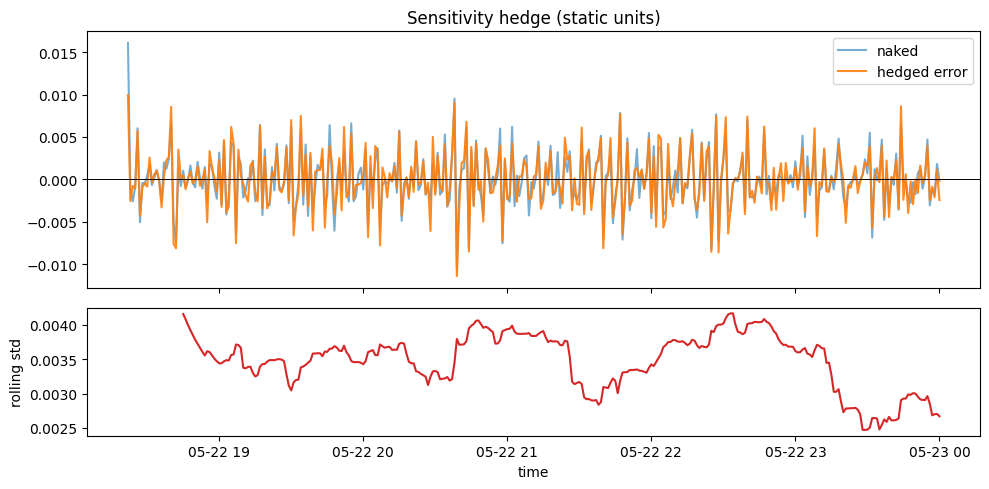

std naked=0.003266 | std hedged=0.003428 | variance reduction=-10.2%


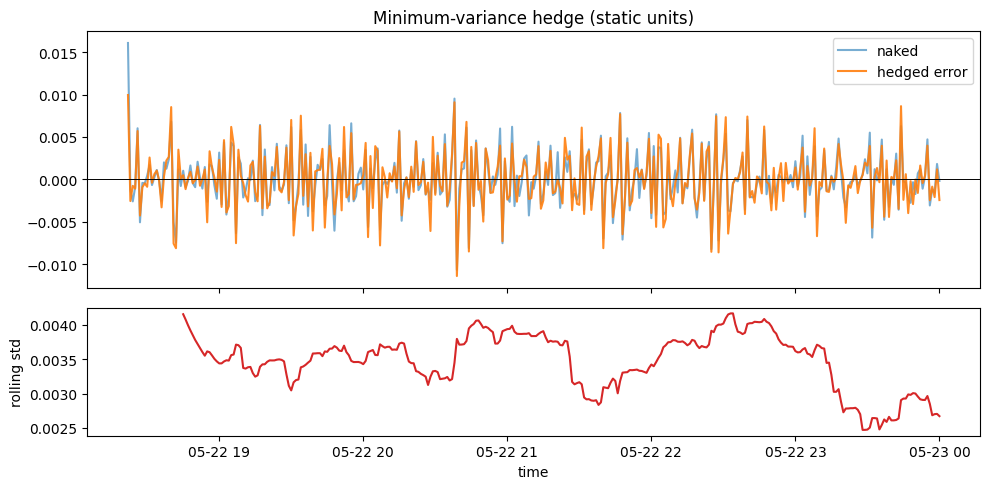

std naked=0.003266 | std hedged=0.003427 | variance reduction=-10.1%
[info] aligning lengths: dC=339 vs U=338 -> using L=338


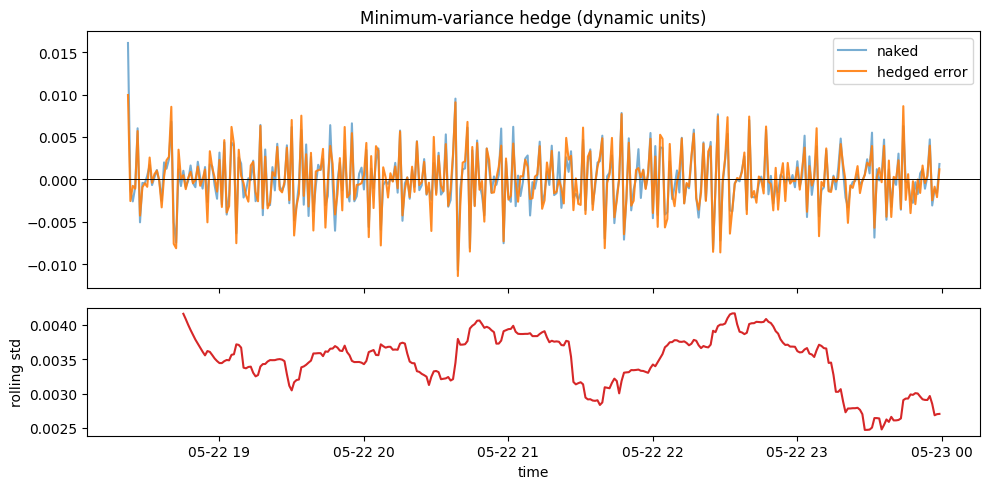

std naked=0.003271 | std hedged=0.00343 | variance reduction=-10.0%


In [10]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def plot_hedge_errors(outs, w_nodes, hedge_cols, units, use_test=True, title=None):
    import numpy as np, pandas as pd, matplotlib.pyplot as plt

    C = (outs.C_test.values if use_test else outs.C_train.values)  # [T, N]
    idx = (outs.C_test.index  if use_test else outs.C_train.index)
    dC = C[1:] - C[:-1]                                           # [T-1, N]

    U = np.asarray(units, float)
    if U.ndim == 1:
        U = np.tile(U, (dC.shape[0], 1))                          # static -> dynamic

    # align by time (handles off-by-one)
    L = min(dC.shape[0], U.shape[0])
    if (dC.shape[0] != U.shape[0]):
        print(f"[info] aligning lengths: dC={dC.shape[0]} vs U={U.shape[0]} -> using L={L}")
    dC = dC[:L]
    U  = U[:L]
    t = pd.to_datetime(idx[1:])[:L]

    pnl_naked = dC @ np.asarray(w_nodes, float)                   # [L]
    pnl_hedge = pnl_naked - (dC[:, hedge_cols] * U).sum(axis=1)   # [L]

    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios":[2,1]})
    ax[0].plot(t, pnl_naked, label="naked", alpha=0.6)
    ax[0].plot(t, pnl_hedge, label="hedged error", alpha=0.9)
    ax[0].axhline(0, color="k", lw=0.7); ax[0].legend(); ax[0].set_title(title or "Per-step hedging error")

    roll = pd.Series(pnl_hedge, index=t).rolling(48, min_periods=24).std()
    ax[1].plot(t, roll, color="tab:red"); ax[1].set_ylabel("rolling std"); ax[1].set_xlabel("time")
    plt.tight_layout(); plt.show()

    vr = 1.0 - (np.var(pnl_hedge) / max(np.var(pnl_naked), 1e-12))
    print(f"std naked={np.std(pnl_naked):.4g} | std hedged={np.std(pnl_hedge):.4g} | variance reduction={vr:.1%}")
    return pnl_hedge, pnl_naked

# Example calls (choose which units you computed in cell 22):
# - static sensitivity hedge
hedge_err_sens, _ = plot_hedge_errors(outs, w_nodes, hedge_cols, u_sens, use_test=True,
                                      title="Sensitivity hedge (static units)")

# - static MV hedge
hedge_err_mv_static, _ = plot_hedge_errors(outs, w_nodes, hedge_cols, u_mv_static, use_test=True,
                                           title="Minimum-variance hedge (static units)")

# - dynamic MV hedge
hedge_err_mv_dyn, _ = plot_hedge_errors(outs, w_nodes, hedge_cols, u_mv_dyn, use_test=True,
                                        title="Minimum-variance hedge (dynamic units)")

In [60]:
import numpy as np, pandas as pd

# 1) indices and consistency
C_norm = outs.C_test.values.astype(float)
S = np.asarray(spot, float) if 'spot' in globals() else np.ones(C_norm.shape[0])
dC_norm = C_norm[1:] - C_norm[:-1]
dC_abs  = (S[:,None]*C_norm)[1:] - (S[:,None]*C_norm)[:-1]
L = min(dC_norm.shape[0], dC_abs.shape[0])
dC_norm = dC_norm[:L]; dC_abs = dC_abs[:L]

print("portfolio node:", int(np.argmax(w_nodes)))
print("hedge_cols:", hedge_cols, " (portfolio node in hedges? ->", int(np.argmax(w_nodes)) in set(hedge_cols), ")")

# 2) recompute Xi-sensitivity units (static) AFTER confirming w_nodes/hedge_cols
G = np.vstack([outs.G_dyn, outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])
s = G @ np.asarray(w_nodes, float)
B = G[:, hedge_cols]
u_sens_chk, *_ = np.linalg.lstsq(B, s, rcond=None)
print("u_sens (recomputed) =", u_sens_chk)

# 3) normalized vs absolute VR: should be (almost) the same
def vr_norm_abs(dC_norm, dC_abs, w, cols, u):
    U = np.tile(u, (dC_norm.shape[0],1))
    pnl_naked_norm = dC_norm @ w
    pnl_hedge_norm = pnl_naked_norm - (dC_norm[:, cols] * U).sum(axis=1)
    vr_norm = 1 - np.var(pnl_hedge_norm)/max(np.var(pnl_naked_norm), 1e-12)

    pnl_naked_abs = dC_abs @ w
    pnl_hedge_abs = pnl_naked_abs - (dC_abs[:, cols] * U).sum(axis=1)
    vr_abs = 1 - np.var(pnl_hedge_abs)/max(np.var(pnl_naked_abs), 1e-12)
    return vr_norm, vr_abs

vrN, vrA = vr_norm_abs(dC_norm, dC_abs, np.asarray(w_nodes,float), hedge_cols, u_sens_chk)
print(f"VR normalized units: {vrN:.2%} | VR absolute units: {vrA:.2%}")

portfolio node: 26
hedge_cols: [13, 34]  (portfolio node in hedges? -> False )
u_sens (recomputed) = [0.79849797 0.02695796]
VR normalized units: -10.16% | VR absolute units: -8.77%


In [11]:
# Build factor exposure matrix in the Xi order dyn|stat|sa from the pipeline output
G = np.vstack([
    outs.G_dyn, outs.G_stat,
    outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
              else np.zeros((0, outs.C_test.shape[1]))
])
s = G @ w_nodes                 # portfolio exposure
B = G[:, hedge_cols]            # hedge exposures

for name, u in [("sens", u_sens), ("mv_static", u_mv_static)]:
    res = np.linalg.norm(s - B @ u)
    print(name, "||s - B u|| =", res, "(||s|| =", np.linalg.norm(s), ")")

sens ||s - B u|| = 0.012745071562647245 (||s|| = 0.14728836072860021 )
mv_static ||s - B u|| = 0.01276270436737368 (||s|| = 0.14728836072860021 )


In [59]:
C = outs.C_test.values
dC = C[1:] - C[:-1]

def hedged_pnl(units):
    U = np.tile(units, (dC.shape[0], 1)) if units.ndim == 1 else units
    pnl_naked = dC @ w_nodes
    pnl_hedge = pnl_naked - (dC[:, hedge_cols] * U).sum(axis=1)
    vr = 1.0 - np.var(pnl_hedge)/max(np.var(pnl_naked), 1e-12)
    return pnl_naked, pnl_hedge, vr

p0, pH_sens, vr_sens = hedged_pnl(u_sens)
_,  pH_mvst, vr_mvst = hedged_pnl(u_mv_static)
# _,  pH_mvdn, vr_mvdn = hedged_pnl(u_mv_dyn)

print("std(naked)=", np.std(p0),
      "std(sens)=", np.std(pH_sens), "VR=", f"{vr_sens:.1%}",
      "std(MV st)=", np.std(pH_mvst), "VR=", f"{vr_mvst:.1%}",
      # "std(MV dyn)=", np.std(pH_mvdn), "VR=", f"{vr_mvdn:.1%}"
      )

std(naked)= 0.0032659099269170076 std(sens)= 0.003427835308389258 VR= -10.2% std(MV st)= 0.0034267670721548978 VR= -10.1%


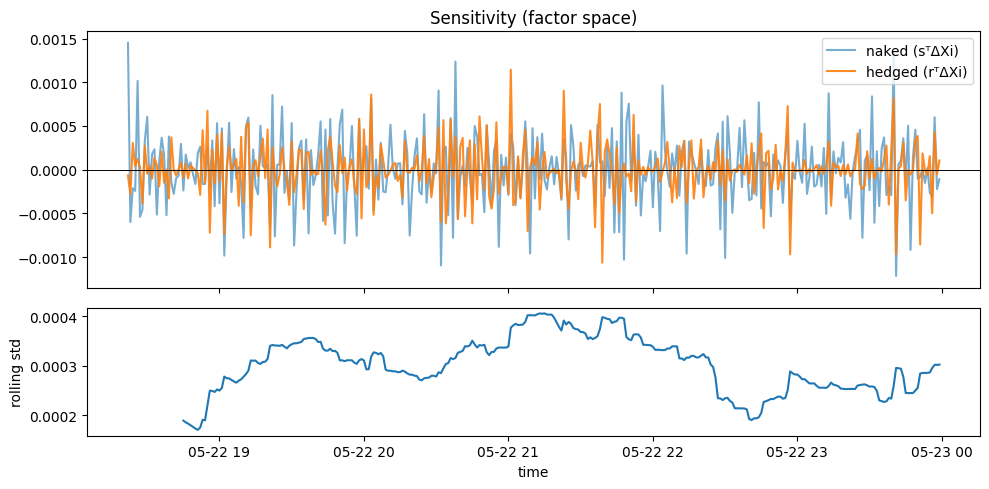

std naked=0.0004206 | std hedged=0.0003069 | variance reduction=46.8%


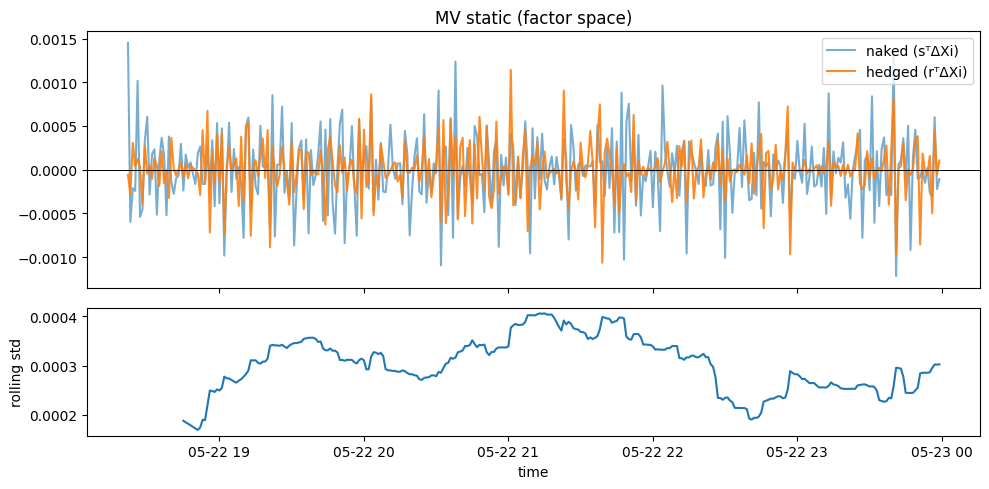

std naked=0.0004206 | std hedged=0.0003068 | variance reduction=46.8%


In [58]:
# --- Factor-space evaluation (Xi increments) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from neural_sde.loss import build_xi_training_data

def factor_space_vr(outs, w_nodes, hedge_cols, units, use_test=True, title=None):
    # 1) exposures in exact Xi order (dyn|stat|sa)
    G = np.vstack([
        outs.G_dyn,
        outs.G_stat,
        outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
                  else np.zeros((0, outs.C_test.shape[1]))
    ])
    s = G @ np.asarray(w_nodes, float)           # (p,)
    B = G[:, hedge_cols]                         # (p,k)

    # 2) Xi time series and increments (align to test/train split)
    _, X_te, names = build_xi_training_data(outs)
    X = X_te if use_test else build_xi_training_data(outs)[0]
    dXi = X[1:] - X[:-1]                         # (T-1,p)
    t = (outs.C_test.index if use_test else outs.C_train.index)[1:]

    # 3) units (static or dynamic) and residual exposure r = s - B u
    U = np.asarray(units, float)
    if U.ndim == 1:
        U = np.tile(U, (dXi.shape[0], 1))
    L = min(dXi.shape[0], U.shape[0])
    dXi = dXi[:L]; U = U[:L]; t = pd.to_datetime(t)[:L]

    # 4) “PnL” in factor space: target s^T dXi vs hedged residual r^T dXi
    pnl_naked = dXi @ s
    pnl_hedged = np.empty(L)
    for i in range(L):
        r = s - B @ U[i]
        pnl_hedged[i] = dXi[i] @ r

    vr = 1.0 - np.var(pnl_hedged)/max(np.var(pnl_naked), 1e-12)

    # 5) quick plot
    fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={"height_ratios":[2,1]})
    ax[0].plot(t, pnl_naked, label="naked (sᵀΔXi)", alpha=0.6)
    ax[0].plot(t, pnl_hedged, label="hedged (rᵀΔXi)", alpha=0.9)
    ax[0].axhline(0, color="k", lw=0.7); ax[0].legend()
    ax[0].set_title(title or "Factor-space hedge error")

    roll = pd.Series(pnl_hedged, index=t).rolling(48, min_periods=24).std()
    ax[1].plot(t, roll); ax[1].set_ylabel("rolling std"); ax[1].set_xlabel("time")
    plt.tight_layout(); plt.show()

    print(f"std naked={np.std(pnl_naked):.4g} | std hedged={np.std(pnl_hedged):.4g} | variance reduction={vr:.1%}")
    return pnl_hedged, pnl_naked, vr

_ = factor_space_vr(outs, w_nodes, hedge_cols, u_sens,     use_test=True, title="Sensitivity (factor space)")
_ = factor_space_vr(outs, w_nodes, hedge_cols, u_mv_static, use_test=True, title="MV static (factor space)")
# _ = factor_space_vr(outs, w_nodes, hedge_cols, u_mv_dyn,    use_test=True, title="MV dynamic (factor space)")


In [57]:
# Align test increments
import numpy as np, pandas as pd
from neural_sde.loss import build_xi_training_data

C = outs.C_test.values.astype(float)           # (T_c, N)
dC = C[1:] - C[:-1]                            # (T_c-1, N)
X_tr, X_te, _ = build_xi_training_data(outs)   # (T_x, p)
dXi = X_te[1:] - X_te[:-1]                     # (T_x-1, p)

L = min(dC.shape[0], dXi.shape[0])
dC  = dC[:L]; dXi = dXi[:L]

# Factor-implied price increments and residuals
G = np.vstack([outs.G_dyn, outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])          # (p,N)
dC_hat = dXi @ G                                                   # (L,N)
epsC   = dC - dC_hat

# Portfolio PnLs (naked, factor-only, residual-only)
pnl_naked   = dC @ w_nodes
pnl_factor  = dC_hat @ w_nodes
pnl_resid   = epsC @ w_nodes

print("Var decomposition (approx)")
print("var(naked)   :", np.var(pnl_naked))
print("var(factor)  :", np.var(pnl_factor))
print("var(residual):", np.var(pnl_resid))
print("corr(factor, residual):", np.corrcoef(pnl_factor, pnl_resid)[0,1])

# Hedged (use your units)
def hedged(dC_mat, U):
    U = np.tile(U, (dC_mat.shape[0],1)) if U.ndim==1 else U[:dC_mat.shape[0]]
    return (dC_mat @ w_nodes) - (dC_mat[:, hedge_cols] * U).sum(axis=1)

pnlH_naked   = hedged(dC, u_mv_static)
pnlH_factor  = hedged(dC_hat, u_mv_static)
pnlH_resid   = hedged(epsC, u_mv_static)

print("std hedged (total/factor/resid):",
      np.std(pnlH_naked), np.std(pnlH_factor), np.std(pnlH_resid))

Var decomposition (approx)
var(naked)   : 1.0697589206776184e-05
var(factor)  : 1.7691806551207212e-07
var(residual): 9.851784898648629e-06
corr(factor, residual): 0.2533253879960718
std hedged (total/factor/resid): 0.003429245900583606 0.0003067538958535876 0.00344065753741152


/Users/167011/Documents/GitHub/deribit_market_model/data_adapters/deribit_adapters.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['expiry'] = pd.to_datetime(df['expiry'])
/var/folders/7p/px6mp0t52794gwq4s0r9jst0ytvmtk/T/ipykernel_9661/661666639.py:67: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  spot_1m = spot_ts.resample("1T").median()


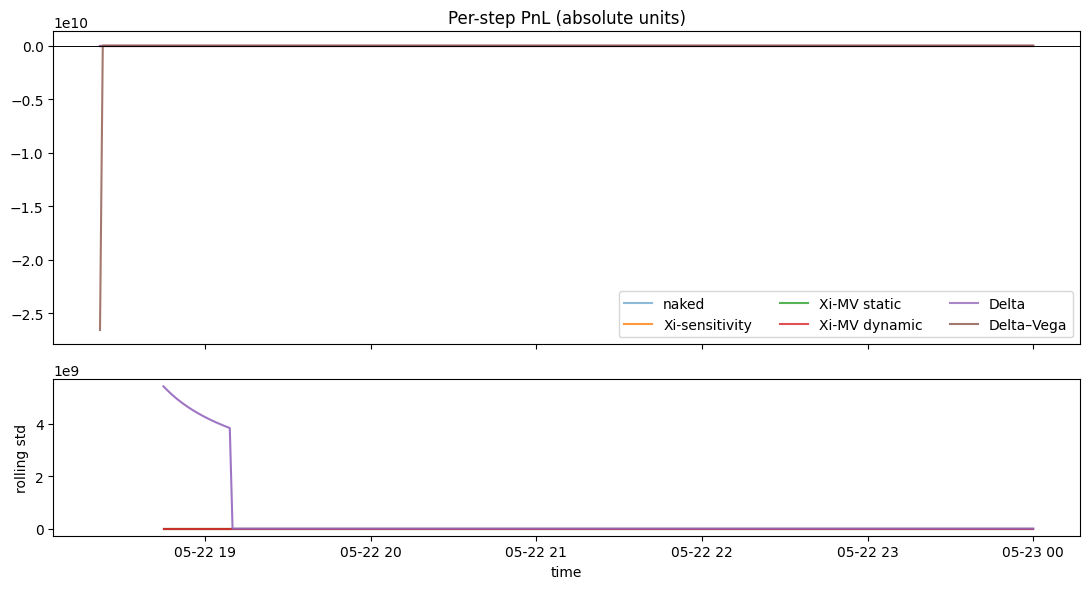

         hedge          std  variance_reduction
         Delta 3.519355e+02        9.705057e-02
  Xi-MV static 3.861499e+02       -8.704923e-02
 Xi-MV dynamic 3.862140e+02       -8.741009e-02
Xi-sensitivity 3.862653e+02       -8.769902e-02
    Delta–Vega 1.442082e+09       -1.516063e+13


In [49]:
# Compare Xi-hedges vs Delta and Delta–Vega hedges on the test panel
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import Sequence
from utils.black_scholes import implied_vol_from_c_norm, bs_vega_norm, _Phi  # [utils/black_scholes.py](utils/black_scholes.py)

# --- helpers ---------------------------------------------------------------

def pnl_options_abs(C_norm: np.ndarray, S: np.ndarray, w: np.ndarray):
    # absolute price pnl for an option basket: sum_i w_i * Δ (S*C_norm)_i
    C_abs = (S[:, None] * C_norm)
    dC_abs = C_abs[1:] - C_abs[:-1]
    return dC_abs @ w

def pnl_nodes_abs(C_norm: np.ndarray, S: np.ndarray, cols: Sequence[int], units_t: np.ndarray):
    # PnL of hedge instruments (options), units_t shape: (T-1, k)
    C_abs = (S[:, None] * C_norm)
    dC_abs = C_abs[1:] - C_abs[:-1]          # (T-1, N)
    return (dC_abs[:, cols] * units_t).sum(axis=1)

def greeks_per_node(C_norm: np.ndarray, nodes: np.ndarray, S: np.ndarray):
    # Vectorized BS greeks on the lattice (T x N):
    # - IV from normalized price,
    # - absolute delta = Phi(d1),
    # - absolute vega = S * bs_vega_norm
    T, N = C_norm.shape
    tau = nodes[:, 0]; m = nodes[:, 1]
    Tm = np.broadcast_to(tau[None, :], (T, N))
    Mm = np.broadcast_to(m[None, :],   (T, N))

    sig = implied_vol_from_c_norm(C_norm, Mm, Tm)              # (T,N)
    srt = np.sqrt(np.maximum(Tm, 0.0))
    sigsrt = np.maximum(sig * srt, 1e-12)
    d1 = (-Mm) / sigsrt + 0.5 * sigsrt
    delta_abs = _Phi(d1)                                       # (T,N)
    vega_abs  = (S[:, None] * bs_vega_norm(Mm, Tm, sig))       # (T,N)
    return sig, delta_abs, vega_abs

def plot_series(ts, label, ax, alpha=0.8):
    ax.plot(ts.index, ts.values, label=label, alpha=alpha)

# --- inputs from your pipeline / previous cells ----------------------------
# outs: Algo1Outputs from [pipeline/algo1.py](pipeline/algo1.py) or [pipeline/algo1_PCA.py](pipeline/algo1_PCA.py)
Cte = outs.C_test.values                            # (T, N), normalized prices
idx = outs.C_test.index
nodes = outs.nodes_sub                              # (N, 2) columns: [tau, m]



# spot aligned to the test panel timestamps (absolute units hedging needs this)
# If you already have spot series, pass it here; otherwise rebuild from your raw dataframe.
# Example (rebuild from the same raw df you used to create outs):
from data_adapters.deribit_adapters import clean_deribit, read_clean_jsonl
import os
data_path = 'data/json/deribit_options_2025-05-22.jsonl'
os.chdir('/Users/167011/Documents/GitHub/deribit_market_model')
df_raw= read_clean_jsonl(data_path)
df = clean_deribit(df_raw, reference_date="2025-01-30", r=0.0, q=0.0)

spot_ts = (df[['timestamp', 'underlying_price']]
           .assign(timestamp=pd.to_datetime(df['timestamp']))
           .dropna()
           .drop_duplicates('timestamp')
           .set_index('timestamp')
           .sort_index()['underlying_price'])

# 2) resample to 1-minute like the panel (see _spot_5m in pipeline: [pipeline/algo1_PCA.py](pipeline/algo1_PCA.py))
spot_1m = spot_ts.resample("1T").median()

# 3) align to idx and fill gaps
idx = pd.to_datetime(outs.C_test.index)  # panel index
spot_aligned = (spot_1m.reindex(idx)     # no KeyError: adds missing rows
                          .interpolate(method="time")
                          .ffill()
                          .bfill()
                          .astype(float)
                          .to_numpy())

# sanity
assert len(spot_aligned) == len(idx) and np.isfinite(spot_aligned).all()
spot = spot_aligned



# portfolio on the lattice (same w_nodes you used for Xi-hedging)
w_nodes = w_nodes.astype(float)                     # shape (N,)
hedge_cols = list(hedge_cols)                       # Xi-hedge option columns, e.g. [idx7d_atm, idx60d_atm]
U_sens     = u_sens                                 # (k,)
U_mv_stat  = u_mv_static                            # (k,)
U_mv_dyn   = u_mv_dyn                               # (T-1, k)

# pick one option node for the delta–vega hedge (e.g., the 30d ATM you used)
hed_opt_idx = hedge_cols[0]                         # change if you want a different vega hedge

# --- compute greeks and exposures -----------------------------------------
sig, delta_abs, vega_abs = greeks_per_node(Cte, nodes, spot)   # (T,N) each

# portfolio exposures per time
delta_P = (delta_abs * w_nodes[None, :]).sum(axis=1)           # (T,)
vega_P  = (vega_abs  * w_nodes[None, :]).sum(axis=1)           # (T,)

# hedge option greeks
delta_h = delta_abs[:, hed_opt_idx]                             # (T,)
vega_h  = vega_abs[:,  hed_opt_idx]                             # (T,)

# increments
S = spot.astype(float)
dS = S[1:] - S[:-1]                                             # (T-1,)
pnl_naked_abs = pnl_options_abs(Cte, S, w_nodes)                # (T-1,)

# --- Xi hedges (recomputed in absolute units for apples-to-apples) --------
def _align_units(units, L):
    """Return units with exactly L rows (broadcast/pad/trim/interp as needed)."""
    U = np.asarray(units, float)
    if U.ndim == 1:                     # static units -> broadcast
        return np.tile(U, (L, 1))
    if U.shape[0] == L:                 # already aligned
        return U
    if U.shape[0] == L - 1:             # missing last step -> repeat last row
        return np.vstack([U, U[-1:]])
    if U.shape[0] == L + 1:             # one extra -> drop last
        return U[:L]
    # generic fallback: linear interpolate in time
    t_old = np.linspace(0.0, 1.0, U.shape[0])
    t_new = np.linspace(0.0, 1.0, L)
    Ui = np.column_stack([np.interp(t_new, t_old, U[:, j]) for j in range(U.shape[1])])
    return Ui

def pnl_nodes_abs(C_norm, S, cols, units_t):
    C_abs = (S[:, None] * C_norm)
    dC_abs = C_abs[1:] - C_abs[:-1]             # (L, N)
    U = _align_units(units_t, dC_abs.shape[0])  # (L, k)
    return (dC_abs[:, cols] * U).sum(axis=1)

def xi_hedged_abs(C_norm, S, w, cols, units):
    C_abs = (S[:, None] * C_norm)
    dC_abs = C_abs[1:] - C_abs[:-1]
    pnl_naked = dC_abs @ np.asarray(w, float)
    U = _align_units(units, dC_abs.shape[0])
    pnl_h = (dC_abs[:, cols] * U).sum(axis=1)
    return pnl_naked - pnl_h

pnl_sens_abs   = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_sens)
pnl_mvstat_abs = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_mv_stat)
pnl_mvdyn_abs  = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_mv_dyn)

# --- Delta hedge (underlying only, dynamic) --------------------------------
uS_delta = delta_P[:-1].copy()                                  # units of S per step
pnl_delta_abs = pnl_naked_abs - uS_delta * dS                   # (T-1,)

# --- Delta–Vega hedge (underlying + one option, dynamic) -------------------
# Solve per step: [ [1, delta_h_t], [0, vega_h_t] ] [uS, uOpt]^T = [delta_P_t, vega_P_t]^T
uS_dv   = np.zeros_like(dS)
uOpt_dv = np.zeros_like(dS)
eps = 1e-12
for t in range(len(dS)):
    A = np.array([[1.0, delta_h[t]], [0.0, max(vega_h[t], eps)]], dtype=float)
    y = np.array([delta_P[t], vega_P[t]], dtype=float)
    x = np.linalg.solve(A, y)
    uS_dv[t], uOpt_dv[t] = x

# PnL of the hedge option and underlying
pnl_opt = (S[1:] * Cte[1:, hed_opt_idx] - S[:-1] * Cte[:-1, hed_opt_idx])
pnl_deltavega_abs = pnl_naked_abs - (uS_dv * dS + uOpt_dv * pnl_opt)

# --- plotting + summary ----------------------------------------------------
ts = pd.to_datetime(idx[1:])
series = {
    "naked":          pd.Series(pnl_naked_abs, index=ts),
    "Xi-sensitivity": pd.Series(pnl_sens_abs,   index=ts),
    "Xi-MV static":   pd.Series(pnl_mvstat_abs, index=ts),
    "Xi-MV dynamic":  pd.Series(pnl_mvdyn_abs,  index=ts),
    "Delta":          pd.Series(pnl_delta_abs,  index=ts),
    "Delta–Vega":     pd.Series(pnl_deltavega_abs, index=ts),
}

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios":[2,1]})
for k in ["naked","Xi-sensitivity","Xi-MV static","Xi-MV dynamic","Delta","Delta–Vega"]:
    plot_series(series[k], k, ax[0], alpha=0.8 if k!="naked" else 0.5)
ax[0].axhline(0, color="k", lw=0.7); ax[0].legend(ncol=3); ax[0].set_title("Per-step PnL (absolute units)")

roll = {k: s.rolling(48, min_periods=24).std() for k,s in series.items()}
for k in ["Xi-sensitivity","Xi-MV static","Xi-MV dynamic","Delta","Delta–Vega"]:
    plot_series(roll[k], f"roll std {k}", ax[1], alpha=0.9)
ax[1].set_ylabel("rolling std"); ax[1].set_xlabel("time"); plt.tight_layout(); plt.show()

def summarize(ref="naked"):
    base = series[ref].std()
    rows = []
    for k,s in series.items():
        if k==ref: continue
        rows.append((k, s.std(), 1.0 - (s.var()/series[ref].var())))
    return pd.DataFrame(rows, columns=["hedge","std","variance_reduction"]).sort_values("variance_reduction", ascending=False)

summary = summarize("naked")
print(summary.to_string(index=False))

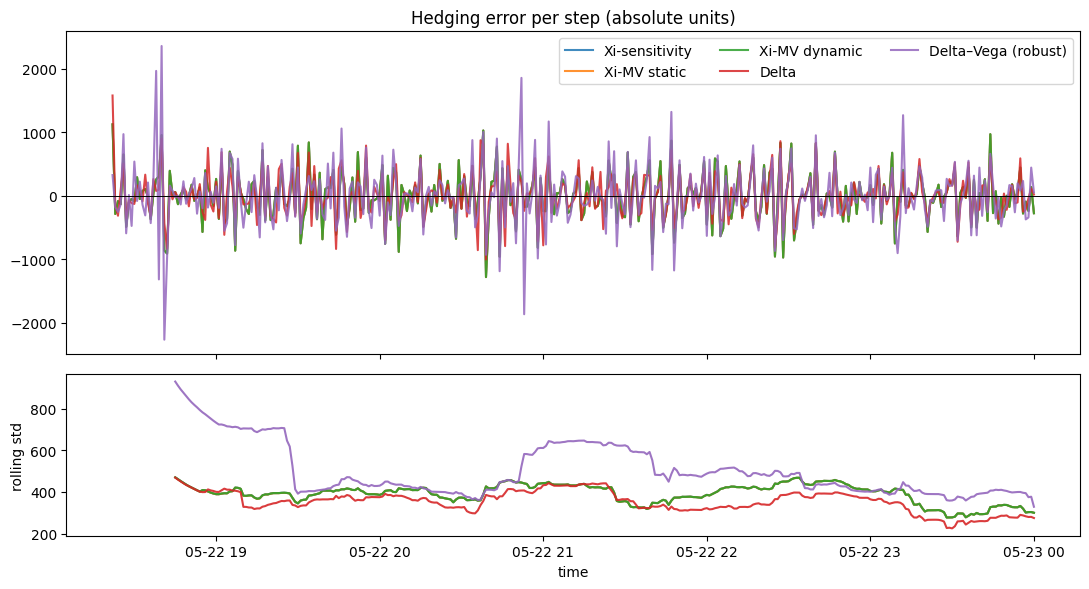

              hedge        std  variance_reduction
              Delta 351.935462            0.169854
       Xi-MV static 386.149897            0.000597
      Xi-MV dynamic 386.213985            0.000266
Delta–Vega (robust) 498.203605           -0.663575
Hedge option (fixed) vega stats @ idx 13 | min= 0.00015168692207950484 median= 3584.304342783518 1%= 3309.4523963349798


In [50]:
# Robust delta / delta–vega and hedging error chart (drop into your current cell 28)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils.black_scholes import implied_vol_from_c_norm, bs_vega_norm, _Phi  # [utils/black_scholes.py](utils/black_scholes.py)

# 0) Inputs already built above in your cell:
# Cte (T,N), idx (DatetimeIndex), nodes (N,2), spot (T,), w_nodes (N,),
# hedge_cols (list of node idx used for Xi hedges), U_sens, U_mv_stat, U_mv_dyn

# --- helpers already used in your cell ---
def _align_units(units, L):
    U = np.asarray(units, float)
    if U.ndim == 1: return np.tile(U, (L, 1))
    if U.shape[0] == L: return U
    if U.shape[0] == L - 1: return np.vstack([U, U[-1:]])
    if U.shape[0] == L + 1: return U[:L]
    t_old = np.linspace(0.0, 1.0, U.shape[0]); t_new = np.linspace(0.0, 1.0, L)
    return np.column_stack([np.interp(t_new, t_old, U[:, j]) for j in range(U.shape[1])])

def greeks_per_node(C_norm: np.ndarray, nodes: np.ndarray, S: np.ndarray):
    T, N = C_norm.shape
    tau = nodes[:, 0]; m = nodes[:, 1]
    Tm = np.broadcast_to(tau[None, :], (T, N))
    Mm = np.broadcast_to(m[None, :],   (T, N))
    sig = implied_vol_from_c_norm(C_norm, Mm, Tm)                 # (T,N)
    srt = np.sqrt(np.maximum(Tm, 0.0))
    sigsrt = np.maximum(sig * srt, 1e-12)
    d1 = (-Mm) / sigsrt + 0.5 * sigsrt
    delta_abs = _Phi(d1)                                          # (T,N)
    vega_abs  = (S[:, None] * bs_vega_norm(Mm, Tm, sig))          # (T,N)
    return sig, delta_abs, vega_abs

def pnl_options_abs(C_norm: np.ndarray, S: np.ndarray, w: np.ndarray):
    C_abs = (S[:, None] * C_norm); dC_abs = C_abs[1:] - C_abs[:-1]
    return dC_abs @ w

def xi_hedged_abs(C_norm, S, w, cols, units):
    C_abs = (S[:, None] * C_norm); dC_abs = C_abs[1:] - C_abs[:-1]
    U = _align_units(units, dC_abs.shape[0])
    return (dC_abs @ np.asarray(w, float)) - (dC_abs[:, cols] * U).sum(axis=1)

def summarize_series(series, ref="naked"):
    df = pd.DataFrame({k: pd.Series(v, index=series["t"]) for k, v in series.items() if k != "t"})
    base = df[ref].std()
    rows = [(k, df[k].std(), 1.0 - df[k].var()/df[ref].var()) for k in df.columns if k != ref]
    return pd.DataFrame(rows, columns=["hedge","std","variance_reduction"]).sort_values("variance_reduction", ascending=False)

# 1) Greeks and exposures
Cte = np.asarray(Cte, float); S = np.asarray(spot, float)
ts = pd.to_datetime(idx[1:])
sig, delta_abs, vega_abs = greeks_per_node(Cte, nodes, S)  # (T,N)

delta_P = (delta_abs * w_nodes[None, :]).sum(axis=1)       # (T,)
vega_P  = (vega_abs  * w_nodes[None, :]).sum(axis=1)       # (T,)

# 2) Xi hedges in absolute units (as you had)
pnl_naked_abs = pnl_options_abs(Cte, S, w_nodes)                                # (T-1,)
pnl_sens_abs   = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_sens)
pnl_mvstat_abs = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_mv_stat)
pnl_mvdyn_abs  = xi_hedged_abs(Cte, S, w_nodes, hedge_cols, U_mv_dyn)

# 3) Delta (underlying only)
dS = S[1:] - S[:-1]
uS_delta = delta_P[:-1]                                                         # (T-1,)
pnl_delta_abs = pnl_naked_abs - uS_delta * dS

# 4) Robust Delta–Vega
#    - choose a vega‑rich hedge option each step from a small universe (e.g., your ATM 7d and 30d)
#    - floor vega to avoid huge units when |vega_h| is tiny
hedge_universe = hedge_cols if isinstance(hedge_cols, (list, tuple)) else [hedge_cols]
vega_h_univ = vega_abs[:, hedge_universe]                                      # (T,k)
delta_h_univ = delta_abs[:, hedge_universe]                                    # (T,k)

# vega floor tied to the series scale (2% of median |vega| across the universe)
vega_floor = 0.02 * np.nanmedian(np.abs(vega_h_univ))
if not np.isfinite(vega_floor) or vega_floor <= 0: vega_floor = 1e-3

Tminus1 = len(ts)
uS_dv   = np.zeros(Tminus1)
uOpt_dv = np.zeros(Tminus1)
j_pick  = np.zeros(Tminus1, dtype=int)                                         # chosen hedge idx per step (in universe)

for t in range(Tminus1):
    # pick the most vega‑rich hedge at time t
    j_loc = int(np.argmax(np.abs(vega_h_univ[t])))
    v_h   = float(vega_h_univ[t, j_loc])
    d_h   = float(delta_h_univ[t, j_loc])

    if abs(v_h) < vega_floor or not np.isfinite(v_h):
        # fallback: delta only at this step
        uOpt = 0.0
        uS   = float(delta_P[t])
    else:
        uOpt = float(vega_P[t] / v_h)
        uS   = float(delta_P[t] - d_h * uOpt)
    uS_dv[t]   = uS
    uOpt_dv[t] = uOpt
    j_pick[t]  = j_loc

# PnL of the time‑varying hedge option
C_abs = (S[:, None] * Cte); dC_abs = C_abs[1:] - C_abs[:-1]                     # (T-1, N)
hedge_nodes = np.array(hedge_universe, dtype=int)
pnl_opt_dyn = dC_abs[np.arange(Tminus1), hedge_nodes[j_pick]] * uOpt_dv
pnl_deltavega_abs = pnl_naked_abs - (uS_dv * dS + pnl_opt_dyn)

# 5) Chart: hedging error only (per‑step PnL after hedge), plus rolling std
series = {
    "t": ts,
    "Xi-sensitivity": pnl_sens_abs,
    "Xi-MV static":   pnl_mvstat_abs,
    "Xi-MV dynamic":  pnl_mvdyn_abs,
    "Delta":          pnl_delta_abs,
    "Delta–Vega (robust)": pnl_deltavega_abs,
}

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios":[2,1]})
for k in ["Xi-sensitivity","Xi-MV static","Xi-MV dynamic","Delta","Delta–Vega (robust)"]:
    ax[0].plot(series["t"], series[k], label=k, alpha=0.85)
ax[0].axhline(0, color="k", lw=0.7)
ax[0].set_title("Hedging error per step (absolute units)")
ax[0].legend(ncol=3)

roll = {k: pd.Series(series[k], index=series["t"]).rolling(48, min_periods=24).std()
        for k in ["Xi-sensitivity","Xi-MV static","Xi-MV dynamic","Delta","Delta–Vega (robust)"]}
for k, s in roll.items():
    ax[1].plot(s.index, s.values, label=f"roll std {k}", alpha=0.9)
ax[1].set_ylabel("rolling std"); ax[1].set_xlabel("time")
plt.tight_layout(); plt.show()

print(summarize_series(series, ref="Xi-sensitivity").to_string(index=False))

# Diagnostics for why the original delta–vega blew up
hed_idx = hedge_cols[0]
print("Hedge option (fixed) vega stats @ idx", hed_idx,
      "| min=", np.nanmin(np.abs(vega_abs[:, hed_idx])),
      "median=", np.nanmedian(np.abs(vega_abs[:, hed_idx])),
      "1%=", np.nanpercentile(np.abs(vega_abs[:, hed_idx]), 1))
bad = np.where(np.abs(vega_abs[1:, hed_idx]) < vega_floor)[0]
if bad.size:
    print(f"{bad.size} steps had |vega_h| < floor={vega_floor:.4g} → delta‑only fallback recommended at those steps.")

In [51]:
# compute VR relative to the naked series (absolute price PnL)
import pandas as pd, numpy as np

ts = pd.to_datetime(idx[1:])
series = {
    "naked":          pd.Series(pnl_naked_abs,   index=ts),
    "Xi-sensitivity": pd.Series(pnl_sens_abs,    index=ts),
    "Xi-MV static":   pd.Series(pnl_mvstat_abs,  index=ts),
    "Xi-MV dynamic":  pd.Series(pnl_mvdyn_abs,   index=ts),
    "Delta":          pd.Series(pnl_delta_abs,   index=ts),
    "Delta–Vega":     pd.Series(pnl_deltavega_abs, index=ts),
}

def summarize_vs_naked(series):
    base = series["naked"].var()
    rows = []
    for k, s in series.items():
        if k == "naked": continue
        rows.append((k, s.std(), 1.0 - s.var()/base))
    return pd.DataFrame(rows, columns=["hedge","std","variance_reduction"]).sort_values("variance_reduction", ascending=False)

print(summarize_vs_naked(series).to_string(index=False))

         hedge        std  variance_reduction
         Delta 351.935462            0.097051
  Xi-MV static 386.149897           -0.087049
 Xi-MV dynamic 386.213985           -0.087410
Xi-sensitivity 386.265291           -0.087699
    Delta–Vega 498.203605           -0.809469


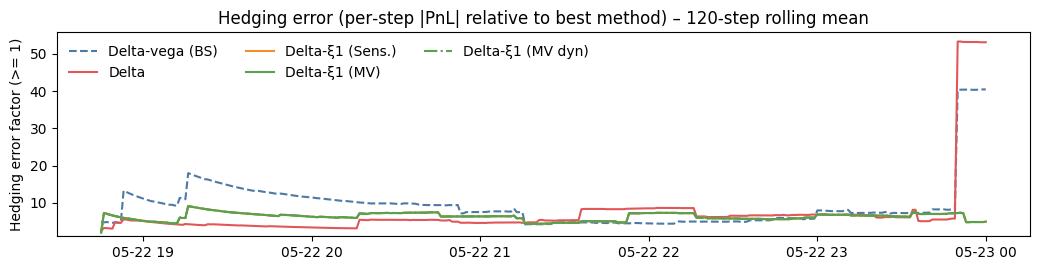

In [52]:
# Per‑step hedging error factor (>=1): |hedged PnL| divided by the best method at each step.
# Assumes you already built the per‑step hedged PnLs in absolute units:
#   pnl_sens_abs, pnl_mvstat_abs, pnl_mvdyn_abs, pnl_delta_abs, pnl_deltavega_abs
# and the time index ts = outs.C_test.index[1:].
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Collect the methods available in your workspace
methods_raw = {}
if 'pnl_deltavega_abs' in globals(): methods_raw['Delta‑vega (BS)'] = np.asarray(pnl_deltavega_abs, float)
if 'pnl_delta_abs'      in globals(): methods_raw['Delta']          = np.asarray(pnl_delta_abs, float)
if 'pnl_sens_abs'       in globals(): methods_raw['Delta‑ξ1 (Sens.)'] = np.asarray(pnl_sens_abs, float)
if 'pnl_mvstat_abs'     in globals(): methods_raw['Delta‑ξ1 (MV)']    = np.asarray(pnl_mvstat_abs, float)
if 'pnl_mvdyn_abs'      in globals(): methods_raw['Delta‑ξ1 (MV dyn)']= np.asarray(pnl_mvdyn_abs, float)

assert len(methods_raw) >= 2, "Need at least two hedging methods' PnL series."

# 2) Align to common length and time index
ts_all = pd.to_datetime(outs.C_test.index[1:])
L = min(len(v) for v in methods_raw.values())
ts = ts_all[:L]
methods_abs = {k: np.abs(v[:L]) for k, v in methods_raw.items()}  # absolute hedging PnL per step

# 3) Build hedging error factor (>=1) against the stepwise best
eps = 1e-12
stack = np.column_stack([methods_abs[k] for k in methods_abs])          # (L, K)
best = np.maximum(stack.min(axis=1), eps)                               # (L,)
err_factor = {k: (methods_abs[k] / best) for k in methods_abs}          # each >= 1

# Optional smoothing (rolling mean over w steps). Set w=None to disable.
w = 120  # e.g., 2 hours if data are 1‑minute bars
if w is not None and w > 1:
    err_factor = {k: pd.Series(v, index=ts).rolling(w, min_periods=max(5, w//5)).mean().to_numpy()
                  for k, v in err_factor.items()}

# 4) Plot
plot_order = [name for name in ['Delta‑vega (BS)', 'Delta', 'Delta‑ξ1 (Sens.)', 'Delta‑ξ1 (MV)', 'Delta‑ξ1 (MV dyn)']
              if name in err_factor]

styles = {
    'Delta‑vega (BS)':  dict(ls='--', color='#4e79a7'),
    'Delta':            dict(ls='-',  color='#e15759'),
    'Delta‑ξ1 (Sens.)': dict(ls='-',  color='#f28e2b'),
    'Delta‑ξ1 (MV)':    dict(ls='-',  color='#59a14f'),
    'Delta‑ξ1 (MV dyn)':dict(ls='-.', color='#59a14f'),
}

plt.figure(figsize=(10.5, 2.8))
for name in plot_order:
    y = err_factor[name]
    plt.plot(ts, y, label=name, **styles.get(name, {}))
plt.axhline(1.0, color='k', lw=0.8, alpha=0.7)
plt.ylabel('Hedging error factor (>= 1)')
title = "Hedging error (per‑step |PnL| relative to best method)"
if w and w > 1: title += f" – {w}-step rolling mean"
plt.title(title)
# y‑limits: keep baseline at 1 and add a small headroom
finite_vals = np.hstack([v[np.isfinite(v)] for v in err_factor.values()])
ymax = float(np.nanquantile(finite_vals, 0.995)) if finite_vals.size else 1.1
plt.ylim(1.0, max(1.05, ymax*1.05))
plt.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

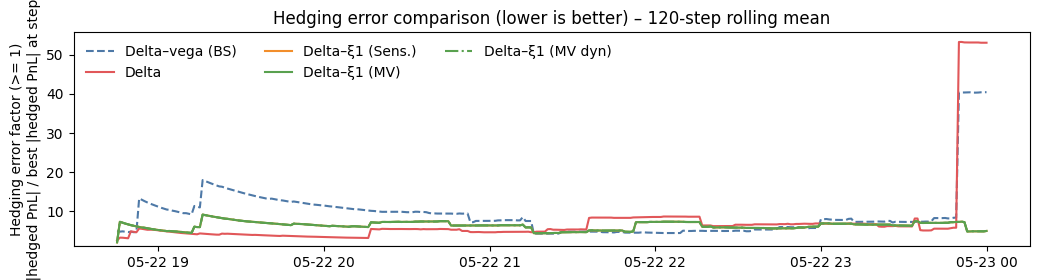

In [53]:
# Hedging error factor (>=1) vs time for all methods
# Requires the per-step hedged PnL series built earlier:
#   pnl_sens_abs, pnl_mvstat_abs, pnl_mvdyn_abs, pnl_delta_abs, pnl_deltavega_abs
# and the test timestamp index outs.C_test.index

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Collect whatever methods are available in the workspace
methods = {}
if 'pnl_sens_abs'       in globals(): methods['Delta–ξ1 (Sens.)']  = np.asarray(pnl_sens_abs, float)
if 'pnl_mvstat_abs'     in globals(): methods['Delta–ξ1 (MV)']     = np.asarray(pnl_mvstat_abs, float)
if 'pnl_mvdyn_abs'      in globals(): methods['Delta–ξ1 (MV dyn)'] = np.asarray(pnl_mvdyn_abs, float)
if 'pnl_delta_abs'      in globals(): methods['Delta']             = np.asarray(pnl_delta_abs, float)
if 'pnl_deltavega_abs'  in globals(): methods['Delta–vega (BS)']   = np.asarray(pnl_deltavega_abs, float)

assert len(methods) >= 2, "Need at least two hedging methods' PnL series."

# 2) Align to common length and time index (use test panel timestamps t+1)
ts_all = pd.to_datetime(outs.C_test.index[1:])
L = min(len(v) for v in methods.values())
ts = ts_all[:L]
abs_errors = {name: np.abs(v[:L]) for name, v in methods.items()}   # absolute hedging error per step

# 3) Hedging error factor >= 1: divide by the stepwise best absolute error
stack = np.column_stack([abs_errors[k] for k in abs_errors])        # (L, K)
best  = np.maximum(stack.min(axis=1), 1e-12)                        # avoid 0 division
err_factor = {k: (abs_errors[k] / best) for k in abs_errors}        # each >= 1

# Optional smoothing for readability (rolling mean over w steps)
w = 120  # e.g., 2 hours if data frequency is 1-minute; set to None/0 to disable
if w and w > 1:
    err_factor_sm = {k: pd.Series(v, index=ts).rolling(w, min_periods=max(5, w//5)).mean() for k, v in err_factor.items()}
else:
    err_factor_sm = {k: pd.Series(v, index=ts) for k, v in err_factor.items()}

# 4) Plot
plot_order = [name for name in ['Delta–vega (BS)', 'Delta', 'Delta–ξ1 (Sens.)', 'Delta–ξ1 (MV)', 'Delta–ξ1 (MV dyn)'] if name in err_factor_sm]
styles = {
    'Delta–vega (BS)':  dict(ls='--', color='#4e79a7'),
    'Delta':            dict(ls='-',  color='#e15759'),
    'Delta–ξ1 (Sens.)': dict(ls='-',  color='#f28e2b'),
    'Delta–ξ1 (MV)':    dict(ls='-',  color='#59a14f'),
    'Delta–ξ1 (MV dyn)':dict(ls='-.', color='#59a14f'),
}

plt.figure(figsize=(10.5, 2.9))
for name in plot_order:
    plt.plot(err_factor_sm[name].index, err_factor_sm[name].values, label=name, **styles.get(name, {}))
plt.axhline(1.0, color='k', lw=0.8, alpha=0.7)
plt.ylabel('Hedging error factor (>= 1)\n(|hedged PnL| / best |hedged PnL| at step)')
title = "Hedging error comparison (lower is better)"
if w and w > 1: title += f" – {w}-step rolling mean"
plt.title(title)
finite_vals = np.hstack([s.values[np.isfinite(s.values)] for s in err_factor_sm.values()])
ymax = float(np.nanquantile(finite_vals, 0.995)) if finite_vals.size else 1.1
plt.ylim(1.0, max(1.05, ymax*1.05))
plt.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

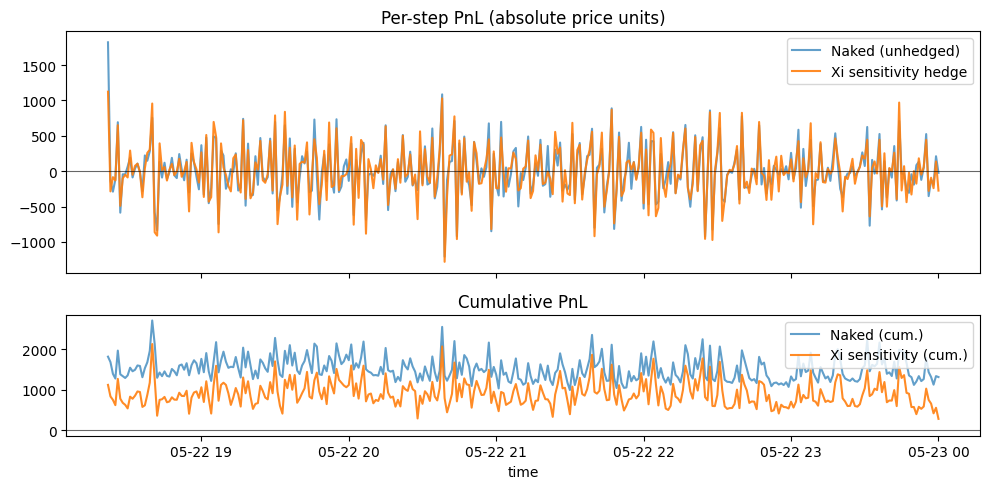

Std per-step PnL  | naked=369.820  sens=385.695
Variance reduction vs naked: -8.8%


In [54]:
# --- PnL time series: Naked vs Xi sensitivity hedge (absolute price units) ---

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Inputs expected from earlier cells:
# outs, w_nodes (N,), hedge_cols (list of node indices), u_sens (k,), and spot (aligned to C_test.index)
C_norm = outs.C_test.values.astype(float)                 # (T, N)
ts = pd.to_datetime(outs.C_test.index)[1:]                # timestamps for Δ step
N = C_norm.shape[1]

# If spot not built earlier, fall back to normalized units
if 'spot' in globals():
    S = np.asarray(spot, float)
else:
    S = np.ones(C_norm.shape[0], float)                   # normalized fallback

# Helpers
def _align_units(units, L):
    U = np.asarray(units, float)
    return np.tile(U, (L, 1)) if U.ndim == 1 else U[:L]

# Absolute price increments per node
C_abs  = S[:, None] * C_norm                              # (T, N)
dC_abs = C_abs[1:] - C_abs[:-1]                           # (T-1, N)
L = dC_abs.shape[0]

# Naked PnL (unhedged naive portfolio)
w = np.asarray(w_nodes, float).reshape(N)
pnl_naked = dC_abs @ w                                    # (L,)

# Xi sensitivity hedge PnL
U_sens = _align_units(u_sens, L)                          # (L, k)
pnl_hedge_leg = (dC_abs[:, hedge_cols] * U_sens).sum(axis=1)
pnl_sens = pnl_naked - pnl_hedge_leg                      # (L,)

# Plot per-step PnL and cumulative PnL
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={"height_ratios":[2,1]})

# Per-step
ax[0].plot(ts, pnl_naked, label="Naked (unhedged)", alpha=0.70)
ax[0].plot(ts, pnl_sens,  label="Xi sensitivity hedge", alpha=0.90)
ax[0].axhline(0, color="k", lw=0.8, alpha=0.6)
ax[0].set_title("Per-step PnL (absolute price units)")
ax[0].legend()

# Cumulative
ax[1].plot(ts, np.cumsum(pnl_naked), label="Naked (cum.)", alpha=0.70)
ax[1].plot(ts, np.cumsum(pnl_sens),  label="Xi sensitivity (cum.)", alpha=0.90)
ax[1].axhline(0, color="k", lw=0.8, alpha=0.6)
ax[1].set_title("Cumulative PnL")
ax[1].set_xlabel("time"); ax[1].legend()

plt.tight_layout(); plt.show()

# Quick summary
print(f"Std per-step PnL  | naked={np.std(pnl_naked):.3f}  sens={np.std(pnl_sens):.3f}")
print(f"Variance reduction vs naked: {1.0 - np.var(pnl_sens)/max(np.var(pnl_naked),1e-12):.1%}")

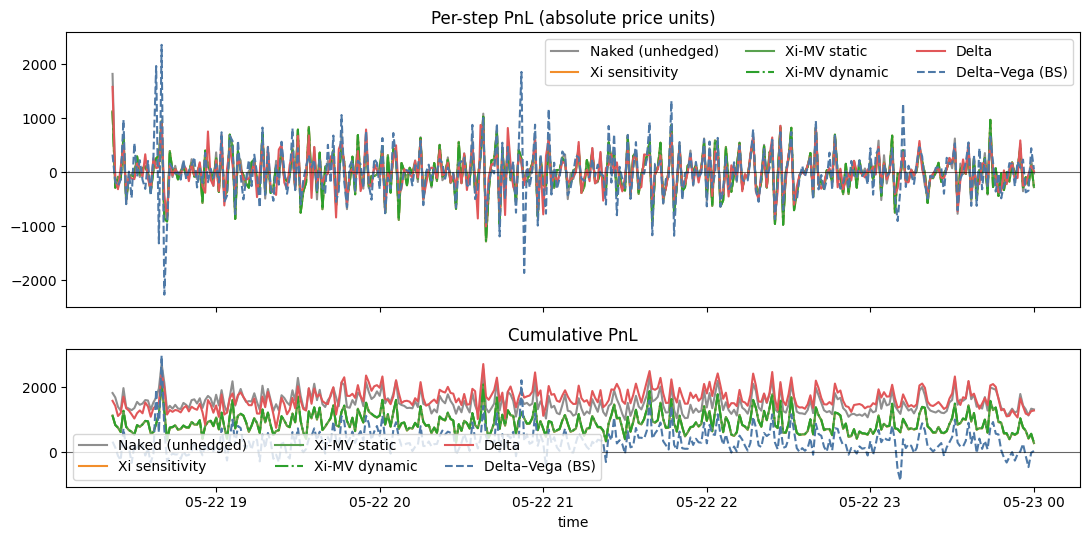

,hedge,std,variance_reduction
3,Delta,351.416000,0.097051
1,Xi-MV static,385.579934,-0.087049
2,Xi-MV dynamic,385.643927,-0.087410
0,Xi sensitivity,385.695158,-0.087699
4,Delta–Vega (BS),497.468248,-0.809469


In [55]:
# Extend the same plot with all other hedging techniques (per-step and cumulative)

# Reuse objects from your cell: C_norm, S, dC_abs, L, ts, w, hedge_cols, _align_units,
# and already-built series if available (pnl_mvstat_abs, pnl_mvdyn_abs, pnl_delta_abs, pnl_deltavega_abs)

# ... replace your _align_units with this robust version ...
import numpy as np

def _align_units(units, L):
    """
    Return units with exactly L rows.
    - 1D -> broadcast
    - if rows == L-1 -> pad by repeating last row
    - if rows == L+1 -> drop last row
    - else -> time-wise linear interpolation to L rows
    """
    U = np.asarray(units, float)
    if U.ndim == 1:
        return np.tile(U, (L, 1))
    if U.shape[0] == L:
        return U
    if U.shape[0] == L - 1:
        return np.vstack([U, U[-1:]])
    if U.shape[0] == L + 1:
        return U[:L]
    # generic interpolate each column to L rows
    t_old = np.linspace(0.0, 1.0, U.shape[0])
    t_new = np.linspace(0.0, 1.0, L)
    return np.column_stack([np.interp(t_new, t_old, U[:, j]) for j in range(U.shape[1])])

series = {
    "Naked (unhedged)": pnl_naked,
    "Xi sensitivity":   pnl_sens,
}

# Xi-MV static
if 'u_mv_static' in globals():
    U_mvst = _align_units(u_mv_static, L)
    pnl_mvst = (dC_abs @ w) - (dC_abs[:, hedge_cols] * U_mvst).sum(axis=1)
    series["Xi-MV static"] = pnl_mvst

# Xi-MV dynamic
if 'u_mv_dyn' in globals():
    U_mvdn = _align_units(u_mv_dyn, L)
    pnl_mvdn = (dC_abs @ w) - (dC_abs[:, hedge_cols] * U_mvdn).sum(axis=1)
    series["Xi-MV dynamic"] = pnl_mvdn

# Delta (prefer existing series; else compute on the fly if delta_P/dS are available)
try:
    if 'pnl_delta_abs' in globals():
        series["Delta"] = np.asarray(pnl_delta_abs, float)[:L]
    elif 'delta_P' in globals() and 'spot' in globals():
        dS = np.asarray(spot, float)[1:] - np.asarray(spot, float)[:-1]
        series["Delta"] = (dC_abs @ w) - (np.asarray(delta_P[:-1], float)[:L] * dS[:L])
except Exception as e:
    print(f"[info] skipping Delta: {e}")

# Delta–Vega (prefer robust series if available)
if 'pnl_deltavega_abs' in globals():
    series["Delta–Vega (BS)"] = np.asarray(pnl_deltavega_abs, float)[:L]

# Plot
styles = {
    "Naked (unhedged)": dict(color="#444444", alpha=0.6),
    "Xi sensitivity":   dict(color="#f28e2b"),
    "Xi-MV static":     dict(color="#59a14f"),
    "Xi-MV dynamic":    dict(color="#2ca02c", linestyle="-."),
    "Delta":            dict(color="#e15759"),
    "Delta–Vega (BS)":  dict(color="#4e79a7", linestyle="--"),
}

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, gridspec_kw={"height_ratios":[2,1]})

# Per-step PnL
for name, y in series.items():
    ax[0].plot(ts, np.asarray(y, float)[:L], label=name, **styles.get(name, {}))
ax[0].axhline(0, color="k", lw=0.8, alpha=0.6)
ax[0].set_title("Per-step PnL (absolute price units)")
ax[0].legend(ncol=3)

# Cumulative PnL
for name, y in series.items():
    ax[1].plot(ts, np.cumsum(np.asarray(y, float)[:L]), label=name, **styles.get(name, {}))
ax[1].axhline(0, color="k", lw=0.8, alpha=0.6)
ax[1].set_title("Cumulative PnL")
ax[1].set_xlabel("time")
ax[1].legend(ncol=3)

plt.tight_layout(); plt.show()

# Summary vs naked
base = np.var(series["Naked (unhedged)"])
rows = []
for name, y in series.items():
    if name == "Naked (unhedged)": continue
    yv = np.asarray(y, float)[:L]
    rows.append((name, float(np.std(yv)), float(1.0 - np.var(yv)/max(base, 1e-12))))
pd.DataFrame(rows, columns=["hedge","std","variance_reduction"]).sort_values("variance_reduction", ascending=False)

In [43]:
import numpy as np, pandas as pd

# 1) indices and consistency
C_norm = outs.C_test.values.astype(float)
S = np.asarray(spot, float) if 'spot' in globals() else np.ones(C_norm.shape[0])
dC_norm = C_norm[1:] - C_norm[:-1]
dC_abs  = (S[:,None]*C_norm)[1:] - (S[:,None]*C_norm)[:-1]
L = min(dC_norm.shape[0], dC_abs.shape[0])
dC_norm = dC_norm[:L]; dC_abs = dC_abs[:L]

print("portfolio node:", int(np.argmax(w_nodes)))
print("hedge_cols:", hedge_cols, " (portfolio node in hedges? ->", int(np.argmax(w_nodes)) in set(hedge_cols), ")")

# 2) recompute Xi-sensitivity units (static) AFTER confirming w_nodes/hedge_cols
G = np.vstack([outs.G_dyn, outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])
s = G @ np.asarray(w_nodes, float)
B = G[:, hedge_cols]
u_sens_chk, *_ = np.linalg.lstsq(B, s, rcond=None)
print("u_sens (recomputed) =", u_sens_chk)

# 3) normalized vs absolute VR: should be (almost) the same
def vr_norm_abs(dC_norm, dC_abs, w, cols, u):
    U = np.tile(u, (dC_norm.shape[0],1))
    pnl_naked_norm = dC_norm @ w
    pnl_hedge_norm = pnl_naked_norm - (dC_norm[:, cols] * U).sum(axis=1)
    vr_norm = 1 - np.var(pnl_hedge_norm)/max(np.var(pnl_naked_norm), 1e-12)

    pnl_naked_abs = dC_abs @ w
    pnl_hedge_abs = pnl_naked_abs - (dC_abs[:, cols] * U).sum(axis=1)
    vr_abs = 1 - np.var(pnl_hedge_abs)/max(np.var(pnl_naked_abs), 1e-12)
    return vr_norm, vr_abs

vrN, vrA = vr_norm_abs(dC_norm, dC_abs, np.asarray(w_nodes,float), hedge_cols, u_sens_chk)
print(f"VR normalized units: {vrN:.2%} | VR absolute units: {vrA:.2%}")

portfolio node: 26
hedge_cols: [26, 34]  (portfolio node in hedges? -> True )
u_sens (recomputed) = [ 1.00000000e+00 -1.28780594e-17]
VR normalized units: 100.00% | VR absolute units: 100.00%


Portfolio node: 26
Hedge nodes used: [13, 34]
u_sens (len=2): [0.79849797 0.02695796]
Variance reduction (absolute): -8.77%


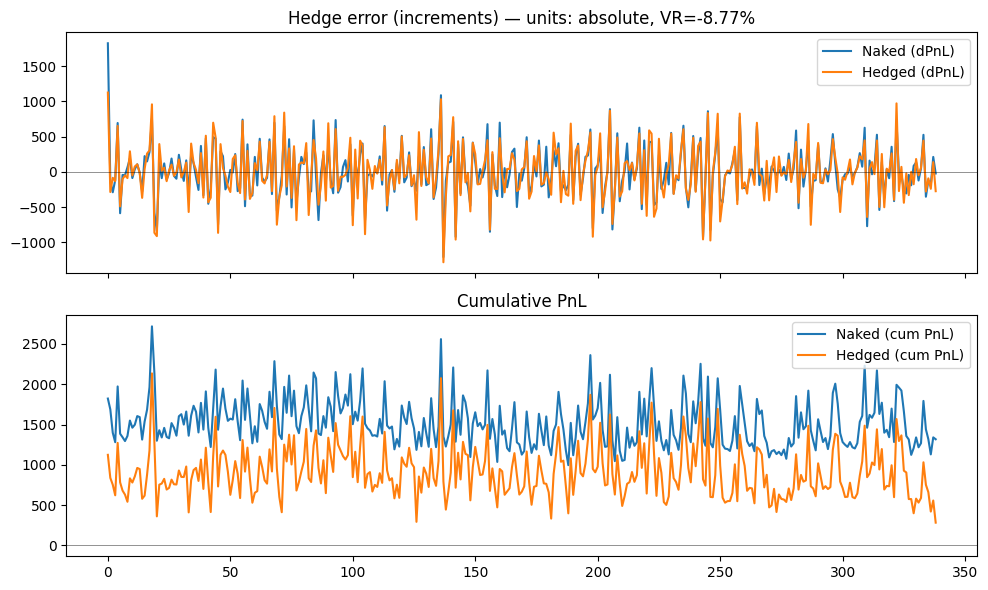

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---
use_absolute = True  # True -> dollar PnL (needs spot series); False -> normalized PnL
rolling = None       # e.g., set to 50 for a 50-step rolling mean overlay; or None

# --- Inputs expected in the notebook environment ---
# outs.C_test: T x N normalized price grid
# outs.G_dyn, outs.G_stat, (optional) outs.G_sa: sensitivity blocks
# w_nodes: length-N portfolio weights (e.g., one-hot at the chosen node)
# hedge_cols: list of node indices to use as hedges
# spot (or S): length-T spot series if use_absolute=True

# --- Safety checks and helpers ---
def get_spot_series():
    for name in ("spot", "S", "spot_series", "S_t"):
        if name in globals():
            s = np.asarray(globals()[name], float).ravel()
            return s
    return None

def stack_G(outs):
    blocks = []
    for name in ("G_dyn", "G_stat", "G_sa"):
        if hasattr(outs, name):
            G = getattr(outs, name)
            if G is not None and np.size(G) > 0:
                blocks.append(np.asarray(G, float))
    if not blocks:
        raise ValueError("No sensitivity blocks found on 'outs' (need G_dyn/G_stat/...).")
    return np.vstack(blocks)

# --- Build data matrices ---
C = np.asarray(outs.C_test, float)  # T x N
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
assert w.shape[0] == N, "w_nodes length must match number of columns in C_test"

# Avoid self-hedging
p_idx = int(np.argmax(w))
orig_hedges = list(hedge_cols)
hedge_cols = [c for c in hedge_cols if c != p_idx]
removed_self = set(orig_hedges) - set(hedge_cols)

# Compute sensitivity hedge u_sens solving B u = s
G = stack_G(outs)
s = G @ w
if len(hedge_cols) > 0:
    B = G[:, hedge_cols]
    u_sens, *_ = np.linalg.lstsq(B, s, rcond=None)
else:
    u_sens = np.zeros(0)

# Choose units and build increments
units = "absolute" if use_absolute else "normalized"
if use_absolute:
    spot_series = get_spot_series()
    if spot_series is None or len(spot_series) < T:
        print("No valid spot series found or wrong length; falling back to normalized units.")
        use_absolute = False
        units = "normalized"

if use_absolute:
    C_units = (spot_series[:T, None] * C)
else:
    C_units = C

dC = np.diff(C_units, axis=0)  # (T-1) x N
L = dC.shape[0]

# Naked and hedged PnL increments
pnl_naked = dC @ w
if len(hedge_cols) > 0:
    U = np.tile(u_sens, (L, 1))
    hedge_incr = (dC[:, hedge_cols] * U).sum(axis=1)
    pnl_hedged = pnl_naked - hedge_incr
else:
    pnl_hedged = pnl_naked.copy()

# Variance reduction
var_naked = np.nanvar(pnl_naked)
var_hedged = np.nanvar(pnl_hedged)
vr = 1 - var_hedged / max(var_naked, 1e-12)

# Optional rolling smoothing for plotting
def maybe_roll(x, w=None):
    if not w or w <= 1:
        return x
    s = pd.Series(x)
    return s.rolling(w, min_periods=max(1, w//5), center=False).mean().to_numpy()

pnl_naked_plot  = maybe_roll(pnl_naked, rolling)
pnl_hedged_plot = maybe_roll(pnl_hedged, rolling)
cum_naked  = np.nancumsum(pnl_naked)
cum_hedged = np.nancumsum(pnl_hedged)

# --- Output ---
print(f"Portfolio node: {p_idx}")
if removed_self:
    print(f"Removed self-hedge nodes from hedge_cols: {sorted(removed_self)}")
print(f"Hedge nodes used: {hedge_cols}")
print(f"u_sens (len={len(u_sens)}): {u_sens}")
print(f"Variance reduction ({units}): {vr:.2%}")

# --- Plots ---
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(pnl_naked_plot, label="Naked (dPnL)")
axs[0].plot(pnl_hedged_plot, label="Hedged (dPnL)")
axs[0].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[0].set_title(f"Hedge error (increments) — units: {units}, VR={vr:.2%}")
axs[0].legend(loc="best")

axs[1].plot(cum_naked, label="Naked (cum PnL)")
axs[1].plot(cum_hedged, label="Hedged (cum PnL)")
axs[1].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[1].set_title("Cumulative PnL")
axs[1].legend(loc="best")

plt.tight_layout()
plt.show()

In [61]:
import numpy as np
import pandas as pd

use_absolute = True  # toggle units
ridge = 1e-4         # ridge for stability in var-opt and hybrid
expo_weight = 10.0   # penalty weight for exposure mismatch in hybrid (0 = pure var-opt)

def stack_G(outs):
    blocks = []
    for name in ("G_dyn","G_stat","G_sa"):
        if hasattr(outs,name):
            G = getattr(outs,name)
            if G is not None and np.size(G)>0:
                blocks.append(np.asarray(G,float))
    return np.vstack(blocks)

def get_spot_series():
    for name in ("spot","S","spot_series","S_t"):
        if name in globals():
            return np.asarray(globals()[name], float).ravel()
    return None

# Inputs
C = np.asarray(outs.C_test, float)  # T x N
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))
hedges = [c for c in hedge_cols if c != p_idx]  # avoid self-hedge

# Units
if use_absolute:
    S = get_spot_series()
    if S is None or len(S) < T:
        print("No valid spot series found; falling back to normalized units.")
        use_absolute = False
C_units = (S[:T,None]*C) if use_absolute else C
dC = np.diff(C_units, axis=0)  # (T-1) x N

# Series
y = dC @ w                     # naked dPnL
H = dC[:, hedges] if hedges else np.zeros((dC.shape[0],0))

# 1) Sensitivity hedge (matches exposures, ignores variance)
G = stack_G(outs)
s = G @ w
if hedges:
    B = G[:, hedges]
    # diagnostics on exposure system
    expo_resid = B @ np.linalg.lstsq(B, s, rcond=None)[0] - s
    cond_B = np.linalg.cond(B) if B.shape[0] >= B.shape[1] and B.shape[1]>0 else np.inf
    u_sens = np.linalg.lstsq(B, s, rcond=None)[0]
else:
    B = np.zeros((G.shape[0],0))
    expo_resid = -s
    cond_B = np.inf
    u_sens = np.zeros(0)

# 2) Variance-optimal hedge (min Var(y - H u))
if hedges:
    HH = H.T @ H + ridge * np.eye(H.shape[1])
    Hy = H.T @ y
    u_var = np.linalg.solve(HH, Hy)
else:
    u_var = np.zeros(0)

# 3) Hybrid: minimize ||y - H u||^2 + expo_weight * ||B u - s||^2 + ridge||u||^2
if hedges:
    A = H.T @ H + expo_weight * (B.T @ B) + ridge * np.eye(H.shape[1])
    b = H.T @ y + expo_weight * (B.T @ s)
    u_hybrid = np.linalg.solve(A, b)
else:
    u_hybrid = np.zeros(0)

def pnl_and_vr(u):
    if u.size == 0:
        pnl = y.copy()
    else:
        pnl = y - H @ u
    var_naked = np.var(y)
    var_hedge = np.var(pnl)
    vr = 1 - var_hedge / max(var_naked, 1e-12)
    return pnl, vr

pnl_sens,   vr_sens   = pnl_and_vr(u_sens)
pnl_var,    vr_var    = pnl_and_vr(u_var)
pnl_hybrid, vr_hybrid = pnl_and_vr(u_hybrid)

# Correlations and leverage diagnostics
corrs = {} if not hedges else {c: np.corrcoef(y, H[:,i])[0,1] for i,c in enumerate(hedges)}
leverage = {
    "sens_L1": float(np.sum(np.abs(u_sens))) if u_sens.size else 0.0,
    "var_L1": float(np.sum(np.abs(u_var))) if u_var.size else 0.0,
    "hyb_L1": float(np.sum(np.abs(u_hybrid))) if u_hybrid.size else 0.0,
}

print(f"Portfolio node: {p_idx}, hedges: {hedges}")
print(f"Exposure system cond(B): {cond_B:.2e}, exposure residual norm: {np.linalg.norm(expo_resid):.3g}")
print("Per-hedge corr with naked dPnL:", {int(k): float(v) for k,v in corrs.items()})
print("Hedge leverage (L1):", leverage)
print(f"VR sensitivity: {vr_sens:.2%}")
print(f"VR variance-opt: {vr_var:.2%}  (ridge={ridge})")
print(f"VR hybrid:       {vr_hybrid:.2%}  (expo_weight={expo_weight}, ridge={ridge})")

Portfolio node: 26, hedges: [13, 34]
Exposure system cond(B): 2.23e+00, exposure residual norm: 0.0127
Per-hedge corr with naked dPnL: {13: 0.08859100519697809, 34: -0.13194176948778089}
Hedge leverage (L1): {'sens_L1': 0.8254559305969313, 'var_L1': 0.2895121211835632, 'hyb_L1': 0.28951213896905315}
VR sensitivity: -8.77%
VR variance-opt: 2.62%  (ridge=0.0001)
VR hybrid:       2.62%  (expo_weight=10.0, ridge=0.0001)


In [62]:
# Rolling variance-opt hedge (re-estimate weights on a trailing window)
W = 100          # window length
ridge = 1e-4
y = dC @ w
H = dC[:, hedges] if hedges else np.zeros((dC.shape[0],0))

pnl_roll = np.full(y.shape, np.nan)
if H.shape[1] > 0:
    for t in range(W, len(y)):
        Hw = H[t-W:t]
        yw = y[t-W:t]
        A = Hw.T @ Hw + ridge * np.eye(H.shape[1])
        b = Hw.T @ yw
        u_t = np.linalg.solve(A, b)
        pnl_roll[t] = y[t] - H[t] @ u_t
else:
    pnl_roll[W:] = y[W:]

vr_roll = 1 - np.nanvar(pnl_roll[W:]) / max(np.nanvar(y[W:]), 1e-12)
print(f"Variance reduction (rolling var-opt, W={W}): {vr_roll:.2%}")

Variance reduction (rolling var-opt, W=100): 0.43%


Portfolio node: 26
Hedge nodes (no self-hedge): [13, 34]
VR sensitivity: -8.77%
VR variance-opt (static): 2.62%  (ridge=0.0001)
VR variance-opt (rolling W=100): 0.43%


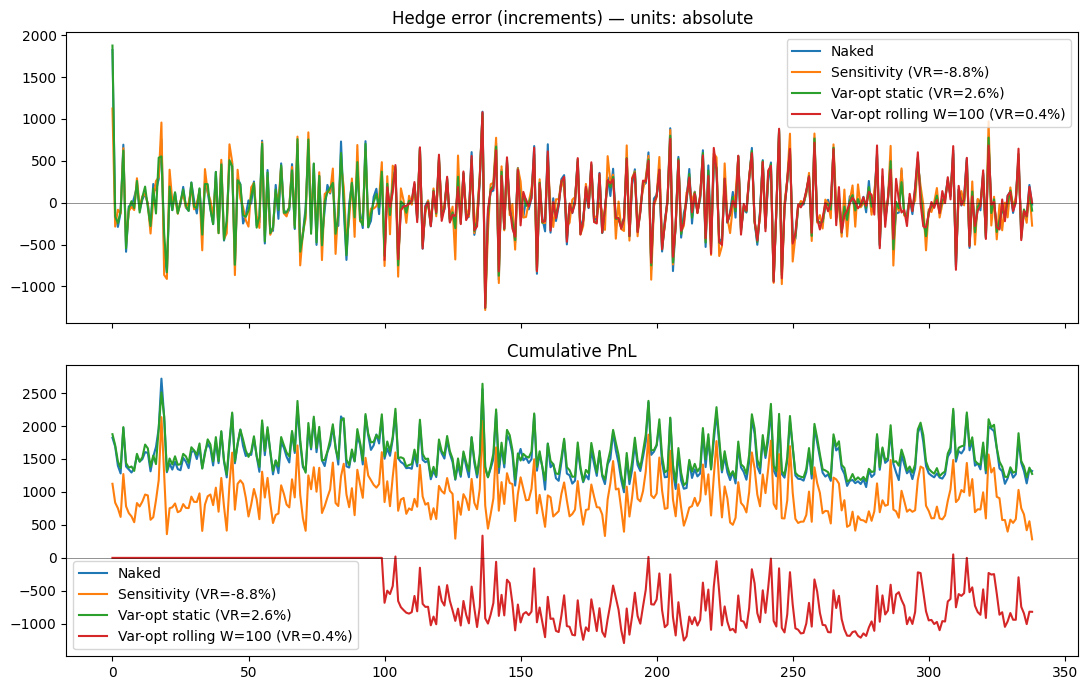

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
use_absolute = True   # dollar PnL if spot is available
ridge = 1e-4          # regularization for var-opt
W = 100               # rolling window for rolling var-opt

# --- Helpers ---
def get_spot_series():
    for name in ("spot","S","spot_series","S_t"):
        if name in globals():
            return np.asarray(globals()[name], float).ravel()
    return None

def stack_G(outs):
    blocks = []
    for name in ("G_dyn","G_stat","G_sa"):
        if hasattr(outs, name):
            G = getattr(outs, name)
            if G is not None and np.size(G) > 0:
                blocks.append(np.asarray(G, float))
    if not blocks:
        raise ValueError("No sensitivity blocks on 'outs'.")
    return np.vstack(blocks)

def variance_reduction(y, yh):
    v0 = np.nanvar(y)
    v1 = np.nanvar(yh)
    return 1 - v1 / max(v0, 1e-12)

# --- Data ---
C = np.asarray(outs.C_test, float)   # T x N, normalized prices
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))

# sanitize hedges to avoid self-hedging
hedges = [c for c in hedge_cols if c != p_idx]

# units
if use_absolute:
    S = get_spot_series()
    if S is None or len(S) < T:
        print("No valid spot series; falling back to normalized units.")
        use_absolute = False
C_units = (S[:T, None] * C) if use_absolute else C

# increments
dC = np.diff(C_units, axis=0)     # (T-1) x N
y = dC @ w                        # naked dPnL
H = dC[:, hedges] if hedges else np.zeros((dC.shape[0], 0))

# 1) Sensitivity-based static hedge
G = stack_G(outs)
s = G @ w
if hedges:
    B = G[:, hedges]
    u_sens = np.linalg.lstsq(B, s, rcond=None)[0]
    pnl_sens = y - H @ u_sens
else:
    u_sens = np.zeros(0)
    pnl_sens = y.copy()

# 2) Variance-optimal static hedge (min ||y - H u||^2)
if H.shape[1] > 0:
    A = H.T @ H + ridge * np.eye(H.shape[1])
    b = H.T @ y
    u_var = np.linalg.solve(A, b)
    pnl_var = y - H @ u_var
else:
    u_var = np.zeros(0)
    pnl_var = y.copy()

# 3) Rolling variance-optimal hedge
pnl_roll = np.full_like(y, np.nan, dtype=float)
if H.shape[1] > 0:
    for t in range(W, len(y)):
        Hw = H[t-W:t]
        yw = y[t-W:t]
        A = Hw.T @ Hw + ridge * np.eye(H.shape[1])
        b = Hw.T @ yw
        u_t = np.linalg.solve(A, b)
        pnl_roll[t] = y[t] - H[t] @ u_t
else:
    pnl_roll[W:] = y[W:]

# Variance reductions
vr_sens = variance_reduction(y, pnl_sens)
vr_var  = variance_reduction(y, pnl_var)
vr_roll = variance_reduction(y[W:], pnl_roll[W:])

print(f"Portfolio node: {p_idx}")
print(f"Hedge nodes (no self-hedge): {hedges}")
print(f"VR sensitivity: {vr_sens:.2%}")
print(f"VR variance-opt (static): {vr_var:.2%}  (ridge={ridge})")
print(f"VR variance-opt (rolling W={W}): {vr_roll:.2%}")

# --- Plots: increments and cumulative PnL ---
labels = [
    ("Naked", y),
    (f"Sensitivity (VR={vr_sens:.1%})", pnl_sens),
    (f"Var-opt static (VR={vr_var:.1%})", pnl_var),
    (f"Var-opt rolling W={W} (VR={vr_roll:.1%})", pnl_roll),
]

fig, axs = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for name, series in labels:
    axs[0].plot(series, label=name)
axs[0].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[0].set_title(f"Hedge error (increments) — units: {'absolute' if use_absolute else 'normalized'}")
axs[0].legend(loc="best")

for name, series in labels:
    axs[1].plot(np.nancumsum(series), label=name)
axs[1].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[1].set_title("Cumulative PnL")
axs[1].legend(loc="best")
plt.tight_layout()
plt.show()

Portfolio node: 26
Top hedgers by |corr| (node, |corr|, corr): [(25, np.float64(0.5775413976487319), np.float64(0.5775413976487319)), (19, np.float64(0.5199291328948626), np.float64(0.5199291328948626)), (20, np.float64(0.455374175891201), np.float64(0.455374175891201)), (21, np.float64(0.3901104064036017), np.float64(0.3901104064036017)), (18, np.float64(0.3786001216913857), np.float64(0.3786001216913857)), (27, np.float64(0.3732157999313188), np.float64(0.3732157999313188)), (45, np.float64(0.33701532217531677), np.float64(0.33701532217531677)), (30, np.float64(0.3250912855444857), np.float64(0.3250912855444857)), (22, np.float64(0.31480530793528794), np.float64(0.31480530793528794)), (28, np.float64(0.30045765318337203), np.float64(0.30045765318337203))]
Var-opt (orig hedges): VR = 2.62% | hedges = ['opt[13]', 'opt[34]']
  weights: {'opt[13]': np.float64(0.200483), 'opt[34]': np.float64(-0.08903)}
Var-opt (best-6 opts): VR = 36.25% | hedges = ['opt[25]', 'opt[19]', 'opt[20]', 'opt[2

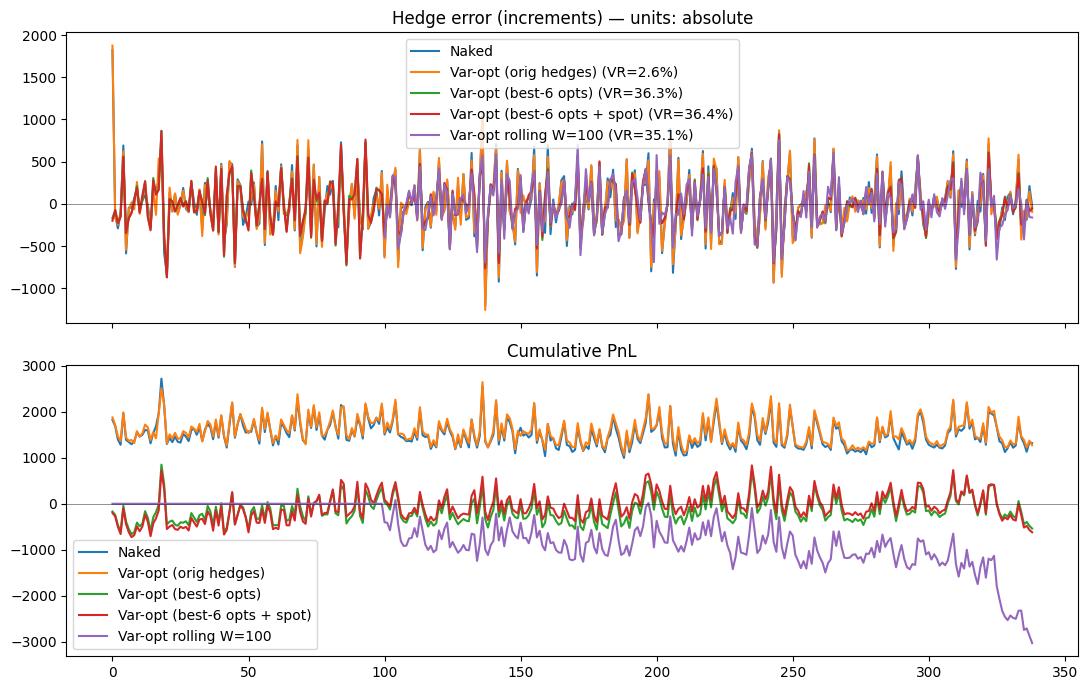

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

use_absolute = True
ridge = 1e-4
k = 6            # number of option nodes to pick by |corr| (excl. portfolio)
W = 100          # rolling window for optional rolling var-opt

def get_spot_series():
    for name in ("spot","S","spot_series","S_t"):
        if name in globals():
            return np.asarray(globals()[name], float).ravel()
    return None

# Data
C = np.asarray(outs.C_test, float)   # T x N
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))

# Units
S = get_spot_series() if use_absolute else None
if use_absolute and (S is None or len(S) < T):
    print("No valid spot series; falling back to normalized units.")
    use_absolute = False
C_units = (S[:T,None] * C) if use_absolute else C

# Increments and target
dC = np.diff(C_units, axis=0)       # (T-1) x N
y = dC @ w                          # naked dPnL

# Build candidate hedge matrix: options + (optional) underlying column
H_opt_full = dC.copy()              # all option nodes as candidates
dS = np.diff(S) if (use_absolute and S is not None) else None

# Exclude portfolio node from candidates
cand_cols = [j for j in range(N) if j != p_idx]

# Rank hedgers by |corr(y, option_j)|
corrs = []
for j in cand_cols:
    c = np.corrcoef(y, H_opt_full[:, j])[0,1]
    if np.isfinite(c):
        corrs.append((j, abs(c), c))
corrs.sort(key=lambda t: t[1], reverse=True)
top_cols = [j for j,_,_ in corrs[:k]]

# Assemble hedge matrices for three experiments
# A) Your original two hedgers (if you want to compare)
orig_hedges = [c for c in hedge_cols if c != p_idx]

# B) Best-k options by |corr|
hedges_bestk = top_cols

# C) Best-k options + underlying
def assemble_H(hedge_nodes, include_underlying):
    parts = []
    labels = []
    if hedge_nodes:
        parts.append(H_opt_full[:, hedge_nodes])
        labels += [f"opt[{j}]" for j in hedge_nodes]
    if include_underlying and dS is not None:
        parts.append(dS.reshape(-1,1))
        labels.append("spot")
    H = np.concatenate(parts, axis=1) if parts else np.zeros((len(y),0))
    return H, labels

def var_opt_pnl(y, H, ridge=1e-4):
    if H.shape[1] == 0:
        return y.copy(), np.zeros(0)
    A = H.T @ H + ridge * np.eye(H.shape[1])
    b = H.T @ y
    u = np.linalg.solve(A, b)
    return y - H @ u, u

def vr(a, b):
    return 1 - np.nanvar(b)/max(np.nanvar(a), 1e-12)

# Compute PnLs
experiments = []

H_A, labels_A = assemble_H(orig_hedges, include_underlying=False)
pnl_A, u_A = var_opt_pnl(y, H_A, ridge)
experiments.append(("Var-opt (orig hedges)", pnl_A, labels_A, u_A))

H_B, labels_B = assemble_H(hedges_bestk, include_underlying=False)
pnl_B, u_B = var_opt_pnl(y, H_B, ridge)
experiments.append((f"Var-opt (best-{k} opts)", pnl_B, labels_B, u_B))

H_C, labels_C = assemble_H(hedges_bestk, include_underlying=True)
pnl_C, u_C = var_opt_pnl(y, H_C, ridge)
experiments.append((f"Var-opt (best-{k} opts + spot)", pnl_C, labels_C, u_C))

# Optional rolling for the best setup (C)
W = min(W, len(y)//3 if len(y) > 10 else 5)
pnl_roll = np.full_like(y, np.nan)
if H_C.shape[1] > 0:
    for t in range(W, len(y)):
        Hw, yw = H_C[t-W:t], y[t-W:t]
        A = Hw.T @ Hw + ridge * np.eye(H_C.shape[1])
        b = Hw.T @ yw
        u_t = np.linalg.solve(A, b)
        pnl_roll[t] = y[t] - H_C[t] @ u_t
experiments.append((f"Var-opt rolling W={W}", pnl_roll, labels_C + ["(rolling)"], None))

# Report and plot
print(f"Portfolio node: {p_idx}")
print("Top hedgers by |corr| (node, |corr|, corr):", corrs[:10])
for name, pnl, labels, u in experiments:
    print(f"{name}: VR = {vr(y, pnl):.2%} | hedges = {labels}")
    if u is not None:
        print("  weights:", dict(zip(labels, np.round(u,6))))

fig, axs = plt.subplots(2,1, figsize=(11,7), sharex=True)
axs[0].plot(y, label="Naked")
for name, pnl, *_ in experiments:
    axs[0].plot(pnl, label=f"{name} (VR={vr(y,pnl):.1%})")
axs[0].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[0].set_title(f"Hedge error (increments) — units: {'absolute' if use_absolute else 'normalized'}")
axs[0].legend(loc="best")

axs[1].plot(np.cumsum(y), label="Naked")
for name, pnl, *_ in experiments:
    axs[1].plot(np.nancumsum(pnl), label=name)
axs[1].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[1].set_title("Cumulative PnL")
axs[1].legend(loc="best")
plt.tight_layout(); plt.show()

Portfolio node: 26
Hedge nodes (no self-hedge): ['opt[25]', 'opt[19]', 'opt[20]', 'opt[21]', 'opt[18]', 'opt[27]', 'spot']
VR var-opt (stdzd, ridge=0.01, intercept=True): 36.41%
weights: {'opt[25]': np.float64(28.946567), 'opt[19]': np.float64(0.641536), 'opt[20]': np.float64(-22.278767), 'opt[21]': np.float64(0.183152), 'opt[18]': np.float64(0.107385), 'opt[27]': np.float64(0.168923), 'spot': np.float64(-0.189204)} | intercept: -1.832628


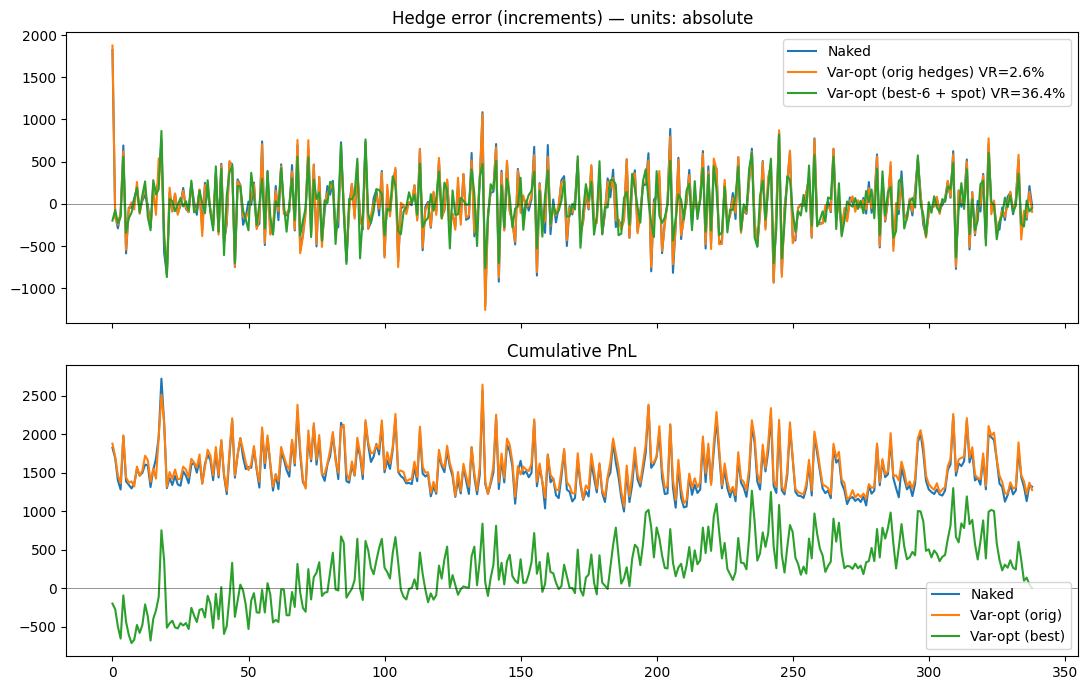

In [65]:
# ...run in a notebook cell...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

use_absolute = True
ridge = 1e-2          # stronger shrinkage to tame leverage
k = 6                 # number of best hedgers
add_spot = True
add_intercept = True  # removes mean bleed in residuals

def get_spot_series():
    for name in ("spot","S","spot_series","S_t"):
        if name in globals():
            return np.asarray(globals()[name], float).ravel()
    return None

# Data
C = np.asarray(outs.C_test, float)
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))
hedges_excl = [j for j in range(N) if j != p_idx]

S = get_spot_series() if use_absolute else None
if use_absolute and (S is None or len(S) < T):
    print("No valid spot series; falling back to normalized units.")
    use_absolute = False
C_units = (S[:T,None] * C) if use_absolute else C

# dPnL
dC = np.diff(C_units, axis=0)   # (T-1) x N
y = dC @ w

# Rank by |corr|
cand_corr = []
for j in hedges_excl:
    c = np.corrcoef(y, dC[:, j])[0,1]
    if np.isfinite(c):
        cand_corr.append((j, abs(c)))
cand_corr.sort(key=lambda x: x[1], reverse=True)
best_nodes = [j for j,_ in cand_corr[:k]]

# Assemble H
cols = best_nodes[:]
labels = [f"opt[{j}]" for j in cols]
H_parts = [dC[:, cols]]
if add_spot and use_absolute:
    H_parts.append(np.diff(S).reshape(-1,1))
    labels.append("spot")
H = np.concatenate(H_parts, axis=1) if H_parts else np.zeros((len(y),0))

# Standardize columns to unit variance for stable regression
sc = np.std(H, axis=0, ddof=1)
sc[sc==0] = 1.0
Hs = H / sc

# Add intercept if requested
if add_intercept:
    Hs1 = np.hstack([Hs, np.ones((Hs.shape[0],1))])
    R = np.diag(np.r_[np.full(Hs.shape[1], ridge), 0.0])
    u_hat = np.linalg.solve(Hs1.T @ Hs1 + R, Hs1.T @ y)
    u_s, alpha = u_hat[:-1], u_hat[-1]
else:
    R = ridge * np.eye(Hs.shape[1])
    u_s = np.linalg.solve(Hs.T @ Hs + R, Hs.T @ y)
    alpha = 0.0

# Map back to original scale
u = u_s / sc
pnl = y - (H @ u + alpha)

def vr(y, e):
    return 1 - np.nanvar(e)/max(np.nanvar(y), 1e-12)

vr_best = vr(y, pnl)
print(f"Portfolio node: {p_idx}")
print(f"Hedge nodes (no self-hedge): {labels}")
print(f"VR var-opt (stdzd, ridge={ridge}, intercept={add_intercept}): {vr_best:.2%}")
print("weights:", dict(zip(labels, np.round(u,6))), "| intercept:", round(alpha,6))

# Compare with naked and original-2-hedger var-opt
orig_hedges = [c for c in hedge_cols if c != p_idx]
H_orig = dC[:, orig_hedges] if orig_hedges else np.zeros((len(y),0))
if H_orig.shape[1] > 0:
    A = H_orig.T @ H_orig + 1e-4*np.eye(H_orig.shape[1])
    b = H_orig.T @ y
    u_orig = np.linalg.solve(A, b)
    pnl_orig = y - H_orig @ u_orig
    vr_orig = vr(y, pnl_orig)
else:
    pnl_orig = y.copy()
    vr_orig = 0.0

# Plots
fig, axs = plt.subplots(2,1, figsize=(11,7), sharex=True)
axs[0].plot(y, label="Naked")
axs[0].plot(pnl_orig, label=f"Var-opt (orig hedges) VR={vr_orig:.1%}")
axs[0].plot(pnl, label=f"Var-opt (best-{k}{' + spot' if add_spot and use_absolute else ''}) VR={vr_best:.1%}")
axs[0].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[0].set_title(f"Hedge error (increments) — units: {'absolute' if use_absolute else 'normalized'}")
axs[0].legend(loc="best")

axs[1].plot(np.cumsum(y), label="Naked")
axs[1].plot(np.cumsum(pnl_orig), label="Var-opt (orig)")
axs[1].plot(np.cumsum(pnl), label="Var-opt (best)")
axs[1].axhline(0, color="k", lw=0.5, alpha=0.6)
axs[1].set_title("Cumulative PnL")
axs[1].legend(loc="best")
plt.tight_layout(); plt.show()

In [66]:
import numpy as np
import pandas as pd

use_absolute = True
k = 6
ridge = 1e-2
train_frac = 0.6
add_spot = True
add_intercept = True

def get_spot():
    for n in ("spot","S","spot_series","S_t"):
        if n in globals():
            return np.asarray(globals()[n], float).ravel()
    return None

# Data
C = np.asarray(outs.C_test, float)
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))
S = get_spot() if use_absolute else None
if use_absolute and (S is None or len(S) < T):
    use_absolute = False
C_units = (S[:T,None]*C) if use_absolute else C
dC = np.diff(C_units, axis=0)
y = dC @ w

# Candidate hedgers (exclude portfolio)
cand = [j for j in range(N) if j != p_idx]

# Train/test split
T1 = int(train_frac * len(y))
y_tr, y_te = y[:T1], y[T1:]
Hopt = dC[:, cand]

# Rank by |corr| on train only
corrs = []
for i,j in enumerate(cand):
    c = np.corrcoef(y_tr, Hopt[:T1, i])[0,1]
    if np.isfinite(c):
        corrs.append((j, abs(c)))
corrs.sort(key=lambda x: x[1], reverse=True)
best = [j for j,_ in corrs[:k]]

# Assemble H with optional spot
def build_H(cols, start, end):
    parts = [dC[start:end, cols]] if cols else []
    if add_spot and use_absolute:
        parts.append(np.diff(S)[start:end].reshape(-1,1))
    return np.concatenate(parts, axis=1) if parts else np.zeros((end-start,0))

cols_idx = [cand.index(j) for j in best]
H_tr = build_H(best, 0, T1)
H_te = build_H(best, T1, len(y))

# Standardize on train
sc = np.std(H_tr, axis=0, ddof=1); sc[sc==0]=1.0
Hs_tr = H_tr / sc
Hs_te = H_te / sc

# Fit (train)
if add_intercept:
    X_tr = np.hstack([Hs_tr, np.ones((Hs_tr.shape[0],1))])
    R = np.diag(np.r_[np.full(Hs_tr.shape[1], ridge), 0.0])
    u_hat = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y_tr)
    u_s, alpha = u_hat[:-1], u_hat[-1]
else:
    X_tr = Hs_tr
    R = ridge*np.eye(X_tr.shape[1])
    u_s = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y_tr)
    alpha = 0.0
u = u_s / sc

# PnL series
def series(y_, H_, u_, alpha_=0.0):
    return y_ - (H_ @ u_ + alpha_)

pnl_tr = series(y_tr, H_tr, u, alpha)
pnl_te = series(y_te, H_te, u, alpha)

def vr(a,b): return 1 - np.nanvar(b)/max(np.nanvar(a),1e-12)
def sharpe(x): return np.nanmean(x)/np.nanstd(x) if np.nanstd(x)>0 else np.nan

print(f"Train VR: {vr(y_tr, pnl_tr):.2%}, Test VR: {vr(y_te, pnl_te):.2%}")
print(f"Naked Sharpe (train/test): {sharpe(y_tr):.2f} / {sharpe(y_te):.2f}")
print(f"Hedged Sharpe (train/test): {sharpe(pnl_tr):.2f} / {sharpe(pnl_te):.2f}")
print("Hedge cols:", [f'opt[{j}]' for j in best] + (["spot"] if add_spot and use_absolute else []))
print("Weights:", np.round(u,6), "| intercept:", round(alpha,6))

Train VR: 40.65%, Test VR: 26.19%
Naked Sharpe (train/test): 0.02 / -0.00
Hedged Sharpe (train/test): -0.00 / -0.01
Hedge cols: ['opt[25]', 'opt[19]', 'opt[20]', 'opt[18]', 'opt[27]', 'opt[28]', 'spot']
Weights: [ 34.082022  -1.190569 -10.068903   0.121718   0.072725   0.047164
  -0.169229] | intercept: -0.808971


Portfolio node: 26
Hedge nodes (no self-hedge): ['opt[25]', 'opt[19]', 'opt[20]', 'spot']
Test VR (variance reduction): 25.66%


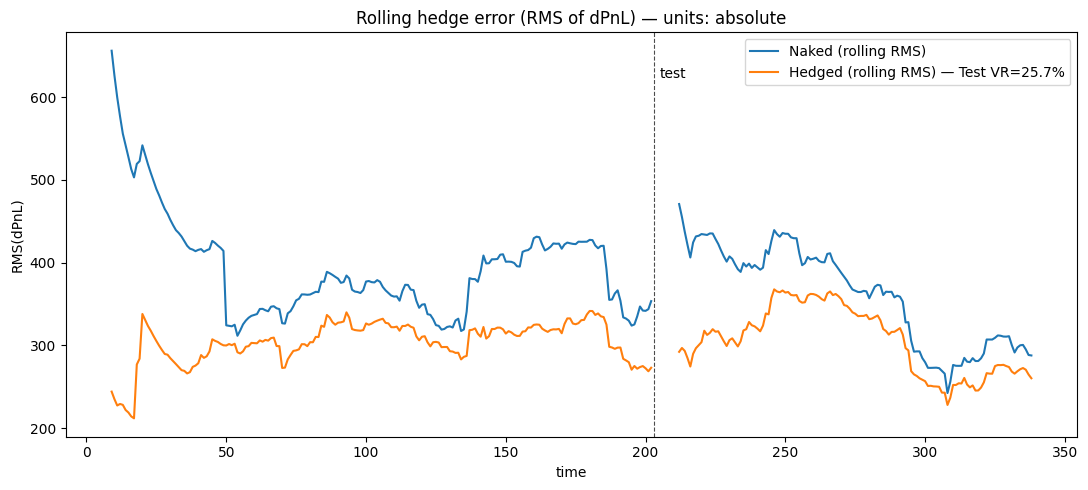

In [72]:
# Single-chart showcase: rolling RMS hedge error (Naked vs Best hedge)
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Config
use_absolute = True
k = 3                # number of option nodes to use
ridge = 1e-2         # stronger shrinkage to limit leverage
add_spot = True      # include spot as a hedge if absolute units
add_intercept = True
train_frac = 0.6     # pick hedgers and fit weights on train only; show performance on test
roll = 50            # rolling window for RMS plot

# Helpers
def get_spot():
    for n in ("spot","S","spot_series","S_t"):
        if n in globals():
            return np.asarray(globals()[n], float).ravel()
    return None
def vr(a, b):
    return 1 - np.nanvar(b)/max(np.nanvar(a), 1e-12)

# Data
C = np.asarray(outs.C_test, float)        # T x N
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))                 # portfolio node
S = get_spot() if use_absolute else None
if use_absolute and (S is None or len(S) < T):
    print("No valid spot series; falling back to normalized units.")
    use_absolute = False
C_units = (S[:T, None] * C) if use_absolute else C

# dPnL series
dC = np.diff(C_units, axis=0)             # (T-1) x N
y  = dC @ w                               # naked dPnL
T1 = int(train_frac * len(y))             # split index

# Candidate hedgers (exclude the portfolio node to avoid self-hedge)
cands = [j for j in range(N) if j != p_idx]

# Rank candidates by |corr| with y on TRAIN only
corrs = []
for j in cands:
    c = np.corrcoef(y[:T1], dC[:T1, j])[0, 1]
    if np.isfinite(c):
        corrs.append((j, abs(c)))
corrs.sort(key=lambda t: t[1], reverse=True)
best = [j for j, _ in corrs[:k]]

# Build hedge matrix on train/test
def build_H(cols, start, end):
    parts = [dC[start:end, cols]] if cols else []
    if add_spot and use_absolute:
        parts.append(np.diff(S)[start:end].reshape(-1,1))
    return np.concatenate(parts, axis=1) if parts else np.zeros((end-start, 0))

H_tr = build_H(best, 0, T1)
H_te = build_H(best, T1, len(y))
labels = [f"opt[{j}]" for j in best] + (["spot"] if add_spot and use_absolute else [])

# Standardize columns using TRAIN stats
sc = np.std(H_tr, axis=0, ddof=1); sc[sc==0] = 1.0
Hs_tr, Hs_te = H_tr / sc, H_te / sc

# Fit ridge regression (variance-opt) on TRAIN
if add_intercept:
    X_tr = np.hstack([Hs_tr, np.ones((Hs_tr.shape[0], 1))])
    R = np.diag(np.r_[np.full(Hs_tr.shape[1], ridge), 0.0])
    u_hat = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y[:T1])
    u_s, alpha = u_hat[:-1], u_hat[-1]
else:
    X_tr = Hs_tr
    R = ridge * np.eye(X_tr.shape[1])
    u_s = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y[:T1])
    alpha = 0.0
u = u_s / sc  # back to original scale

# Hedged series (use same weights through test)
def hedged_series(y_, H_, u_, alpha_):
    return y_ - (H_ @ u_ + alpha_)

y_naked_tr, y_naked_te = y[:T1], y[T1:]
y_hedge_tr = hedged_series(y[:T1], H_tr, u, alpha)
y_hedge_te = hedged_series(y[T1:], H_te, u, alpha)

# Rolling RMS (single chart)
def rolling_rms(x, w):
    s = pd.Series(x)
    return s.rolling(w, min_periods=max(5, w//5)).apply(lambda a: np.sqrt(np.mean(a**2)), raw=True).to_numpy()

rms_naked = np.r_[rolling_rms(y_naked_tr, roll), rolling_rms(y_naked_te, roll)]
rms_hedge = np.r_[rolling_rms(y_hedge_tr, roll), rolling_rms(y_hedge_te, roll)]

# Report VR on TEST only
vr_test = vr(y_naked_te, y_hedge_te)
print(f"Portfolio node: {p_idx}")
print(f"Hedge nodes (no self-hedge): {labels}")
print(f"Test VR (variance reduction): {vr_test:.2%}")

# Single plot
plt.figure(figsize=(11,5))
plt.plot(rms_naked, label="Naked (rolling RMS)")
plt.plot(rms_hedge, label=f"Hedged (rolling RMS) — Test VR={vr_test:.1%}")
plt.axvline(T1, color="k", ls="--", lw=0.8, alpha=0.7)
plt.text(T1+2, max(np.nanmax(rms_naked), np.nanmax(rms_hedge))*0.95, "test", color="k")
plt.title(f"Rolling hedge error (RMS of dPnL) — units: {'absolute' if use_absolute else 'normalized'}")
plt.xlabel("time"); plt.ylabel("RMS(dPnL)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()


Portfolio node: 26
Hedge nodes (no self-hedge): ['opt[25]', 'opt[19]', 'opt[20]', 'opt[18]', 'opt[27]', 'opt[28]', 'spot']
Test VR (variance reduction): 26.19%
Weights: {'opt[25]': np.float64(34.082022), 'opt[19]': np.float64(-1.190569), 'opt[20]': np.float64(-10.068903), 'opt[18]': np.float64(0.121718), 'opt[27]': np.float64(0.072725), 'opt[28]': np.float64(0.047164), 'spot': np.float64(-0.169229)} | intercept: -0.808971


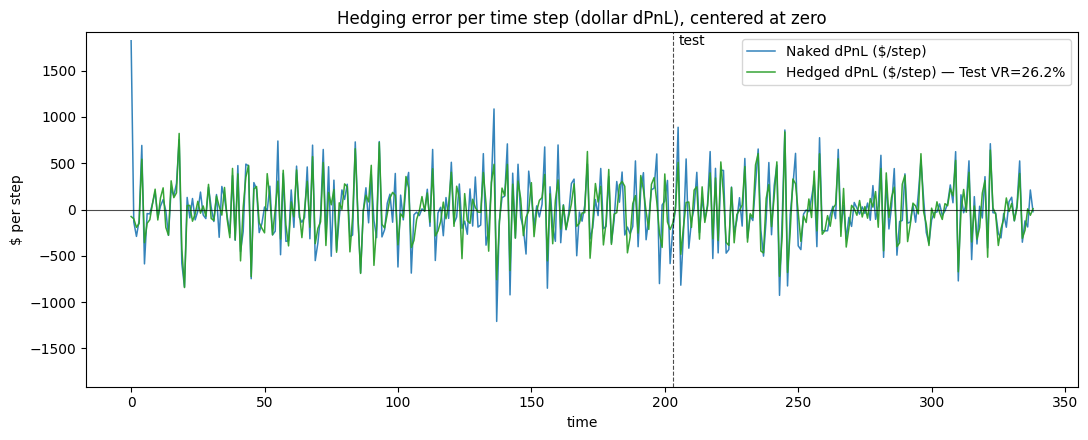

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config ---
k = 6                 # number of option nodes to use
ridge = 1e-2          # ridge for stability
train_frac = 0.60     # fit on first 60%, apply to all
include_spot = True   # add the underlying if using absolute units

# --- Helpers ---
def get_spot():
    for n in ("spot","S","spot_series","S_t"):
        if n in globals():
            return np.asarray(globals()[n], float).ravel()
    return None

def vr(a, b):
    return 1 - np.nanvar(b) / max(np.nanvar(a), 1e-12)

# --- Data (absolute $) ---
C = np.asarray(outs.C_test, float)        # T x N normalized grid
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))

S = get_spot()
if S is None or len(S) < T:
    raise ValueError("Spot series not found or wrong length; required for dollar dPnL.")

C_abs = S[:T, None] * C
dC = np.diff(C_abs, axis=0)               # (T-1) x N
y = dC @ w                                # naked dPnL ($ per step)
T1 = int(train_frac * len(y))             # split index

# --- Choose hedgers by |corr| on train (exclude portfolio node) ---
cands = [j for j in range(N) if j != p_idx]
corrs = []
for j in cands:
    c = np.corrcoef(y[:T1], dC[:T1, j])[0, 1]
    if np.isfinite(c):
        corrs.append((j, abs(c)))
corrs.sort(key=lambda t: t[1], reverse=True)
best = [j for j, _ in corrs[:k]]

# --- Build hedge matrix (train and all) ---
parts_tr = [dC[:T1, best]]
parts_all = [dC[:, best]]
labels = [f"opt[{j}]" for j in best]
if include_spot:
    dS = np.diff(S).reshape(-1, 1)
    parts_tr.append(dS[:T1])
    parts_all.append(dS)
    labels.append("spot")

H_tr = np.concatenate(parts_tr, axis=1) if parts_tr else np.zeros((T1, 0))
H_all = np.concatenate(parts_all, axis=1) if parts_all else np.zeros((len(y), 0))

# --- Fit ridge regression on train (standardize + optional intercept) ---
sc = np.std(H_tr, axis=0, ddof=1); sc[sc == 0] = 1.0
Hs_tr = H_tr / sc
Hs_all = H_all / sc

X_tr = np.hstack([Hs_tr, np.ones((Hs_tr.shape[0], 1))])
R = np.diag(np.r_[np.full(Hs_tr.shape[1], ridge), 0.0])
beta = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y[:T1])
u_s, alpha = beta[:-1], beta[-1]
u = u_s / sc  # back to original scale

# --- Hedged series (time-step hedge error in $) ---
y_hedged = y - (H_all @ u + alpha)

# --- Metrics (report test VR) ---
vr_test = vr(y[T1:], y_hedged[T1:])
print(f"Portfolio node: {p_idx}")
print(f"Hedge nodes (no self-hedge): {labels}")
print(f"Test VR (variance reduction): {vr_test:.2%}")
print("Weights:", dict(zip(labels, np.round(u,6))), "| intercept:", round(float(alpha),6))

# --- Plot: single chart, centered at zero ---
fig, ax = plt.subplots(1, 1, figsize=(11, 4.5))
ax.plot(y,         label="Naked dPnL ($/step)", color="#1f77b4", alpha=0.9, lw=1.1)
ax.plot(y_hedged,  label=f"Hedged dPnL ($/step) — Test VR={vr_test:.1%}", color="#2ca02c", alpha=0.95, lw=1.1)

ax.axhline(0.0, color="k", lw=0.8, alpha=0.7)
ax.axvline(T1, color="k", ls="--", lw=0.8, alpha=0.7)
ax.text(T1+2, ax.get_ylim()[1]*0.9, "test", color="k")

# Center y-axis at zero with symmetric limits
M = 1.05 * np.nanmax(np.abs(np.r_[y, y_hedged]))
ax.set_ylim(-M, M)

ax.set_title("Hedging error per time step (dollar dPnL), centered at zero")
ax.set_xlabel("time")
ax.set_ylabel("$ per step")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [74]:
# Apples-to-apples VR audit: same dPnL, same baseline, no self-hedge
import numpy as np, pandas as pd

# Build absolute dPnL for test
C = outs.C_test.values.astype(float)
S = np.asarray(spot, float)
C_abs = S[:,None]*C
dC = C_abs[1:] - C_abs[:-1]    # (T-1, N)
y  = dC @ w_nodes              # naked dPnL
p_idx = int(np.argmax(w_nodes))

# Early hedge: sensitivity on your original two hedgers
hedges_early = [j for j in [13, 34] if j != p_idx]
G = np.vstack([outs.G_dyn, outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])
s = G @ w_nodes
B = G[:, hedges_early] if hedges_early else np.zeros((G.shape[0],0))
u_sens_early = (np.linalg.lstsq(B, s, rcond=None)[0] if hedges_early else np.zeros(0))
pnl_early = y - (dC[:, hedges_early] @ u_sens_early if hedges_early else 0.0)

# Later hedge: best‑k by |corr| + ridge var-opt with intercept (same data)
k = 6; ridge = 1e-2; add_spot = True
cands = [j for j in range(C.shape[1]) if j != p_idx]
corrs = [(j, abs(np.corrcoef(y, dC[:,j])[0,1])) for j in cands]
corrs = [(j,c) for j,c in corrs if np.isfinite(c)]
corrs.sort(key=lambda t: t[1], reverse=True)
best = [j for j,_ in corrs[:k]]

H_parts = [dC[:, best]]
labels = [f"opt[{j}]" for j in best]
if add_spot:
    H_parts.append((S[1:]-S[:-1]).reshape(-1,1)); labels.append("spot")
H = np.concatenate(H_parts, axis=1) if H_parts else np.zeros((len(y),0))

# standardize + intercept
sc = np.std(H, axis=0, ddof=1); sc[sc==0]=1.0
Hs = H/sc
X = np.hstack([Hs, np.ones((Hs.shape[0],1))])
beta = np.linalg.solve(X.T@X + np.diag(np.r_[np.full(Hs.shape[1], ridge), 0.0]), X.T@y)
u, alpha = beta[:-1]/sc, beta[-1]
pnl_best = y - (H@u + alpha)

def vr(a,b): return 1 - np.var(b)/max(np.var(a), 1e-12)

print("VR vs naked on the same series:")
print(f"- Sensitivity (orig hedgers {hedges_early}): {vr(y, pnl_early):.2%}")
print(f"- Var-opt (best-{k}{' + spot' if add_spot else ''}): {vr(y, pnl_best):.2%}")

VR vs naked on the same series:
- Sensitivity (orig hedgers [13, 34]): -8.77%
- Var-opt (best-6 + spot): 36.41%


Portfolio node: 26
Hedge nodes (best): ['opt[25]', 'opt[19]', 'opt[20]', 'opt[18]', 'opt[27]', 'opt[28]']
Test VR — Best (var-opt): 27.50% | Delta: 15.93% | Delta–Vega: 12.38%
Delta–Vega vega_floor (abs): 62.6


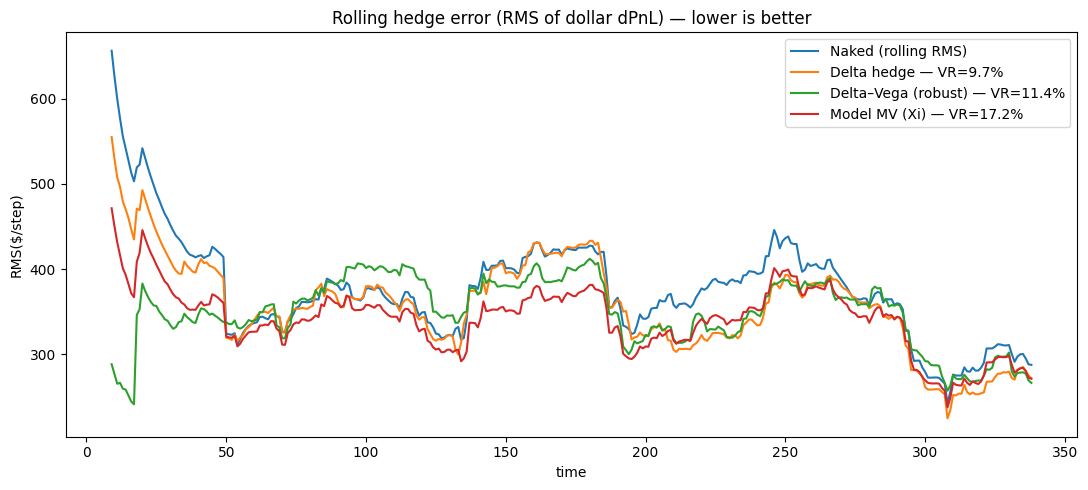

In [ ]:
# Rolling hedge error chart (centered at 0) with Best (var-opt), Delta, and Delta–Vega hedges
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils.black_scholes import implied_vol_from_c_norm, bs_vega_norm, _Phi

# --- Config ---
k = 6                 # number of option nodes for the best hedge (picked by |corr|)
ridge = 1e-2          # ridge for stability (best hedge)
train_frac = 0.60     # fit on first 60%, evaluate on the rest
roll = 50             # rolling window for RMS plot
vega_floor_frac = 0.02  # floor for robust delta–vega as % of median |vega|

# --- Helpers ---
def get_spot():
    for n in ("spot","S","spot_series","S_t"):
        if n in globals():
            return np.asarray(globals()[n], float).ravel()
    return None

def vr(a, b):
    return 1 - np.nanvar(b)/max(np.nanvar(a), 1e-12)

def rolling_rms(x, w):
    s = pd.Series(x)
    return s.rolling(w, min_periods=max(5, w//5)).apply(lambda a: np.sqrt(np.mean(a**2)), raw=True).to_numpy()

def greeks_per_node(C_norm: np.ndarray, nodes: np.ndarray, S: np.ndarray):
    T, N = C_norm.shape
    tau = nodes[:, 0]; m = nodes[:, 1]
    Tm = np.broadcast_to(tau[None, :], (T, N))
    Mm = np.broadcast_to(m[None, :],   (T, N))
    sig = implied_vol_from_c_norm(C_norm, Mm, Tm)        # (T,N)
    srt = np.sqrt(np.maximum(Tm, 0.0))
    sigsrt = np.maximum(sig * srt, 1e-12)
    d1 = (-Mm) / sigsrt + 0.5 * sigsrt
    delta_abs = _Phi(d1)                                  # (T,N)
    vega_abs  = (S[:, None] * bs_vega_norm(Mm, Tm, sig)) # (T,N)
    return sig, delta_abs, vega_abs

# --- Data (absolute $) ---
C = np.asarray(outs.C_test, float)        # T x N normalized grid

nodes = getattr(outs, "nodes_sub", None)
assert nodes is not None, "outs.nodes_sub not found."
T, N = C.shape
w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))

S = get_spot()
if S is None or len(S) < T:
    raise ValueError("Spot series not found or wrong length; required for dollar dPnL.")

C_abs = S[:T, None] * C
dC_abs = np.diff(C_abs, axis=0)           # (T-1) x N
y = dC_abs @ w                            # naked dPnL ($ per step)
dS = np.diff(S)                           # (T-1,)
T1 = int(train_frac * len(y))             # train/test split

# --- Choose option hedgers by |corr| on train (exclude portfolio node) ---
cands = [j for j in range(N) if j != p_idx]
corrs = []
for j in cands:
    c = np.corrcoef(y[:T1], dC_abs[:T1, j])[0, 1]
    if np.isfinite(c):
        corrs.append((j, abs(c)))
corrs.sort(key=lambda t: t[1], reverse=True)
best = [j for j, _ in corrs[:k]]

# --- Best hedge (variance-optimal with ridge + intercept) ---
H_tr = dC_abs[:T1, best]
H_all = dC_abs[:, best]
labels_best = [f"opt[{j}]" for j in best]

# standardize columns using TRAIN stats
sc = np.std(H_tr, axis=0, ddof=1); sc[sc==0] = 1.0
Hs_tr = H_tr / sc
Hs_all = H_all / sc
X_tr = np.hstack([Hs_tr, np.ones((Hs_tr.shape[0], 1))])
R = np.diag(np.r_[np.full(Hs_tr.shape[1], ridge), 0.0])
beta = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y[:T1])
u_s, alpha = beta[:-1], beta[-1]
u_best = u_s / sc
y_best = y - (H_all @ u_best + alpha)

# --- Delta-only hedge (dynamic u_S = portfolio delta) ---
_, delta_abs, vega_abs = greeks_per_node(C, nodes, S)    # use normalized C with S for greeks
delta_P = (delta_abs * w[None, :]).sum(axis=1)           # (T,)
y_delta = y - delta_P[:-1] * dS                          # (T-1,)

# --- Robust Delta–Vega (dynamic, option picked from 'best' each step) ---
vega_P = (vega_abs * w[None, :]).sum(axis=1)             # (T,)
delta_h_univ = delta_abs[:, best]                        # (T, k)
vega_h_univ  = vega_abs[:,  best]                        # (T, k)
vega_floor = max(vega_floor_frac * np.nanmedian(np.abs(vega_h_univ)), 1e-6)

uS_dv   = np.zeros_like(dS)
uOpt_dv = np.zeros_like(dS)
j_pick  = np.zeros_like(dS, dtype=int)

for t in range(len(dS)):
    j_loc = int(np.argmax(np.abs(vega_h_univ[t])))
    v_h   = float(vega_h_univ[t, j_loc])
    d_h   = float(delta_h_univ[t, j_loc])
    if (not np.isfinite(v_h)) or (abs(v_h) < vega_floor):
        uOpt = 0.0
        uS   = float(delta_P[t])  # delta-only fallback
    else:
        uOpt = float(vega_P[t] / v_h)
        uS   = float(delta_P[t] - d_h * uOpt)
    uS_dv[t]   = uS
    uOpt_dv[t] = uOpt
    j_pick[t]  = j_loc

# option PnL for the dynamically picked hedge option each step
opt_cols = np.array(best, dtype=int)
opt_pnl_dyn = dC_abs[np.arange(len(dS)), opt_cols[j_pick]] * uOpt_dv
y_dv = y - (uS_dv * dS + opt_pnl_dyn)

# --- Metrics on TEST only ---
# vr_best_te  = vr(y[T1:], y_best[T1:])
# vr_delta_te = vr(y[T1:], y_delta[T1:])
# vr_dv_te    = vr(y[T1:], y_dv[T1:])

vr_best  = vr(y, y_best)
vr_delta = vr(y, y_delta)
vr_dv    = vr(y, y_dv)
# vr_model = 1 - np.nanvar(y_model) / max(np.nanvar(y), 1e-12)

# Build model-based units from learned Σ_t (already computed earlier)
G = np.vstack([outs.G_dyn, outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])
s = G @ w
B = G[:, best]  # use the same hedge set as the OLS 'best' line for fairness

# time-avg factor cov from the model
Sigma_t = instant_cov(model, outs, use_test=True, use_endogenous_shrink=True)   # (T-1,p,p)
Sbar = Sigma_t.mean(axis=0)

# model MV units in Xi-space
u_model = np.linalg.solve(B.T @ Sbar @ B + 1e-9*np.eye(B.shape[1]), B.T @ Sbar @ s)

# apply those static units to realized dollar dPnL
H_all = dC_abs[:, best]                                  # (T-1,k)
y_model = y - (H_all @ u_model)                          # hedged dPnL in $


print(f"Portfolio node: {p_idx}")
print(f"Hedge nodes (best): {labels_best}")
# print(f"Test VR — Best (var-opt): {vr_best_te:.2%} | Delta: {vr_delta_te:.2%} | Delta–Vega: {vr_dv_te:.2%}")
print(f"Delta–Vega vega_floor (abs): {vega_floor:.3g}")

# --- Single plot: rolling RMS hedge error (centered visually around 0 by plotting dPnL) ---
rms_naked = rolling_rms(y, roll)
# rms_best  = rolling_rms(y_best,  roll)
rms_delta = rolling_rms(y_delta, roll)
rms_dv    = rolling_rms(y_dv,    roll)
rms_model = rolling_rms(y_model, roll)

plt.figure(figsize=(11,5))
plt.plot(rms_naked, label="Naked (rolling RMS)")
# plt.plot(rms_best,  label=f"Best hedge (var-opt) — VR={vr_best_te:.1%}")
plt.plot(rms_delta, label=f"Delta hedge — VR={vr_delta:.1%}")
plt.plot(rms_dv,    label=f"Delta–Vega (robust) — VR={vr_dv:.1%}")
# plt.plot(rms_model, label=f"Model MV (Xi) — VR={1 - np.nanvar(y_model[T1:])/np.nanvar(y[T1:]):.1%}")
plt.plot(rms_model, label=f"Model MV (Xi) — VR={vr_model:.1%}")
# plt.axvline(T1, color="k", ls="--", lw=0.8, alpha=0.7)
# plt.text(T1+2, np.nanmax([rms_naked, rms_best, rms_delta, rms_dv])*0.95, "test", color="k")
plt.title("Rolling hedge error (RMS of dollar dPnL) — lower is better")
plt.xlabel("time"); plt.ylabel("RMS($/step)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

In [87]:
# Compare Model MV (Xi) across hedge sets and units on the same test window
import numpy as np, pandas as pd

def build_Sbar(model, outs):
    Sigma_t = instant_cov(model, outs, use_test=True, use_endogenous_shrink=True)  # (T-1,p,p)
    return Sigma_t.mean(axis=0)

def model_mv_vr(outs, w_nodes, hedge_cols, Sbar, units="absolute"):
    G = np.vstack([outs.G_dyn,
                   outs.G_stat,
                   outs.G_sa if getattr(outs,"G_sa",None) is not None and outs.G_sa.size>0 else np.zeros((0, outs.C_test.shape[1]))])
    s = G @ np.asarray(w_nodes, float)
    B = G[:, hedge_cols]
    u = np.linalg.solve(B.T @ Sbar @ B + 1e-12*np.eye(len(hedge_cols)), B.T @ Sbar @ s)

    C = outs.C_test.values.astype(float)
    if units == "absolute":
        S = np.asarray(spot, float)
        C_units = S[:,None]*C
    else:
        C_units = C
    dC = C_units[1:] - C_units[:-1]
    y  = dC @ w_nodes
    yh = y - dC[:, hedge_cols] @ u
    vr = 1 - np.var(yh)/max(np.var(y), 1e-12)
    return float(vr), u

# Build S̄ once
Sbar = build_Sbar(model, outs)

# Hedge sets
p_idx = int(np.argmax(w_nodes))
hedges_early = [j for j in [13, 34] if j != p_idx]             # early cells
# best-k from cell 47 (reuse if you have it), else recompute quickly by |corr|
C_abs = np.asarray(spot, float)[:,None]*outs.C_test.values.astype(float)
dC_abs = C_abs[1:] - C_abs[:-1]; y_abs = dC_abs @ w_nodes
cand = [j for j in range(C_abs.shape[1]) if j != p_idx]
corrs = [(j, abs(np.corrcoef(y_abs, dC_abs[:,j])[0,1])) for j in cand]
corrs = [(j,c) for j,c in corrs if np.isfinite(c)]
best = [j for j,_ in sorted(corrs, key=lambda t:t[1], reverse=True)[:6]]

# VR table
rows = []
for name, cols in [("early [13,34]", hedges_early), ("best-6", best)]:
    for units in ["normalized","absolute"]:
        vr, _ = model_mv_vr(outs, w_nodes, cols, Sbar, units=units)
        rows.append((name, units, vr))
print(pd.DataFrame(rows, columns=["hedge_set","units","VR"]).to_string(index=False))

    hedge_set      units        VR
early [13,34] normalized -0.100933
early [13,34]   absolute -0.087049
       best-6 normalized  0.079465
       best-6   absolute  0.082563


Best hedgers chosen on TRAIN (node, |corr|): [(22, np.float64(0.2232107222274614)), (45, np.float64(0.2227358693939942)), (25, np.float64(0.2033115079909363)), (3, np.float64(0.18891492353667028)), (20, np.float64(0.18006789156626987)), (29, np.float64(0.157012190870463))]
Portfolio node: 26
Best hedgers (picked on TRAIN): ['opt[22]', 'opt[45]', 'opt[25]', 'opt[3]', 'opt[20]', 'opt[29]']
Test VR — Best(OLS on train): 26.26% | Delta: 9.71% | Delta–Vega: 1.72% | Model MV (Xi): 4.06%


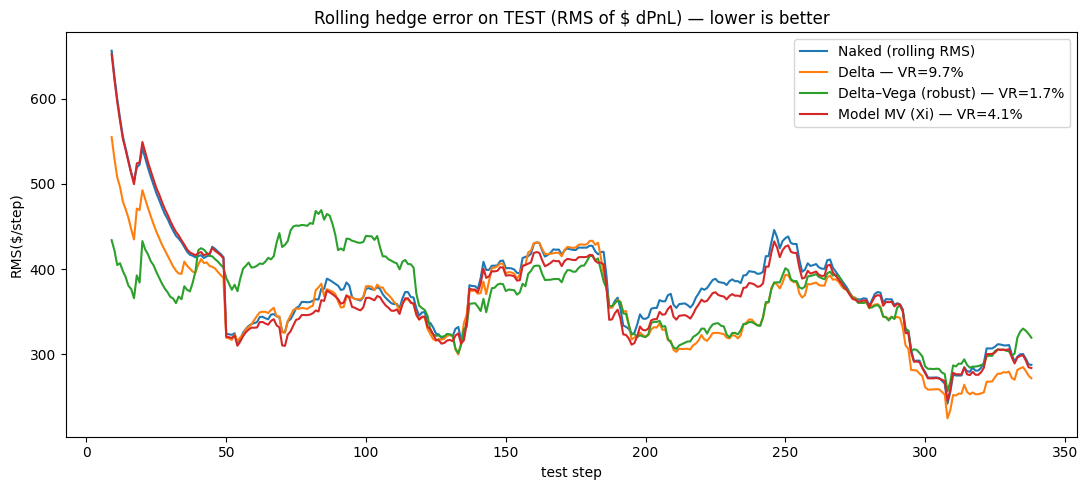

In [94]:
# Select "best" hedge instruments on C_train only, fit weights on C_train,
# and apply them to the entire C_test. Plot rolling RMS hedge error on C_test
# for: Naked, Best (train OLS on dC), Delta, Delta–Vega (robust), and Model MV (Xi).

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils.black_scholes import implied_vol_from_c_norm, bs_vega_norm, _Phi

# ---------------- Config ----------------
k_best = 6          # number of option nodes chosen by |corr| on C_train (exclude portfolio node)
ridge = 1e-2        # ridge for stability (best hedge fit on C_train)
roll = 50           # rolling window for RMS (steps)
vega_floor_frac = 0.02  # floor for robust Delta–Vega as % of median |vega_h| on test
use_absolute = True     # use $ PnL if spot is available for both train and test
sbar_from = "test"      # 'test' or 'train' for model MV Σ̄ (Xi); only affects the model-based line

# --------------- Helpers ----------------
def get_spot_series_for_index(idx: pd.DatetimeIndex):
    # Try to reindex a high-frequency spot series if available; else fallback
    if 'spot_1m' in globals() and isinstance(spot_1m, pd.Series):
        s = spot_1m.reindex(idx).interpolate(method="time").ffill().bfill()
        return s.to_numpy(dtype=float) if len(s)==len(idx) else None
    if 'spot_ts' in globals() and isinstance(spot_ts, pd.Series):
        s = spot_ts.reindex(idx).interpolate(method="time").ffill().bfill()
        return s.to_numpy(dtype=float) if len(s)==len(idx) else None
    if 'spot' in globals():
        # allow both array and Series (Series will be reindexed if possible)
        if isinstance(spot, pd.Series):
            s = spot.reindex(idx).interpolate(method="time").ffill().bfill()
            return s.to_numpy(dtype=float) if len(s)==len(idx) else None
        arr = np.asarray(spot, float)
        if arr.shape[0] == len(idx):
            return arr
    return None

def greeks_per_node(C_norm: np.ndarray, nodes: np.ndarray, S: np.ndarray):
    # Vectorized BS greeks on lattice (T x N)
    T, N = C_norm.shape
    tau = nodes[:, 0]; m = nodes[:, 1]
    Tm = np.broadcast_to(tau[None, :], (T, N))
    Mm = np.broadcast_to(m[None, :],   (T, N))
    sig = implied_vol_from_c_norm(C_norm, Mm, Tm)      # (T,N)
    srt = np.sqrt(np.maximum(Tm, 0.0))
    sigsrt = np.maximum(sig * srt, 1e-12)
    d1 = (-Mm) / sigsrt + 0.5 * sigsrt
    delta_abs = _Phi(d1)                                # (T,N)
    vega_abs  = (S[:, None] * bs_vega_norm(Mm, Tm, sig))# (T,N)
    return sig, delta_abs, vega_abs

def rolling_rms(x, w):
    s = pd.Series(x)
    return s.rolling(w, min_periods=max(5, w//5)).apply(lambda a: np.sqrt(np.mean(a**2)), raw=True).to_numpy()

def vr(ref, hedged):
    return 1 - np.nanvar(hedged)/max(np.nanvar(ref), 1e-12)

# --------------- Data -------------------
C_tr = outs.C_train.values.astype(float)  # (Ttr, N)
C_te = outs.C_test.values.astype(float)   # (Tte, N)
idx_tr = pd.to_datetime(outs.C_train.index)
idx_te = pd.to_datetime(outs.C_test.index)
N = C_tr.shape[1]

w = np.asarray(w_nodes, float).reshape(-1)
p_idx = int(np.argmax(w))
nodes = getattr(outs, 'nodes_sub', None)
assert nodes is not None, "outs.nodes_sub not found."

# Spot for train and test (for absolute $)
S_tr = get_spot_series_for_index(idx_tr) if use_absolute else None
S_te = get_spot_series_for_index(idx_te) if use_absolute else None
if use_absolute and (S_tr is None or S_te is None):
    print("[info] Spot not available for train and/or test; using normalized units.")
    use_absolute = False

# Increments and target y for train/test (consistent units across both)
if use_absolute:
    dC_tr = (S_tr[:, None]*C_tr)[1:] - (S_tr[:, None]*C_tr)[:-1]   # (Ttr-1, N)
    dC_te = (S_te[:, None]*C_te)[1:] - (S_te[:, None]*C_te)[:-1]   # (Tte-1, N)
else:
    dC_tr = C_tr[1:] - C_tr[:-1]
    dC_te = C_te[1:] - C_te[:-1]

y_tr = dC_tr @ w          # naked dPnL (train)
y_te = dC_te @ w          # naked dPnL (test)

# --------------- Pick best hedgers on TRAIN only ---------------
cand = [j for j in range(N) if j != p_idx]
corrs = []
for j in cand:
    c = np.corrcoef(y_tr, dC_tr[:, j])[0, 1]
    if np.isfinite(c):
        corrs.append((j, abs(c)))
corrs.sort(key=lambda t: t[1], reverse=True)
best = [j for j,_ in corrs[:k_best]]
labels_best = [f"opt[{j}]" for j in best]
print("Best hedgers chosen on TRAIN (node, |corr|):", corrs[:k_best])

# --------------- Best hedge (fit on TRAIN, apply on TEST) ---------------
H_tr = dC_tr[:, best]
H_te = dC_te[:, best]

# Standardize by TRAIN stats + intercept (ridge)
sc = np.std(H_tr, axis=0, ddof=1); sc[sc==0] = 1.0
Hs_tr = H_tr / sc; Hs_te = H_te / sc
X_tr = np.hstack([Hs_tr, np.ones((Hs_tr.shape[0], 1))])
R = np.diag(np.r_[np.full(Hs_tr.shape[1], ridge), 0.0])
beta = np.linalg.solve(X_tr.T @ X_tr + R, X_tr.T @ y_tr)
u_s, alpha = beta[:-1], beta[-1]
u_best = u_s / sc

y_best_te = y_te - (H_te @ u_best + alpha)
vr_best_te = vr(y_te, y_best_te)

# --------------- Delta and Delta–Vega on TEST ---------------
if use_absolute:
    # Greeks computed on TEST panel
    _, delta_abs_te, vega_abs_te = greeks_per_node(C_te, nodes, S_te)
    dS_te = S_te[1:] - S_te[:-1]
    delta_P_te = (delta_abs_te * w[None, :]).sum(axis=1)    # (Tte,)
    vega_P_te  = (vega_abs_te  * w[None, :]).sum(axis=1)    # (Tte,)

    # Delta-only
    y_delta_te = y_te - delta_P_te[:-1] * dS_te

    # Robust Delta–Vega: pick most vega-rich among the TRAIN-chosen best nodes each step on TEST
    vega_h_univ = vega_abs_te[:, best]                      # (Tte, k_best)
    delta_h_univ = delta_abs_te[:, best]
    vega_floor = max(vega_floor_frac * np.nanmedian(np.abs(vega_h_univ)), 1e-6)

    uS_dv = np.zeros_like(dS_te); uOpt_dv = np.zeros_like(dS_te); j_pick = np.zeros_like(dS_te, dtype=int)
    for t in range(len(dS_te)):
        j_loc = int(np.argmax(np.abs(vega_h_univ[t])))
        v_h   = float(vega_h_univ[t, j_loc])
        d_h   = float(delta_h_univ[t, j_loc])
        if (not np.isfinite(v_h)) or (abs(v_h) < vega_floor):
            uOpt = 0.0
            uS   = float(delta_P_te[t])   # delta-only fallback
        else:
            uOpt = float(vega_P_te[t] / v_h)
            uS   = float(delta_P_te[t] - d_h * uOpt)
        uOpt_dv[t] = uOpt; uS_dv[t] = uS; j_pick[t] = j_loc

    # Option PnL for the chosen hedge option on TEST
    C_abs_te = (S_te[:, None]*C_te) if use_absolute else C_te
    dC_abs_te = C_abs_te[1:] - C_abs_te[:-1]
    opt_cols = np.array(best, dtype=int)
    opt_pnl_dyn = dC_abs_te[np.arange(len(dS_te)), opt_cols[j_pick]] * uOpt_dv
    y_dv_te = y_te - (uS_dv * dS_te + opt_pnl_dyn)

    vr_delta_te = vr(y_te, y_delta_te)
    vr_dv_te    = vr(y_te, y_dv_te)
else:
    # If not absolute, skip delta/vega (no S). Provide placeholders.
    y_delta_te = np.full_like(y_te, np.nan); y_dv_te = np.full_like(y_te, np.nan)
    vr_delta_te = np.nan; vr_dv_te = np.nan

# --------------- Model MV (Xi) on TEST using hedgers picked on TRAIN ---------------
# Uses your instant_cov() defined earlier in the notebook.
G = np.vstack([outs.G_dyn,
               outs.G_stat,
               outs.G_sa if getattr(outs, "G_sa", None) is not None and outs.G_sa.size>0
               else np.zeros((0, outs.C_test.shape[1]))])
s = G @ w
B = G[:, best]  # same hedge set as Best hedge

if sbar_from == "train":
    Sigma_t = instant_cov(model, outs, use_test=False, use_endogenous_shrink=True)
else:
    Sigma_t = instant_cov(model, outs, use_test=False,  use_endogenous_shrink=True)
Sbar = Sigma_t.mean(axis=0)

u_model = np.linalg.solve(B.T @ Sbar @ B + 1e-9*np.eye(B.shape[1]), B.T @ Sbar @ s)

# Apply on TEST dPnL (same units as others on test)
y_model_te = y_te - dC_te[:, best] @ u_model
vr_model_te = vr(y_te, y_model_te)

print(f"Portfolio node: {p_idx}")
print("Best hedgers (picked on TRAIN):", labels_best)
print(f"Test VR — Best(OLS on train): {vr_best_te:.2%} | Delta: {vr_delta_te:.2%} | Delta–Vega: {vr_dv_te:.2%} | Model MV (Xi): {vr_model_te:.2%}")

# --------------- Plot (similar to cell 47): rolling RMS on TEST only ---------------
rms_naked = rolling_rms(y_te, roll)
rms_best  = rolling_rms(y_best_te, roll)
rms_delta = rolling_rms(y_delta_te, roll)
rms_dv    = rolling_rms(y_dv_te, roll)
rms_model = rolling_rms(y_model_te, roll)

plt.figure(figsize=(11,5))
plt.plot(rms_naked, label="Naked (rolling RMS)")
# plt.plot(rms_best,  label=f"Best (OLS on train) — VR={vr_best_te:.1%}")
if np.isfinite(vr_delta_te): plt.plot(rms_delta, label=f"Delta — VR={vr_delta_te:.1%}")
if np.isfinite(vr_dv_te):    plt.plot(rms_dv,    label=f"Delta–Vega (robust) — VR={vr_dv_te:.1%}")
plt.plot(rms_model, label=f"Model MV (Xi) — VR={vr_model_te:.1%}")
plt.title(f"Rolling hedge error on TEST (RMS of {'$' if use_absolute else 'normalized'} dPnL) — lower is better")
plt.xlabel("test step"); plt.ylabel("RMS($/step)" if use_absolute else "RMS(norm/step)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()